# UTS 31250 Introduction to Data Analytics

## Assessment Task 2: Data Exploration and Preparation

**Student Number:** 25740123

## P0. Data Audit and Setup

This section checks the structure and quality of the raw dataset before the assessed analysis begins. It verifies the dataset dimensions, missing values and several key consistency checks without modifying the original data.

P0 is a preparation and quality assurance step. It is not one of the assessed A or B tasks.

Two rules apply throughout this section. First, the raw file `25740123.csv` is never edited. Second, blank cells in the raw file are treated as missing values and are never read as zero. Nothing is imputed and no rows are removed here.

### P0.1 Import the libraries

Only pandas and numpy are needed for the audit. pandas is used to read the comma separated file and to summarise it, and numpy supports the numeric work. The library versions are printed so that the run can be reproduced later.

In [1]:
import hashlib

import numpy as np
import pandas as pd

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 160)

print("pandas version:", pd.__version__)
print("numpy version:", np.__version__)

pandas version: 3.0.3
numpy version: 2.4.6


### P0.2 Load the raw data

The raw file is read into a DataFrame named `df_raw`. This object is treated as read only for the whole notebook. Where a check needs a transformed value, a separate copy or Series is created instead of changing `df_raw`.

By default pandas reads an empty field as `NaN`, which is the correct behaviour here because a blank cell means the value was not recorded.

In [2]:
RAW_CSV = "25740123.csv"

df_raw = pd.read_csv(RAW_CSV)

print("Dataset shape:", df_raw.shape)
print("Number of rows:", df_raw.shape[0])
print("Number of columns:", df_raw.shape[1])

Dataset shape: (4349, 25)
Number of rows: 4349
Number of columns: 25


The full ordered list of attribute names is printed next, because later sections refer to these attributes by name and the order matters when the audit table is read.

In [3]:
print("Ordered column names:")
for position, column_name in enumerate(df_raw.columns, start=1):
    print(position, column_name)

Ordered column names:
1 O_CITY
2 O_STATE
3 D_CITY
4 D_STATE
5 SCHEDULED_DEPARTURE
6 DEPARTURE_TIME
7 DEPARTURE_DELAY
8 TAXI_OUT
9 WHEELS_OFF
10 SCHEDULED_TIME
11 ELAPSED_TIME
12 AIR_TIME
13 DISTANCE
14 WHEELS_ON
15 TAXI_IN
16 SCHEDULED_ARRIVAL
17 ARRIVAL_TIME
18 ARRIVAL_DELAY
19 DIVERTED
20 CANCELLED
21 AIR_SYSTEM_DELAY
22 SECURITY_DELAY
23 WEATHER_DELAY
24 DATE
25 AIRLINE_NAME


A short preview of the first rows confirms that the file was read with the correct header row and that the columns are aligned as expected.

In [4]:
df_raw.head()

,O_CITY,O_STATE,D_CITY,D_STATE,SCHEDULED_DEPARTURE,DEPARTURE_TIME,DEPARTURE_DELAY,TAXI_OUT,WHEELS_OFF,SCHEDULED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,WHEELS_ON,TAXI_IN,SCHEDULED_ARRIVAL,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,AIR_SYSTEM_DELAY,SECURITY_DELAY,WEATHER_DELAY,DATE,AIRLINE_NAME
0,Chicago,IL,Omaha,NE,1655,1706.0,11.0,8.0,1714.0,80,72.0,60.0,423,1814.0,4.0,1815,1818.0,3.0,0,0,NaN,NaN,NaN,2015-9-6,Southwest Airlines Co.
1,Ontario,CA,Salt Lake City,UT,1630,1625.0,-5.0,14.0,1639.0,108,100.0,81.0,558,1900.0,5.0,1918,1905.0,-13.0,0,0,NaN,NaN,NaN,2015-2-23,Skywest Airlines Inc.
2,Charlotte Amalie,VI,Atlanta,GA,1510,1526.0,16.0,11.0,1537.0,250,247.0,230.0,1599,1827.0,6.0,1820,1833.0,13.0,0,0,NaN,NaN,NaN,2015-1-16,Delta Air Lines Inc.
3,Salt Lake City,UT,Oakland,CA,1505,1505.0,0.0,14.0,1519.0,119,102.0,82.0,588,1541.0,6.0,1604,1547.0,-17.0,0,0,NaN,NaN,NaN,2015-12-1,Delta Air Lines Inc.
4,Fargo,ND,Denver,CO,1712,1805.0,53.0,11.0,1816.0,123,125.0,95.0,627,1851.0,19.0,1815,1910.0,55.0,0,0,2.0,0.0,0.0,2015-2-4,Skywest Airlines Inc.


### P0.3 Attribute audit table

This table gives one row per attribute and records the pandas data type, how many values are present, how many are missing, the missing percentage and how many distinct values occur. The missing percentage is calculated from the actual number of rows in the file rather than from an assumed row count.

The table is a new DataFrame, so building it does not change `df_raw`.

In [5]:
total_rows = len(df_raw)
audit_rows = []

for column_name in df_raw.columns:
    column = df_raw[column_name]
    missing_count = int(column.isna().sum())
    audit_rows.append({
        "Attribute": column_name,
        "Pandas dtype": str(column.dtype),
        "Non-missing count": int(column.notna().sum()),
        "Missing count": missing_count,
        "Missing percentage": round(100 * missing_count / total_rows, 2),
        "Unique values": int(column.nunique(dropna=True)),
    })

audit_table = pd.DataFrame(audit_rows)
audit_table

,Attribute,Pandas dtype,Non-missing count,Missing count,Missing percentage,Unique values
0,O_CITY,str,4349,0,0.00,213
1,O_STATE,str,4349,0,0.00,52
2,D_CITY,str,4349,0,0.00,214
3,D_STATE,str,4349,0,0.00,51
4,SCHEDULED_DEPARTURE,int64,4349,0,0.00,806
5,DEPARTURE_TIME,float64,4288,61,1.40,1084
6,DEPARTURE_DELAY,float64,4288,61,1.40,204
7,TAXI_OUT,float64,4284,65,1.49,73
8,WHEELS_OFF,float64,4284,65,1.49,1082
9,SCHEDULED_TIME,int64,4349,0,0.00,350


The audit table is saved so that it can be referenced later without rerunning the whole notebook.

In [6]:
audit_table.to_csv("outputs/P0_data_audit.csv", index=False)
print("Saved outputs/P0_data_audit.csv with", len(audit_table), "attribute rows.")

Saved outputs/P0_data_audit.csv with 25 attribute rows.


### P0.4 Duplicate rows

An exact duplicate row would mean the same flight record appears twice. This check counts rows that are identical across all 25 attributes.

In [7]:
duplicate_row_count = int(df_raw.duplicated().sum())
print("Exact duplicate rows:", duplicate_row_count)

Exact duplicate rows: 0


### P0.5 Missing values and unique values for every attribute

The audit table above already contains this information, but printing the two series separately makes the pattern of missing data easier to read.

In [8]:
print("Missing values per attribute:")
print(df_raw.isna().sum())

Missing values per attribute:
O_CITY                    0
O_STATE                   0
D_CITY                    0
D_STATE                   0
SCHEDULED_DEPARTURE       0
DEPARTURE_TIME           61
DEPARTURE_DELAY          61
TAXI_OUT                 65
WHEELS_OFF               65
SCHEDULED_TIME            0
ELAPSED_TIME             84
AIR_TIME                 84
DISTANCE                  0
WHEELS_ON                67
TAXI_IN                  67
SCHEDULED_ARRIVAL         0
ARRIVAL_TIME             67
ARRIVAL_DELAY            84
DIVERTED                  0
CANCELLED                 0
AIR_SYSTEM_DELAY       3522
SECURITY_DELAY         3522
WEATHER_DELAY          3522
DATE                      0
AIRLINE_NAME              0
dtype: int64


In [9]:
print("Unique values per attribute:")
print(df_raw.nunique(dropna=True))

Unique values per attribute:
O_CITY                  213
O_STATE                  52
D_CITY                  214
D_STATE                  51
SCHEDULED_DEPARTURE     806
DEPARTURE_TIME         1084
DEPARTURE_DELAY         204
TAXI_OUT                 73
WHEELS_OFF             1082
SCHEDULED_TIME          350
ELAPSED_TIME            353
AIR_TIME                334
DISTANCE                930
WHEELS_ON              1126
TAXI_IN                  50
SCHEDULED_ARRIVAL      1024
ARRIVAL_TIME           1133
ARRIVAL_DELAY           236
DIVERTED                  2
CANCELLED                 2
AIR_SYSTEM_DELAY         81
SECURITY_DELAY            5
WEATHER_DELAY            44
DATE                    334
AIRLINE_NAME              6
dtype: int64


### P0.6 Cancelled and diverted flights

`CANCELLED` and `DIVERTED` are indicator attributes, so they should only contain the values 0 and 1. The number of flights flagged in each attribute is counted.

In [10]:
print("CANCELLED unique values:", sorted(df_raw["CANCELLED"].unique()))
print("DIVERTED unique values:", sorted(df_raw["DIVERTED"].unique()))

cancelled_count = int((df_raw["CANCELLED"] == 1).sum())
diverted_count = int((df_raw["DIVERTED"] == 1).sum())

print("Rows where CANCELLED == 1:", cancelled_count)
print("Rows where DIVERTED == 1:", diverted_count)

CANCELLED unique values: [np.int64(0), np.int64(1)]
DIVERTED unique values: [np.int64(0), np.int64(1)]
Rows where CANCELLED == 1: 66
Rows where DIVERTED == 1: 18


### P0.7 Airlines

The number of distinct airline names is counted and the names are listed, so that the categorical attribute can be described accurately in the later sections.

In [11]:
airline_names = sorted(df_raw["AIRLINE_NAME"].dropna().unique())
number_of_airlines = int(df_raw["AIRLINE_NAME"].nunique(dropna=True))

print("Number of airlines:", number_of_airlines)
for airline in airline_names:
    print("-", airline)

Number of airlines: 6
- American Airlines Inc.
- Atlantic Southeast Airlines
- Delta Air Lines Inc.
- Skywest Airlines Inc.
- Southwest Airlines Co.
- United Air Lines Inc.


### P0.8 Date range

`DATE` is stored as text in the raw file, and the values are not zero padded, for example `2015-9-6`. To check the date range the text is parsed into a temporary Series called `date_parsed` using the explicit format `%Y-%m-%d`. Giving the format explicitly avoids any guessing about whether the day or the month comes first.

`df_raw["DATE"]` itself is left as text, and the last two lines confirm that.

In [12]:
print("Original DATE dtype:", df_raw["DATE"].dtype)

date_parsed = pd.to_datetime(df_raw["DATE"], format="%Y-%m-%d")

print("Parsed minimum date:", date_parsed.min().date())
print("Parsed maximum date:", date_parsed.max().date())
print("Dates that failed to parse:", int(date_parsed.isna().sum()))

print("DATE dtype in df_raw after parsing:", df_raw["DATE"].dtype)
print("First DATE value in df_raw:", repr(df_raw["DATE"].iloc[0]))

Original DATE dtype: str
Parsed minimum date: 2015-01-01
Parsed maximum date: 2015-12-31
Dates that failed to parse: 0
DATE dtype in df_raw after parsing: str
First DATE value in df_raw: '2015-9-6'


### P0.9 ARRIVAL_DELAY audit

`ARRIVAL_DELAY` is the main outcome attribute for this dataset, measured in minutes, where a negative value means the flight arrived early. Missing values are counted as missing and are never treated as a delay of zero. All statistics below are therefore calculated on the non-missing values only, which is what pandas does by default.

In [13]:
arrival_delay = df_raw["ARRIVAL_DELAY"]

arrival_delay_non_missing = int(arrival_delay.notna().sum())
arrival_delay_min = float(arrival_delay.min())
arrival_delay_max = float(arrival_delay.max())
arrival_delay_negative = int((arrival_delay < 0).sum())

print("Non-missing ARRIVAL_DELAY values:", arrival_delay_non_missing)
print("Missing ARRIVAL_DELAY values:", int(arrival_delay.isna().sum()))
print("Minimum ARRIVAL_DELAY:", arrival_delay_min, "minutes")
print("Maximum ARRIVAL_DELAY:", arrival_delay_max, "minutes")
print("Non-missing values below zero (early arrivals):", arrival_delay_negative)

Non-missing ARRIVAL_DELAY values: 4265
Missing ARRIVAL_DELAY values: 84
Minimum ARRIVAL_DELAY: -61.0 minutes
Maximum ARRIVAL_DELAY: 865.0 minutes
Non-missing values below zero (early arrivals): 2633


### P0.10 Why the values are missing

The missing values in this dataset are not random. A cancelled flight never departs and a diverted flight never lands at the scheduled destination, so no arrival time can be recorded. This section tests whether the rows with a missing `ARRIVAL_DELAY` are exactly the rows that were cancelled or diverted.

Counting alone is not enough, because two different sets of rows can still have the same size. The comparison below uses `Series.equals`, which compares the True and False pattern row by row, and it is confirmed with a comparison of the row index sets.

In [14]:
is_cancelled = df_raw["CANCELLED"] == 1
is_diverted = df_raw["DIVERTED"] == 1
cancelled_or_diverted = is_cancelled | is_diverted

arrival_delay_missing = df_raw["ARRIVAL_DELAY"].isna()
elapsed_time_missing = df_raw["ELAPSED_TIME"].isna()

print("Cancelled flights:", int(is_cancelled.sum()))
print("Diverted flights:", int(is_diverted.sum()))
print("Cancelled or diverted flights:", int(cancelled_or_diverted.sum()))
print("Rows with missing ARRIVAL_DELAY:", int(arrival_delay_missing.sum()))
print("Rows with missing ELAPSED_TIME:", int(elapsed_time_missing.sum()))

Cancelled flights: 66
Diverted flights: 18
Cancelled or diverted flights: 84
Rows with missing ARRIVAL_DELAY: 84
Rows with missing ELAPSED_TIME: 84


In [15]:
arrival_rows_match = bool(arrival_delay_missing.equals(cancelled_or_diverted))
elapsed_rows_match = bool(elapsed_time_missing.equals(cancelled_or_diverted))

flagged_index = set(df_raw.index[cancelled_or_diverted])
arrival_index_match = set(df_raw.index[arrival_delay_missing]) == flagged_index
elapsed_index_match = set(df_raw.index[elapsed_time_missing]) == flagged_index

print("Missing ARRIVAL_DELAY rows equal cancelled or diverted rows:", arrival_rows_match)
print("Missing ELAPSED_TIME rows equal cancelled or diverted rows:", elapsed_rows_match)
print("Same result using row index sets, ARRIVAL_DELAY:", arrival_index_match)
print("Same result using row index sets, ELAPSED_TIME:", elapsed_index_match)

Missing ARRIVAL_DELAY rows equal cancelled or diverted rows: True
Missing ELAPSED_TIME rows equal cancelled or diverted rows: True
Same result using row index sets, ARRIVAL_DELAY: True
Same result using row index sets, ELAPSED_TIME: True


### P0.11 The three delay-cause attributes

`AIR_SYSTEM_DELAY`, `SECURITY_DELAY` and `WEATHER_DELAY` break a late arrival down into its causes. These attributes have a very high number of missing values, so it is important to understand why before any later section uses them.

Two things are tested. First, whether the three attributes are missing on exactly the same rows. Second, whether the rows that do have values are exactly the rows where `ARRIVAL_DELAY` is 15 minutes or more, which is the usual reporting threshold for a delayed flight.

In [16]:
air_system_missing = df_raw["AIR_SYSTEM_DELAY"].isna()
security_missing = df_raw["SECURITY_DELAY"].isna()
weather_missing = df_raw["WEATHER_DELAY"].isna()

same_as_security = bool(air_system_missing.equals(security_missing))
same_as_weather = bool(air_system_missing.equals(weather_missing))

print("AIR_SYSTEM_DELAY missing on the same rows as SECURITY_DELAY:", same_as_security)
print("AIR_SYSTEM_DELAY missing on the same rows as WEATHER_DELAY:", same_as_weather)
print("Rows where the delay causes are recorded:", int((~air_system_missing).sum()))

AIR_SYSTEM_DELAY missing on the same rows as SECURITY_DELAY: True
AIR_SYSTEM_DELAY missing on the same rows as WEATHER_DELAY: True
Rows where the delay causes are recorded: 827


In [17]:
delay_15_or_more = df_raw["ARRIVAL_DELAY"] >= 15
delay_causes_recorded = ~air_system_missing

delay_cause_rows_match = bool(delay_causes_recorded.equals(delay_15_or_more))

print("Rows where ARRIVAL_DELAY is 15 minutes or more:", int(delay_15_or_more.sum()))
print("Recorded delay-cause rows equal those rows:", delay_cause_rows_match)

Rows where ARRIVAL_DELAY is 15 minutes or more: 827
Recorded delay-cause rows equal those rows: True


### P0.12 Validation table

The assignment brief describes what this dataset should look like. Every expected fact is recomputed from the raw file and compared with the expected value. The expected values are only used as a target for comparison, and no value is ever written back into the data to force a match.

In [18]:
expected_missing_counts = {
    "DEPARTURE_TIME": 61,
    "DEPARTURE_DELAY": 61,
    "TAXI_OUT": 65,
    "WHEELS_OFF": 65,
    "WHEELS_ON": 67,
    "TAXI_IN": 67,
    "ARRIVAL_TIME": 67,
    "ELAPSED_TIME": 84,
    "AIR_TIME": 84,
    "ARRIVAL_DELAY": 84,
    "AIR_SYSTEM_DELAY": 3522,
    "SECURITY_DELAY": 3522,
    "WEATHER_DELAY": 3522,
}

validation_rows = []

def record_check(check_name, expected_value, observed_value):
    validation_rows.append({
        "Check": check_name,
        "Expected": str(expected_value),
        "Observed": str(observed_value),
        "Match": str(expected_value) == str(observed_value),
    })

In [19]:
record_check("Dataset rows", 4349, df_raw.shape[0])
record_check("Dataset columns", 25, df_raw.shape[1])
record_check("Date minimum", "2015-01-01", date_parsed.min().date())
record_check("Date maximum", "2015-12-31", date_parsed.max().date())
record_check("Number of airlines", 6, number_of_airlines)

for column_name, expected_count in expected_missing_counts.items():
    record_check("Missing values in " + column_name,
                 expected_count,
                 int(df_raw[column_name].isna().sum()))

other_columns = [c for c in df_raw.columns if c not in expected_missing_counts]
record_check("Attributes expected to have no missing values",
             0,
             int(df_raw[other_columns].isna().sum().sum()))

In [20]:
record_check("Cancelled flights", 66, cancelled_count)
record_check("Diverted flights", 18, diverted_count)
record_check("Cancelled or diverted rows", 84, int(cancelled_or_diverted.sum()))
record_check("Missing ARRIVAL_DELAY count", 84, int(arrival_delay_missing.sum()))
record_check("ARRIVAL_DELAY non-missing count", 4265, arrival_delay_non_missing)
record_check("ARRIVAL_DELAY minimum", -61.0, arrival_delay_min)
record_check("ARRIVAL_DELAY maximum", 865.0, arrival_delay_max)
record_check("Negative ARRIVAL_DELAY count", 2633, arrival_delay_negative)
record_check("Missing ARRIVAL_DELAY row set equals cancelled or diverted", True, arrival_rows_match)
record_check("Missing ELAPSED_TIME row set equals cancelled or diverted", True, elapsed_rows_match)
record_check("Delay causes missing on identical rows", True, same_as_security and same_as_weather)
record_check("Delay-cause rows equal ARRIVAL_DELAY of 15 or more", True, delay_cause_rows_match)
record_check("Rows with ARRIVAL_DELAY of 15 or more", 827, int(delay_15_or_more.sum()))
record_check("Exact duplicate rows", 0, duplicate_row_count)

validation_table = pd.DataFrame(validation_rows)
validation_table

,Check,Expected,Observed,Match
0,Dataset rows,4349,4349,True
1,Dataset columns,25,25,True
2,Date minimum,2015-01-01,2015-01-01,True
3,Date maximum,2015-12-31,2015-12-31,True
4,Number of airlines,6,6,True
5,Missing values in DEPARTURE_TIME,61,61,True
6,Missing values in DEPARTURE_DELAY,61,61,True
7,Missing values in TAXI_OUT,65,65,True
8,Missing values in WHEELS_OFF,65,65,True
9,Missing values in WHEELS_ON,67,67,True


The last step of the validation is a single summary line. If any check had failed, the failing rows would be printed here so that the problem could be reported before any further work was done.

In [21]:
failed_checks = validation_table[validation_table["Match"] == False]

print("Total checks:", len(validation_table))
print("Checks passed:", int((validation_table["Match"] == True).sum()))
print("Checks failed:", len(failed_checks))

if len(failed_checks) == 0:
    print("All expected dataset facts were confirmed from the raw file.")
else:
    print("The following checks did not match the expected values:")
    print(failed_checks)

Total checks: 33
Checks passed: 33
Checks failed: 0
All expected dataset facts were confirmed from the raw file.


### P0.13 Raw file integrity

The final check confirms that the raw file was not altered by this notebook. The SHA-256 hash of `25740123.csv` is recalculated and compared with the hash recorded when the audit was first written. The file size and the row count are also reported. A matching hash means the file is byte for byte identical, so no value was written back, no row was removed and no blank cell was replaced.

In [22]:
RECORDED_CSV_HASH = "676681651e11de53308116df0fc5b2ef72c5b967ec779d0159f747edd10499de"

with open(RAW_CSV, "rb") as raw_file:
    current_csv_hash = hashlib.sha256(raw_file.read()).hexdigest()

print("Recorded SHA-256:", RECORDED_CSV_HASH)
print("Current SHA-256: ", current_csv_hash)
print("Raw file unchanged:", current_csv_hash == RECORDED_CSV_HASH)
print("Rows still loaded from the raw file:", len(df_raw))

Recorded SHA-256: 676681651e11de53308116df0fc5b2ef72c5b967ec779d0159f747edd10499de
Current SHA-256:  676681651e11de53308116df0fc5b2ef72c5b967ec779d0159f747edd10499de
Raw file unchanged: True
Rows still loaded from the raw file: 4349


### P0.14 Audit conclusion

The audit confirmed the structure the assignment brief describes. The file holds 4,349 flight records and 25 attributes, covering every date from 1 January 2015 to 31 December 2015 for six airlines, with no exact duplicate rows.

The missing values fall into two clear groups. The first group is the small number of operational attributes, from `DEPARTURE_TIME` through to `ARRIVAL_DELAY`, where between 61 and 84 values are absent. The 84 rows with no `ARRIVAL_DELAY` or `ELAPSED_TIME` are exactly the 66 cancelled and 18 diverted flights, so these values are missing because the flight did not complete rather than because of a recording error. The second group is the three delay-cause attributes, each missing 3,522 values on identical rows. Their 827 recorded rows are exactly the flights that arrived 15 minutes late or later, so a blank there means the flight was not reportably late, which is very different from a zero.

That distinction matters for the assessed sections. Reading any of these blanks as zero would understate delays and distort the summary statistics, so the raw missing values are carried forward unchanged and how to handle them will be decided as part of the later tasks.

No data was modified in this section. No values were imputed, no rows were removed and no charts were produced, because those belong to the assessed tasks that follow.

## A1. Attribute Types

This section classifies all 25 attributes in the dataset using the four measurement scales: nominal, ordinal, interval and ratio.

The classification is based on what each attribute actually measures, not on how pandas happens to store it. A column of whole numbers is not automatically a quantity, and a column of text is not automatically a category. For each attribute the following properties are considered in turn: whether values are distinct, whether they can be placed in a meaningful order, whether the differences between values are meaningful and equally spaced, and whether the attribute has a true zero that makes ratio statements such as "twice as much" meaningful.

The table below is built in three groups so that each group of related attributes stays readable, and it is then presented in the original dataset order.

### A1.1 Nominal attributes

These attributes record labels. Their values can be compared for equality only, because no value ranks above another and the gap between two labels cannot be measured.

In [23]:
a1_rows = []

a1_rows.append(["O_CITY", "Nominal",
    "The origin city is a distinct place label, so only equality comparisons apply and no order or numerical distance exists."])
a1_rows.append(["O_STATE", "Nominal",
    "State names distinguish one origin region from another but carry no measurement order, so only equality and inequality are meaningful."])
a1_rows.append(["D_CITY", "Nominal",
    "The destination city is a distinct place label with no inherent ranking, and differences between city names cannot be measured."])
a1_rows.append(["D_STATE", "Nominal",
    "Destination states are distinct regional categories, and no state sits at a measurable interval above or below another."])
a1_rows.append(["DIVERTED", "Nominal",
    "The codes 0 and 1 label two flight outcomes rather than measuring an amount, so only distinctness is meaningful."])
a1_rows.append(["CANCELLED", "Nominal",
    "The value 1 marks a cancelled flight and 0 a flight that operated, so the digits act purely as category labels."])
a1_rows.append(["AIRLINE_NAME", "Nominal",
    "Each airline name identifies a distinct carrier, and airlines cannot be placed in a measurement order or spaced by intervals."])

print("Nominal attributes added:", len(a1_rows))

Nominal attributes added: 7


### A1.2 Interval attributes

These attributes are measured against a reference point that is set by convention rather than by nature. Their order and their differences are meaningful, but because zero does not represent an absence of the quantity, a statement such as "twice as much" has no sensible interpretation.

In [24]:
a1_rows.append(["SCHEDULED_DEPARTURE", "Interval",
    "This is a clock point, so times can be ordered and gaps between them compared, but midnight is a conventional origin."])
a1_rows.append(["DEPARTURE_TIME", "Interval",
    "The actual departure clock time can be ordered and differences between two times are meaningful, yet the zero point is conventional."])
a1_rows.append(["DEPARTURE_DELAY", "Interval",
    "Delay is a signed offset in minutes from the schedule, where zero means on time rather than an absence of quantity."])
a1_rows.append(["WHEELS_OFF", "Interval",
    "The moment the wheels leave the ground is a point on the clock, so differences are meaningful but ratios are not."])
a1_rows.append(["WHEELS_ON", "Interval",
    "Touchdown is recorded as a clock point, so intervals between events are meaningful while a doubled clock value has no interpretation."])
a1_rows.append(["SCHEDULED_ARRIVAL", "Interval",
    "The planned arrival clock time is ordered with meaningful gaps between times, but it has no true zero for arrival."])
a1_rows.append(["ARRIVAL_TIME", "Interval",
    "The actual arrival clock time supports ordering and meaningful differences, although the origin of the clock is set by convention."])
a1_rows.append(["ARRIVAL_DELAY", "Interval",
    "Arrival delay is a signed deviation from schedule and includes negative values for early arrivals, so ratio comparisons are not meaningful."])
a1_rows.append(["DATE", "Interval",
    "Calendar dates can be ordered and differences in days are meaningful, but the start of the calendar is a convention."])

print("Attributes added so far:", len(a1_rows))

Attributes added so far: 16


### A1.3 Ratio attributes

These attributes measure an amount of something. Zero means that none of the quantity is present, so differences and ratios are both meaningful.

In [25]:
a1_rows.append(["TAXI_OUT", "Ratio",
    "This is a duration in minutes where zero means no time elapsed taxiing, so differences and ratios are both meaningful."])
a1_rows.append(["SCHEDULED_TIME", "Ratio",
    "The planned trip length is a duration with a true zero, so one flight can be meaningfully twice as long as another."])
a1_rows.append(["ELAPSED_TIME", "Ratio",
    "Total elapsed time measures an amount of time with a genuine zero, which allows meaningful differences and ratio comparisons."])
a1_rows.append(["AIR_TIME", "Ratio",
    "Time airborne is a measured duration where zero represents no time in the air, so ratio statements are meaningful."])
a1_rows.append(["DISTANCE", "Ratio",
    "Distance has a true zero at no separation and equal units, so one route can be meaningfully twice as far as another."])
a1_rows.append(["TAXI_IN", "Ratio",
    "The taxi-in duration counts minutes from a genuine zero, so both differences and ratio comparisons between flights are meaningful."])
a1_rows.append(["AIR_SYSTEM_DELAY", "Ratio",
    "When recorded, this is an amount of delay caused by the air system, and zero minutes is a meaningful absence of it."])
a1_rows.append(["SECURITY_DELAY", "Ratio",
    "When recorded, this measures minutes of delay attributed to security, with zero representing no such delay contribution."])
a1_rows.append(["WEATHER_DELAY", "Ratio",
    "When recorded, this measures minutes of delay attributed to weather, and zero marks a true absence of weather delay."])

print("Total attributes classified:", len(a1_rows))

Total attributes classified: 25


### A1.4 The complete A1 classification table

The three groups are combined into one table and then sorted back into the original dataset column order, so the table can be read alongside the P0 audit. The order is taken from `df_raw.columns` rather than from typing the 25 names again, so the table order always follows the data itself.

In [26]:
a1_table = pd.DataFrame(a1_rows, columns=["Attribute", "Attribute Type", "Justification"])

# Sort the rows into the original dataset column order, taken from the data itself.
attribute_order = list(df_raw.columns)
a1_table["Dataset position"] = a1_table["Attribute"].map(attribute_order.index)
a1_table = a1_table.sort_values("Dataset position").reset_index(drop=True)
a1_table = a1_table.drop(columns="Dataset position")

print("A1 table shape:", a1_table.shape)
a1_table

A1 table shape: (25, 3)


,Attribute,Attribute Type,Justification
0,O_CITY,Nominal,"The origin city is a distinct place label, so ..."
1,O_STATE,Nominal,State names distinguish one origin region from...
2,D_CITY,Nominal,The destination city is a distinct place label...
3,D_STATE,Nominal,Destination states are distinct regional categ...
4,SCHEDULED_DEPARTURE,Interval,"This is a clock point, so times can be ordered..."
5,DEPARTURE_TIME,Interval,The actual departure clock time can be ordered...
6,DEPARTURE_DELAY,Interval,Delay is a signed offset in minutes from the s...
7,TAXI_OUT,Ratio,This is a duration in minutes where zero means...
8,WHEELS_OFF,Interval,The moment the wheels leave the ground is a po...
9,SCHEDULED_TIME,Ratio,The planned trip length is a duration with a t...


Displaying the table with the full justification text makes it easier to read and to reuse later in the report.

In [27]:
for attribute, scale, justification in zip(a1_table["Attribute"],
                                          a1_table["Attribute Type"],
                                          a1_table["Justification"]):
    print(f"{attribute:<20} {scale:<9} {justification}")

O_CITY               Nominal   The origin city is a distinct place label, so only equality comparisons apply and no order or numerical distance exists.
O_STATE              Nominal   State names distinguish one origin region from another but carry no measurement order, so only equality and inequality are meaningful.
D_CITY               Nominal   The destination city is a distinct place label with no inherent ranking, and differences between city names cannot be measured.
D_STATE              Nominal   Destination states are distinct regional categories, and no state sits at a measurable interval above or below another.
SCHEDULED_DEPARTURE  Interval  This is a clock point, so times can be ordered and gaps between them compared, but midnight is a conventional origin.
DEPARTURE_TIME       Interval  The actual departure clock time can be ordered and differences between two times are meaningful, yet the zero point is conventional.
DEPARTURE_DELAY      Interval  Delay is a signed offset in 

The counts per measurement scale give a quick overview of the dataset composition.

In [28]:
print("Attributes per measurement scale:")
print(a1_table["Attribute Type"].value_counts())
print()
print("Total attributes classified:", len(a1_table))

Attributes per measurement scale:
Attribute Type
Interval    9
Ratio       9
Nominal     7
Name: count, dtype: int64

Total attributes classified: 25


### A1.5 Validation of the classification table

This cell checks the table mechanically rather than by eye. The approved measurement scale for each attribute is declared separately as three lists, so a typing mistake in the justification rows above would be caught by the comparison rather than being carried into the report.

In [29]:
approved_nominal = ["O_CITY", "O_STATE", "D_CITY", "D_STATE",
                    "DIVERTED", "CANCELLED", "AIRLINE_NAME"]
approved_interval = ["SCHEDULED_DEPARTURE", "DEPARTURE_TIME", "DEPARTURE_DELAY",
                     "WHEELS_OFF", "WHEELS_ON", "SCHEDULED_ARRIVAL",
                     "ARRIVAL_TIME", "ARRIVAL_DELAY", "DATE"]
approved_ratio = ["TAXI_OUT", "SCHEDULED_TIME", "ELAPSED_TIME", "AIR_TIME",
                  "DISTANCE", "TAXI_IN", "AIR_SYSTEM_DELAY",
                  "SECURITY_DELAY", "WEATHER_DELAY"]

approved_types = {}
for attribute in approved_nominal:
    approved_types[attribute] = "Nominal"
for attribute in approved_interval:
    approved_types[attribute] = "Interval"
for attribute in approved_ratio:
    approved_types[attribute] = "Ratio"

print("Approved classifications declared:", len(approved_types))

Approved classifications declared: 25


In [30]:
allowed_scales = {"Nominal", "Ordinal", "Interval", "Ratio"}
dataset_attributes = list(df_raw.columns)
table_attributes = list(a1_table["Attribute"])
table_types = list(a1_table["Attribute Type"])
justifications = list(a1_table["Justification"])

a1_checks = {
    "1. A1 row count is 25": len(a1_table) == 25,
    "2. A1 attribute order equals df_raw.columns": table_attributes == dataset_attributes,
    "3. Unique A1 attributes is 25": a1_table["Attribute"].nunique() == 25,
    "4. No dataset attribute is missing": set(dataset_attributes) - set(table_attributes) == set(),
    "5. No extra attribute is present": set(table_attributes) - set(dataset_attributes) == set(),
    "6. Only the four measurement scales are used": set(table_types) <= allowed_scales,
    "7. No missing Attribute Type": a1_table["Attribute Type"].notna().all(),
    "8. No missing Justification": a1_table["Justification"].notna().all(),
    "9. Every justification is non-empty text": all(isinstance(text, str) and text.strip() != "" for text in justifications),
    "10. Types match the approved classification": all(approved_types[name] == scale for name, scale in zip(table_attributes, table_types)),
}

for description, passed in a1_checks.items():
    print("PASS" if passed else "FAIL", description)

print()
print("Checks passed:", sum(a1_checks.values()), "of", len(a1_checks))

PASS 1. A1 row count is 25
PASS 2. A1 attribute order equals df_raw.columns
PASS 3. Unique A1 attributes is 25
PASS 4. No dataset attribute is missing
PASS 5. No extra attribute is present
PASS 6. Only the four measurement scales are used
PASS 7. No missing Attribute Type
PASS 8. No missing Justification
PASS 9. Every justification is non-empty text
PASS 10. Types match the approved classification

Checks passed: 10 of 10


The classification table is saved so that it can be reused in the report without rerunning the notebook. The saved file is read back and checked, which confirms the file on disk really holds all 25 rows.

In [31]:
a1_table.to_csv("outputs/A1_attribute_types.csv", index=False)

a1_saved = pd.read_csv("outputs/A1_attribute_types.csv")

print("Saved outputs/A1_attribute_types.csv")
print("Rows read back:", len(a1_saved))
print("Columns read back:", list(a1_saved.columns))
print("Saved file matches the table in memory:", a1_saved.equals(a1_table))

Saved outputs/A1_attribute_types.csv
Rows read back: 25
Columns read back: ['Attribute', 'Attribute Type', 'Justification']
Saved file matches the table in memory: True


### A1.6 Notes on the borderline attributes

Four groups of attributes needed careful thought, because their storage in the file could easily suggest the wrong measurement scale.

**Clock times recorded as HHMM.** `SCHEDULED_DEPARTURE`, `DEPARTURE_TIME`, `WHEELS_OFF`, `WHEELS_ON`, `SCHEDULED_ARRIVAL` and `ARRIVAL_TIME` are points in time rather than ordinary quantities. A value of 1655 means 16:55, so the digits are a clock reading and not a count of anything. Differences between two clock times are meaningful, but midnight is a conventional starting point rather than a true absence of time, which is why a claim that 1800 is twice 0900 makes no sense. These are therefore interval attributes. One practical warning follows from the HHMM coding: the raw numeric difference between two values does not always equal the elapsed minutes, because the last two digits only run from 0 to 59. A later section will need a suitable representation before these attributes are summarised numerically, and no such transformation is made in A1.

**Signed delay attributes.** `DEPARTURE_DELAY` and `ARRIVAL_DELAY` are offsets from the scheduled time measured in minutes, and they include negative values when a flight is early. P0 confirmed that 2,633 of the non-missing `ARRIVAL_DELAY` values are negative. Zero here means exactly on schedule, which is a reference point rather than an absence of delay, so ratio statements such as "twice the delay" do not hold consistently across a scale that runs through negative values. Both are treated as interval.

**Binary status flags.** `DIVERTED` and `CANCELLED` store 0 and 1, and P0 confirmed that these are the only two values present. The digits are labels for two flight statuses rather than measured amounts, so the fact that 1 is arithmetically greater than 0 carries no measurement meaning. Both are nominal.

**DATE.** The raw file stores the date as text, but that is a storage detail and not the measurement scale. Calendar dates can be ordered, and a difference of a number of days is meaningful and equally spaced, so the attribute is stronger than nominal or ordinal. The origin of the calendar is a human convention rather than a true zero point for time, so ratio comparisons between dates are not meaningful. `DATE` is therefore interval.

**No ordinal attributes.** No attribute in this dataset is classified as ordinal because none represents an ordered category for which rank is meaningful but equal differences are not. The four scales were applied on their merits and an ordinal case was not manufactured simply so that every scale appeared.

## A2. Summary Statistics

A2 is a univariate analysis, which means each attribute is examined one at a time rather than in combination with others.

The statistics that are appropriate depend on the attribute type identified in A1. A measure only makes sense if the measurement scale supports it, so an average is not calculated for a set of labels. For the nominal attributes in this batch the meaningful summaries are the frequency of each category, the percentage each category represents, the mode, which is the most frequently occurring category, and the number of distinct categories present. Means, medians, quartiles, variances and standard deviations are not calculated for these attributes because the categories have no numerical value to average and no order to rank.

Batch 1 covers the five nominal location and airline attributes: `O_CITY`, `O_STATE`, `D_CITY`, `D_STATE` and `AIRLINE_NAME`. The P0 audit found no missing values in any of them, and that fact is re-checked below from the current data before the summaries are produced.

### A2.1 Categorical attributes: locations and airlines

The first step imports the plotting library and confirms that the five attributes in this batch exist and are complete. Percentages later use the non-missing count as the denominator, so this check also confirms that the denominator equals the full 4,349 rows.

In [32]:
import os

import matplotlib.pyplot as plt

batch1_attributes = ["O_CITY", "O_STATE", "D_CITY", "D_STATE", "AIRLINE_NAME"]

print("Raw data shape:", df_raw.shape)
for attribute in batch1_attributes:
    present = attribute in df_raw.columns
    missing = int(df_raw[attribute].isna().sum())
    print(f"{attribute:<14} present={present}  missing={missing}")

print()
print("All five attributes present:", all(a in df_raw.columns for a in batch1_attributes))
print("All five attributes complete:", all(df_raw[a].isna().sum() == 0 for a in batch1_attributes))

Raw data shape: (4349, 25)
O_CITY         present=True  missing=0
O_STATE        present=True  missing=0
D_CITY         present=True  missing=0
D_STATE        present=True  missing=0
AIRLINE_NAME   present=True  missing=0

All five attributes present: True
All five attributes complete: True


Three short helper functions are used, because the same summary is repeated for five attributes and writing it out five times would make the notebook harder to read than to follow. Each function is deliberately simple so the arithmetic stays visible.

`frequency_table` counts every category and converts the counts to percentages of the non-missing total. Rows are sorted by frequency from highest to lowest, and any tie is broken alphabetically by category name so the ordering is always the same when the notebook is rerun.

In [33]:
def frequency_table(attribute_name):
    """Return the complete frequency and percentage table for one nominal attribute."""
    counts = df_raw[attribute_name].value_counts(dropna=True)

    table = counts.reset_index()
    table.columns = ["Category", "Frequency"]

    valid_count = int(df_raw[attribute_name].notna().sum())
    table["Percentage"] = round(100 * table["Frequency"] / valid_count, 2)

    # Highest frequency first, with ties broken alphabetically so the order is repeatable.
    table = table.sort_values(["Frequency", "Category"], ascending=[False, True])
    return table.reset_index(drop=True)

`report_table` keeps the ten largest categories and collapses everything else into a single row called Others. This is only a display choice that keeps the report readable, and the raw data is never changed. The Others percentage is calculated from the Others frequency rather than by adding up rounded percentages, which avoids accumulating rounding error across hundreds of categories. When an attribute has ten or fewer categories no Others row is created, so `AIRLINE_NAME` is shown in full.

In [34]:
def report_table(full_table, top_n=10):
    """Return the largest categories plus one Others row holding every remaining category."""
    total_count = int(full_table["Frequency"].sum())
    top_rows = full_table.head(top_n).copy()
    remaining_rows = full_table.iloc[top_n:]

    if len(remaining_rows) == 0:
        return top_rows.reset_index(drop=True)

    others_frequency = int(remaining_rows["Frequency"].sum())
    others_row = pd.DataFrame([{
        "Category": "Others",
        "Frequency": others_frequency,
        "Percentage": round(100 * others_frequency / total_count, 2),
    }])
    return pd.concat([top_rows, others_row], ignore_index=True)

`describe_categorical` prints the summary statistics that suit a nominal attribute. It also prints the share held by the ten most common categories and the number of categories that occur only once, because those two figures are what the written interpretations refer to when describing how concentrated or dispersed a distribution is.

In [35]:
def describe_categorical(attribute_name, full_table):
    """Print the summary statistics appropriate for a nominal attribute."""
    column = df_raw[attribute_name]
    valid_count = int(column.notna().sum())
    top_ten_share = round(100 * full_table["Frequency"].head(10).sum() / valid_count, 2)

    print(f"Attribute: {attribute_name}")
    print(f"  Total observations n  : {len(df_raw)}")
    print(f"  Non-missing count     : {valid_count}")
    print(f"  Missing count         : {int(column.isna().sum())}")
    print(f"  Unique categories     : {int(column.nunique(dropna=True))}")
    print(f"  Mode                  : {full_table.loc[0, 'Category']}")
    print(f"  Mode frequency        : {int(full_table.loc[0, 'Frequency'])}")
    print(f"  Mode percentage       : {full_table.loc[0, 'Percentage']}%")
    print(f"  Share of top ten      : {top_ten_share}%")
    print(f"  Categories seen once  : {int((full_table['Frequency'] == 1).sum())}")

`save_bar_chart` draws one bar chart per attribute and saves it as a PNG at 200 dpi for the report. Horizontal bars are used where the category labels are long place names or airline names, and vertical bars are used for the short state codes. The bar values are printed next to each bar so the chart can be read without referring back to the table.

In [36]:
def save_bar_chart(table, attribute_name, title, horizontal=True):
    """Draw one bar chart of category frequencies and save it as a PNG for the report."""
    figure, axes = plt.subplots(figsize=(9, 5.5))

    if horizontal:
        plot_order = table.iloc[::-1]  # reversed so the largest bar appears at the top
        bars = axes.barh(plot_order["Category"], plot_order["Frequency"])
        axes.set_xlabel("Number of flights")
        axes.set_ylabel("Category")
        axes.margins(x=0.12)
    else:
        bars = axes.bar(table["Category"], table["Frequency"])
        axes.set_xlabel("Category")
        axes.set_ylabel("Number of flights")
        axes.margins(y=0.12)

    axes.bar_label(bars, padding=2, fontsize=8)
    axes.set_title(title)
    figure.tight_layout()

    figure_path = f"figures/A2_{attribute_name}_bar.png"
    figure.savefig(figure_path, dpi=200)
    plt.show()
    print("Saved", figure_path)

#### O_CITY

The frequency and percentage of every origin city is calculated, and the ten most common cities are displayed with the remaining cities combined into an Others row.

In [37]:
o_city_full = frequency_table("O_CITY")
o_city_report = report_table(o_city_full)

o_city_full.to_csv("outputs/A2_O_CITY_frequency_full.csv", index=False)
o_city_report.to_csv("outputs/A2_O_CITY_report_table.csv", index=False)

describe_categorical("O_CITY", o_city_full)
print()
print("Categories in the full table:", len(o_city_full))
print("Rows in the report table:", len(o_city_report))

o_city_report

Attribute: O_CITY
  Total observations n  : 4349
  Non-missing count     : 4349
  Missing count         : 0
  Unique categories     : 213
  Mode                  : Chicago
  Mode frequency        : 345
  Mode percentage       : 7.93%
  Share of top ten      : 43.5%
  Categories seen once  : 39

Categories in the full table: 213
Rows in the report table: 11


,Category,Frequency,Percentage
0,Chicago,345,7.93
1,Atlanta,332,7.63
2,Houston,192,4.41
3,Dallas-Fort Worth,186,4.28
4,Denver,184,4.23
5,Los Angeles,148,3.40
6,New York,135,3.10
7,Phoenix,128,2.94
8,Las Vegas,122,2.81
9,Minneapolis,120,2.76


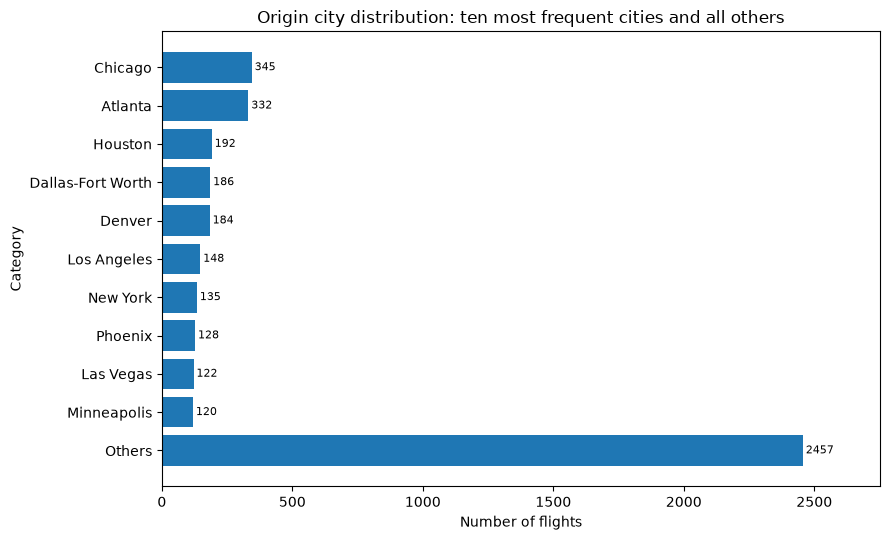

Saved figures/A2_O_CITY_bar.png


In [38]:
save_bar_chart(o_city_report, "O_CITY",
               "Origin city distribution: ten most frequent cities and all others",
               horizontal=True)

Chicago is the most frequently recorded origin city with 345 flights, which is 7.93 per cent of the 4,349 records. Departures are spread widely across 213 cities, since the ten most common cities together account for only 43.50 per cent of flights and 39 cities appear just once.

#### O_STATE

The same frequency summary is applied to the origin state, which groups the origin cities into a smaller number of categories.

In [39]:
o_state_full = frequency_table("O_STATE")
o_state_report = report_table(o_state_full)

o_state_full.to_csv("outputs/A2_O_STATE_frequency_full.csv", index=False)
o_state_report.to_csv("outputs/A2_O_STATE_report_table.csv", index=False)

describe_categorical("O_STATE", o_state_full)
print()
print("Categories in the full table:", len(o_state_full))
print("Rows in the report table:", len(o_state_report))

o_state_report

Attribute: O_STATE
  Total observations n  : 4349
  Non-missing count     : 4349
  Missing count         : 0
  Unique categories     : 52
  Mode                  : TX
  Mode frequency        : 552
  Mode percentage       : 12.69%
  Share of top ten      : 65.49%
  Categories seen once  : 2

Categories in the full table: 52
Rows in the report table: 11


,Category,Frequency,Percentage
0,TX,552,12.69
1,CA,511,11.75
2,IL,358,8.23
3,GA,340,7.82
4,FL,292,6.71
5,CO,196,4.51
6,NY,179,4.12
7,AZ,150,3.45
8,NV,138,3.17
9,MI,132,3.04


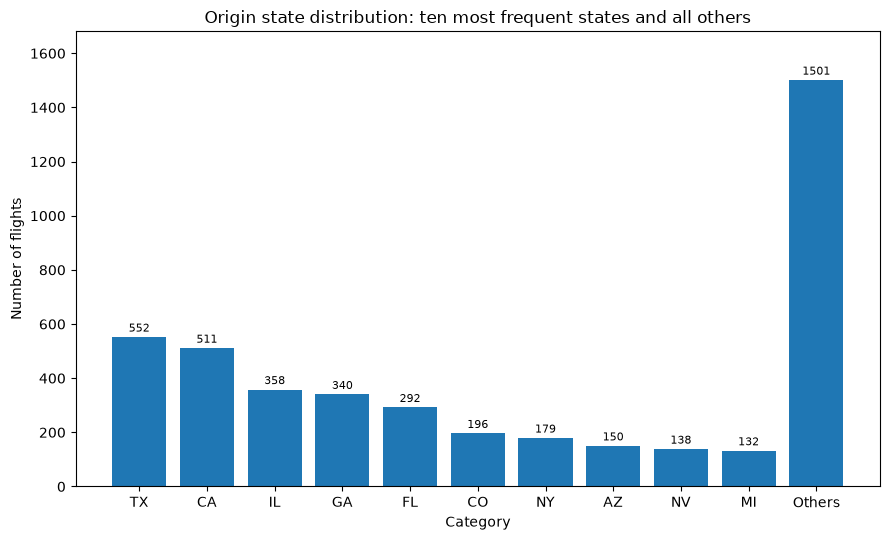

Saved figures/A2_O_STATE_bar.png


In [40]:
save_bar_chart(o_state_report, "O_STATE",
               "Origin state distribution: ten most frequent states and all others",
               horizontal=False)

Texas is the most frequently recorded origin state with 552 flights, or 12.69 per cent of records. Origin states are far more concentrated than origin cities, with the ten most common of the 52 states covering 65.49 per cent of flights.

#### D_CITY

The frequency summary is repeated for the destination city so that the arrival pattern can be compared with the departure pattern.

In [41]:
d_city_full = frequency_table("D_CITY")
d_city_report = report_table(d_city_full)

d_city_full.to_csv("outputs/A2_D_CITY_frequency_full.csv", index=False)
d_city_report.to_csv("outputs/A2_D_CITY_report_table.csv", index=False)

describe_categorical("D_CITY", d_city_full)
print()
print("Categories in the full table:", len(d_city_full))
print("Rows in the report table:", len(d_city_report))

d_city_report

Attribute: D_CITY
  Total observations n  : 4349
  Non-missing count     : 4349
  Missing count         : 0
  Unique categories     : 214
  Mode                  : Atlanta
  Mode frequency        : 353
  Mode percentage       : 8.12%
  Share of top ten      : 42.19%
  Categories seen once  : 42

Categories in the full table: 214
Rows in the report table: 11


,Category,Frequency,Percentage
0,Atlanta,353,8.12
1,Chicago,280,6.44
2,Houston,201,4.62
3,Dallas-Fort Worth,196,4.51
4,Los Angeles,175,4.02
5,Denver,161,3.70
6,San Francisco,121,2.78
7,Minneapolis,119,2.74
8,Phoenix,117,2.69
9,Las Vegas,112,2.58


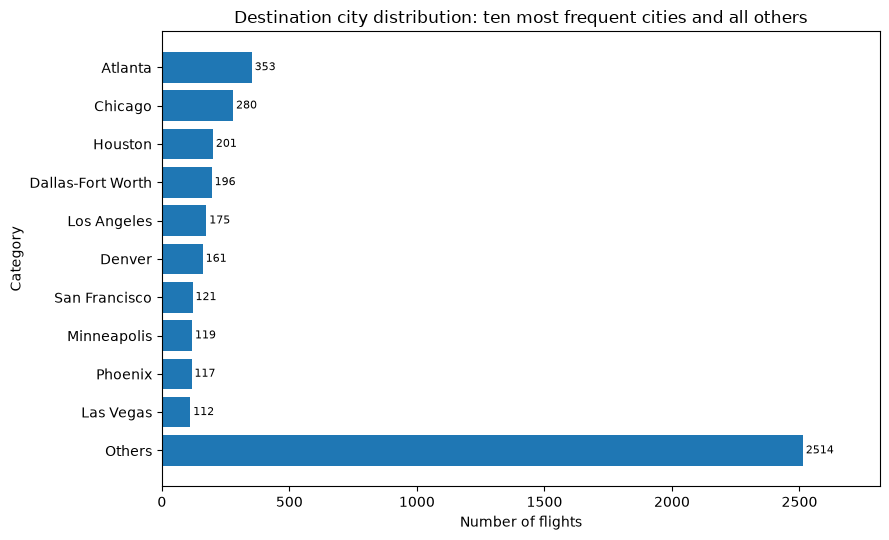

Saved figures/A2_D_CITY_bar.png


In [42]:
save_bar_chart(d_city_report, "D_CITY",
               "Destination city distribution: ten most frequent cities and all others",
               horizontal=True)

Atlanta is the most frequently recorded destination city with 353 flights, or 8.12 per cent of records. Arrivals are dispersed across 214 cities in much the same way as departures, with the ten most common cities covering 42.19 per cent and 42 cities appearing only once.

#### D_STATE

The frequency summary is repeated for the destination state, again showing the ten most common states with the rest combined.

In [43]:
d_state_full = frequency_table("D_STATE")
d_state_report = report_table(d_state_full)

d_state_full.to_csv("outputs/A2_D_STATE_frequency_full.csv", index=False)
d_state_report.to_csv("outputs/A2_D_STATE_report_table.csv", index=False)

describe_categorical("D_STATE", d_state_full)
print()
print("Categories in the full table:", len(d_state_full))
print("Rows in the report table:", len(d_state_report))

d_state_report

Attribute: D_STATE
  Total observations n  : 4349
  Non-missing count     : 4349
  Missing count         : 0
  Unique categories     : 51
  Mode                  : TX
  Mode frequency        : 577
  Mode percentage       : 13.27%
  Share of top ten      : 64.5%
  Categories seen once  : 1

Categories in the full table: 51
Rows in the report table: 11


,Category,Frequency,Percentage
0,TX,577,13.27
1,CA,565,12.99
2,GA,365,8.39
3,FL,305,7.01
4,IL,288,6.62
5,CO,179,4.12
6,NY,143,3.29
7,AZ,135,3.10
8,MI,124,2.85
9,NV,124,2.85


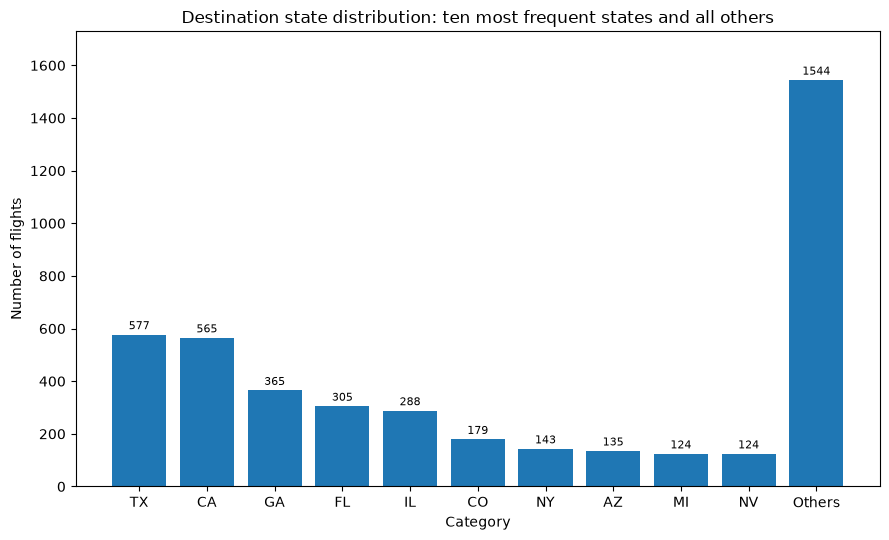

Saved figures/A2_D_STATE_bar.png


In [44]:
save_bar_chart(d_state_report, "D_STATE",
               "Destination state distribution: ten most frequent states and all others",
               horizontal=False)

Texas is also the most frequently recorded destination state, with 577 flights or 13.27 per cent of records. The 51 destination states show a similar concentration to the origin states, with the top ten accounting for 64.50 per cent, and Michigan and Nevada tie on 124 flights each.

#### AIRLINE_NAME

All six airlines are shown individually because the attribute has few enough categories to display in full, so no Others row is needed.

In [45]:
airline_name_full = frequency_table("AIRLINE_NAME")
airline_name_report = report_table(airline_name_full)

airline_name_full.to_csv("outputs/A2_AIRLINE_NAME_frequency_full.csv", index=False)
airline_name_report.to_csv("outputs/A2_AIRLINE_NAME_report_table.csv", index=False)

describe_categorical("AIRLINE_NAME", airline_name_full)
print()
print("Categories in the full table:", len(airline_name_full))
print("Rows in the report table:", len(airline_name_report))

airline_name_report

Attribute: AIRLINE_NAME
  Total observations n  : 4349
  Non-missing count     : 4349
  Missing count         : 0
  Unique categories     : 6
  Mode                  : Southwest Airlines Co.
  Mode frequency        : 1207
  Mode percentage       : 27.75%
  Share of top ten      : 100.0%
  Categories seen once  : 0

Categories in the full table: 6
Rows in the report table: 6


,Category,Frequency,Percentage
0,Southwest Airlines Co.,1207,27.75
1,Delta Air Lines Inc.,839,19.29
2,American Airlines Inc.,733,16.85
3,Skywest Airlines Inc.,569,13.08
4,Atlantic Southeast Airlines,521,11.98
5,United Air Lines Inc.,480,11.04


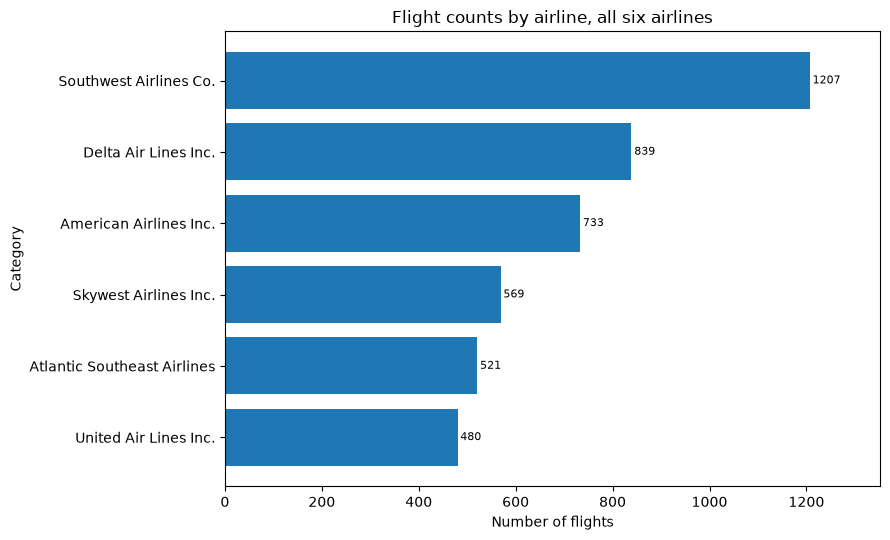

Saved figures/A2_AIRLINE_NAME_bar.png


In [46]:
save_bar_chart(airline_name_report, "AIRLINE_NAME",
               "Flight counts by airline, all six airlines",
               horizontal=True)

Southwest Airlines Co. is the most frequently recorded airline with 1,207 flights, or 27.75 per cent of records. The six airlines are spread far more evenly than the location attributes, ranging from 11.04 per cent for United Air Lines Inc. up to 27.75 per cent for Southwest Airlines Co.

### A2.2 Batch 1 summary table

The five individual summaries are collected into one compact table. This is the table that will be quoted in the report, with the full frequency tables kept in `outputs/` as supporting evidence.

In [47]:
summary_rows = []
full_tables = {
    "O_CITY": o_city_full,
    "O_STATE": o_state_full,
    "D_CITY": d_city_full,
    "D_STATE": d_state_full,
    "AIRLINE_NAME": airline_name_full,
}

for attribute in batch1_attributes:
    full_table = full_tables[attribute]
    column = df_raw[attribute]
    summary_rows.append({
        "Attribute": attribute,
        "N": len(df_raw),
        "Missing": int(column.isna().sum()),
        "Unique Categories": int(column.nunique(dropna=True)),
        "Mode": full_table.loc[0, "Category"],
        "Mode Frequency": int(full_table.loc[0, "Frequency"]),
        "Mode Percentage": full_table.loc[0, "Percentage"],
    })

batch1_summary = pd.DataFrame(summary_rows)
batch1_summary.to_csv("outputs/A2_batch1_categorical_summary.csv", index=False)
batch1_summary

,Attribute,N,Missing,Unique Categories,Mode,Mode Frequency,Mode Percentage
0,O_CITY,4349,0,213,Chicago,345,7.93
1,O_STATE,4349,0,52,TX,552,12.69
2,D_CITY,4349,0,214,Atlanta,353,8.12
3,D_STATE,4349,0,51,TX,577,13.27
4,AIRLINE_NAME,4349,0,6,Southwest Airlines Co.,1207,27.75


Every attribute in this batch has 4,349 observations with no missing values. The number of unique categories is the clearest difference between them, ranging from 6 airlines up to 214 destination cities, and the mode percentage shows how much of the data the largest single category holds in each case.

### A2.3 Validation of Batch 1

These checks confirm the tables and figures mechanically instead of by eye. One point needs explaining. Each percentage is rounded to two decimal places for display, so a table with many rows can drift slightly from an exact 100 per cent total. The tolerance below allows half a hundredth of a percentage point per row, which is the largest possible rounding error, so a table of 213 categories is permitted to drift by about one percentage point while the report tables must stay within a few hundredths. The frequency totals are checked exactly, since they involve no rounding.

In [48]:
def percentages_sum_to_100(table):
    """Allow for the rounding error introduced by displaying each percentage to two decimals."""
    tolerance = 0.005 * len(table) + 0.01
    return abs(table["Percentage"].sum() - 100) <= tolerance


def report_table_is_top10_plus_others(full_table, report):
    """Confirm a report table holds the top ten rows plus one correct Others row."""
    if len(report) != 11 or report.iloc[-1]["Category"] != "Others":
        return False
    top_matches = report.head(10).reset_index(drop=True).equals(full_table.head(10).reset_index(drop=True))
    expected_others = int(full_table["Frequency"].sum()) - int(full_table["Frequency"].head(10).sum())
    return top_matches and int(report.iloc[-1]["Frequency"]) == expected_others


expected_figures = [f"figures/A2_{a}_bar.png" for a in batch1_attributes]
expected_outputs = [f"outputs/A2_{a}_frequency_full.csv" for a in batch1_attributes]
expected_outputs += [f"outputs/A2_{a}_report_table.csv" for a in batch1_attributes]
expected_outputs += ["outputs/A2_batch1_categorical_summary.csv"]

report_tables = {"O_CITY": o_city_report, "O_STATE": o_state_report,
                 "D_CITY": d_city_report, "D_STATE": d_state_report,
                 "AIRLINE_NAME": airline_name_report}
print("Files expected:", len(expected_figures), "figures and", len(expected_outputs), "tables")

Files expected: 5 figures and 11 tables


In [49]:
a2_checks = {
    "1. All five attributes exist": all(a in df_raw.columns for a in batch1_attributes),
    "2. Missing count is zero for all five": all(df_raw[a].isna().sum() == 0 for a in batch1_attributes),
    "3. Frequency totals equal 4349 for every attribute": all(int(full_tables[a]["Frequency"].sum()) == 4349 for a in batch1_attributes),
    "4. Percentage totals are 100 within rounding": all(percentages_sum_to_100(full_tables[a]) for a in batch1_attributes)
                                                    and all(percentages_sum_to_100(report_tables[a]) for a in batch1_attributes),
    "5. Full table row counts equal the unique counts": all(len(full_tables[a]) == df_raw[a].nunique(dropna=True) for a in batch1_attributes),
    "6. O_CITY report table is top 10 plus correct Others": report_table_is_top10_plus_others(o_city_full, o_city_report),
    "7. O_STATE report table is top 10 plus correct Others": report_table_is_top10_plus_others(o_state_full, o_state_report),
    "8. D_CITY report table is top 10 plus correct Others": report_table_is_top10_plus_others(d_city_full, d_city_report),
    "9. D_STATE report table is top 10 plus correct Others": report_table_is_top10_plus_others(d_state_full, d_state_report),
    "10. AIRLINE_NAME report table holds all six airlines": len(airline_name_report) == 6 and df_raw["AIRLINE_NAME"].nunique() == 6,
    "11. AIRLINE_NAME has no Others row": "Others" not in list(airline_name_report["Category"]),
    "12. Summary mode equals the highest-frequency category": all(
        batch1_summary.loc[i, "Mode"] == full_tables[a]["Category"].iloc[0]
        and int(batch1_summary.loc[i, "Mode Frequency"]) == int(full_tables[a]["Frequency"].max())
        for i, a in enumerate(batch1_attributes)),
    "13. All five figure files exist": all(os.path.exists(p) for p in expected_figures),
    "14. All expected output CSV files exist": all(os.path.exists(p) for p in expected_outputs),
    "15. df_raw remains 4349 by 25": df_raw.shape == (4349, 25),
}

for description, passed in a2_checks.items():
    print("PASS" if passed else "FAIL", description)

print()
print("Checks passed:", sum(a2_checks.values()), "of", len(a2_checks))

PASS 1. All five attributes exist
PASS 2. Missing count is zero for all five
PASS 3. Frequency totals equal 4349 for every attribute
PASS 4. Percentage totals are 100 within rounding
PASS 5. Full table row counts equal the unique counts
PASS 6. O_CITY report table is top 10 plus correct Others
PASS 7. O_STATE report table is top 10 plus correct Others
PASS 8. D_CITY report table is top 10 plus correct Others
PASS 9. D_STATE report table is top 10 plus correct Others
PASS 10. AIRLINE_NAME report table holds all six airlines
PASS 11. AIRLINE_NAME has no Others row
PASS 12. Summary mode equals the highest-frequency category
PASS 13. All five figure files exist
PASS 14. All expected output CSV files exist
PASS 15. df_raw remains 4349 by 25

Checks passed: 15 of 15


All Batch 1 checks pass. The five nominal attributes are complete, their frequencies account for every one of the 4,349 records, the Others rows contain exactly the categories left out of each top ten, and the raw data is unchanged at 4,349 rows and 25 columns. The remaining A2 attributes are covered in later batches.

### A2.4 Numeric trip measures and binary flight-status attributes

Batch 2 covers four more attributes, and they fall into two groups that need different treatment.

`SCHEDULED_TIME` and `DISTANCE` are quantitative ratio attributes, so the full set of numeric summary statistics is meaningful for them. Each one gets a count, mean, median, minimum, maximum, range, variance, standard deviation and the first and third quartiles.

`DIVERTED` and `CANCELLED` are binary nominal attributes. They are stored as the digits 0 and 1, but as A1 established those digits are labels for two flight statuses rather than measured amounts. Averaging them would produce a number with no meaning as a measurement, so they are summarised with frequency, percentage, mode and the number of distinct categories, exactly as the location attributes were in Batch 1.

The variance and standard deviation are sample statistics calculated with `ddof=1`, which divides by `n - 1` rather than `n`. This is the pandas default and it is stated explicitly in the code below so the choice is visible rather than assumed.

One note on section numbering. The headings `A2.2` and `A2.3` were already used by the Batch 1 summary and validation, so this batch continues from `A2.4` instead of reusing a number.

The first cell confirms that all four attributes exist, that none of them has missing values, and that the raw data still has its original shape. Percentages later use the non-missing count as the denominator, so this also confirms the denominator is the full 4,349 rows.

In [50]:
batch2_attributes = ["SCHEDULED_TIME", "DISTANCE", "DIVERTED", "CANCELLED"]

print("Raw data shape:", df_raw.shape)
for attribute in batch2_attributes:
    column = df_raw[attribute]
    print(f"{attribute:<16} present={attribute in df_raw.columns}  "
          f"missing={int(column.isna().sum())}  dtype={column.dtype}")

print()
print("All four present:", all(a in df_raw.columns for a in batch2_attributes))
print("All four complete:", all(df_raw[a].isna().sum() == 0 for a in batch2_attributes))
print("Shape is 4349 by 25:", df_raw.shape == (4349, 25))

Raw data shape: (4349, 25)
SCHEDULED_TIME   present=True  missing=0  dtype=int64
DISTANCE         present=True  missing=0  dtype=int64
DIVERTED         present=True  missing=0  dtype=int64
CANCELLED        present=True  missing=0  dtype=int64

All four present: True
All four complete: True
Shape is 4349 by 25: True


Two short helpers are used for the numeric attributes. `numeric_summary` calculates every statistic straight from the raw column, with `ddof=1` written out in full so the sample calculation is explicit. Nothing is rounded at this stage, because rounding before a calculation would change the result.

`summary_to_table` only formats the finished numbers for display. Whole numbers are shown without decimals and everything else to two decimal places, which keeps the report table readable without hiding the underlying precision.

In [51]:
def numeric_summary(attribute_name):
    """Return the summary statistics that are meaningful for a quantitative ratio attribute."""
    column = df_raw[attribute_name]
    return {
        "N": int(column.notna().sum()),
        "Missing": int(column.isna().sum()),
        "Mean": column.mean(),
        "Median": column.median(),
        "Minimum": column.min(),
        "Maximum": column.max(),
        "Range": column.max() - column.min(),
        "Variance": column.var(ddof=1),            # sample variance, divides by n - 1
        "Standard deviation": column.std(ddof=1),  # sample standard deviation
        "Q1": column.quantile(0.25),
        "Q3": column.quantile(0.75),
        "IQR": column.quantile(0.75) - column.quantile(0.25),
        "Skewness": column.skew(),          # pandas sample skewness, no extra library needed
    }

In [52]:
def format_value(value):
    """Show whole numbers without decimals and all other values to two decimal places."""
    if float(value).is_integer():
        return str(int(value))
    return f"{value:.2f}"


def summary_to_table(summary):
    """Turn a summary dictionary into a two-column report-ready table."""
    rows = [{"Statistic": name, "Value": format_value(value)} for name, value in summary.items()]
    return pd.DataFrame(rows)

#### SCHEDULED_TIME

`SCHEDULED_TIME` is the planned duration of the flight in minutes. The full set of numeric statistics is calculated and then printed at full precision before the rounded report table, so the exact values remain visible in the notebook.

In [53]:
scheduled_time_summary = numeric_summary("SCHEDULED_TIME")

print("Full precision values for SCHEDULED_TIME:")
for name, value in scheduled_time_summary.items():
    print(f"  {name:<20} {value}")

scheduled_time_table = summary_to_table(scheduled_time_summary)
scheduled_time_table.to_csv("outputs/A2_SCHEDULED_TIME_summary.csv", index=False)
scheduled_time_table

Full precision values for SCHEDULED_TIME:
  N                    4349
  Missing              0
  Mean                 140.7408599678087
  Median               121.0
  Minimum              37
  Maximum              602
  Range                565
  Variance             5343.104174145291
  Standard deviation   73.09654009695186
  Q1                   86.0
  Q3                   170.0
  IQR                  84.0
  Skewness             1.43418531322791


,Statistic,Value
0,N,4349
1,Missing,0
2,Mean,140.74
3,Median,121
4,Minimum,37
5,Maximum,602
6,Range,565
7,Variance,5343.10
8,Standard deviation,73.10
9,Q1,86


The histogram below uses bins 30 minutes wide, which is a readable width for flight durations and keeps the number of bars small enough to interpret. Every observation is included and none is altered.

This binning exists only to draw the distribution. It is not the B1 preprocessing task, no smoothing is applied and no new binned attribute is created.

In [54]:
def save_histogram(attribute_name, bin_edges, title, x_label):
    """Draw one histogram of an attribute and save it as a PNG for the report."""
    figure, axes = plt.subplots(figsize=(8, 5))
    axes.hist(df_raw[attribute_name], bins=bin_edges, edgecolor="white")
    axes.set_title(title)
    axes.set_xlabel(x_label)
    axes.set_ylabel("Number of flights")
    figure.tight_layout()

    figure_path = f"figures/A2_{attribute_name}_hist.png"
    figure.savefig(figure_path, dpi=200)
    plt.show()
    print("Saved", figure_path)

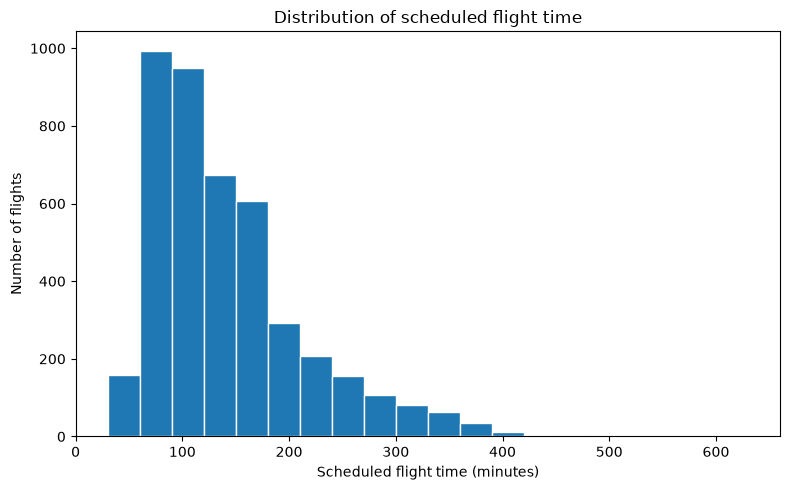

Saved figures/A2_SCHEDULED_TIME_hist.png


In [55]:
scheduled_time_bins = np.arange(30, 631, 30)  # 30 minute wide bins covering 37 to 602

save_histogram("SCHEDULED_TIME", scheduled_time_bins,
               "Distribution of scheduled flight time",
               "Scheduled flight time (minutes)")

Scheduled flight times average 140.74 minutes with a median of 121 minutes, and they range from 37 to 602 minutes. The mean sits well above the median and the histogram thins out gradually towards the higher values, so the distribution is right skewed with most flights concentrated below about three hours and a long upper tail of longer scheduled flights.

#### DISTANCE

`DISTANCE` is the distance between the two airports. The dataset does not state the unit of measurement anywhere, so no unit is quoted in the table, the chart or the interpretation, and the values are reported as they appear in the file.

In [56]:
distance_summary = numeric_summary("DISTANCE")

print("Full precision values for DISTANCE:")
for name, value in distance_summary.items():
    print(f"  {name:<20} {value}")

distance_table = summary_to_table(distance_summary)
distance_table.to_csv("outputs/A2_DISTANCE_summary.csv", index=False)
distance_table

Full precision values for DISTANCE:
  N                    4349
  Missing              0
  Mean                 810.8167394803403
  Median               640.0
  Minimum              67
  Maximum              4983
  Range                4916
  Variance             342896.2366470482
  Standard deviation   585.5734254959392
  Q1                   391.0
  Q3                   1050.0
  IQR                  659.0
  Skewness             1.524236850737021


,Statistic,Value
0,N,4349
1,Missing,0
2,Mean,810.82
3,Median,640
4,Minimum,67
5,Maximum,4983
6,Range,4916
7,Variance,342896.24
8,Standard deviation,585.57
9,Q1,391


The distance histogram uses bins 250 units wide, which again gives around twenty readable bars across the observed range. All observations are kept and no normalisation is applied here, since scaling belongs to the later B2 task.

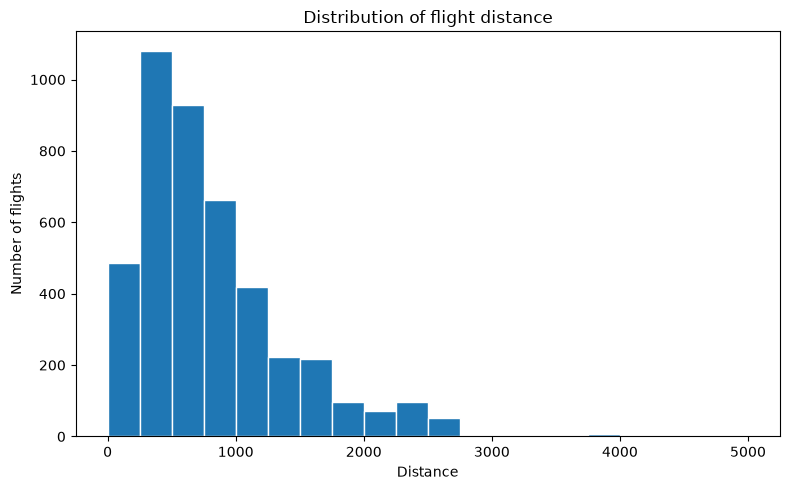

Saved figures/A2_DISTANCE_hist.png


In [57]:
distance_bins = np.arange(0, 5001, 250)  # 250 unit wide bins covering 67 to 4983

save_histogram("DISTANCE", distance_bins,
               "Distribution of flight distance",
               "Distance")

The mean distance is 810.82 and the median is 640, with values ranging from 67 to 4,983 and a standard deviation of 585.57. The mean again exceeds the median and the histogram falls away towards the larger values, so distance is right skewed with the majority of flights in the shorter part of the range and progressively fewer long-distance flights.

#### DIVERTED

`DIVERTED` records whether the aircraft landed at an airport outside its schedule. It is treated as a nominal attribute, so the summary uses frequency, percentage, mode and the count of distinct categories. No mean, variance, standard deviation or quartile is calculated for it.

The digits 0 and 1 are given readable labels for display only. The helper builds a new table and never writes those labels back into `df_raw`.

In [58]:
def binary_frequency_table(attribute_name, meanings):
    """Frequency table for a binary nominal attribute, with readable display labels."""
    counts = df_raw[attribute_name].value_counts().sort_index()
    valid_count = int(df_raw[attribute_name].notna().sum())

    rows = []
    for category, frequency in counts.items():
        rows.append({
            "Category": int(category),
            "Meaning": meanings[int(category)],
            "Frequency": int(frequency),
            "Percentage": round(100 * frequency / valid_count, 2),
        })
    return pd.DataFrame(rows)

In [59]:
def binary_summary(attribute_name, frequency):
    """Compact nominal summary. No mean or standard deviation is calculated here."""
    column = df_raw[attribute_name]
    most_common = frequency.sort_values("Frequency", ascending=False).iloc[0]

    return pd.DataFrame([{
        "Attribute": attribute_name,
        "N": len(df_raw),
        "Missing": int(column.isna().sum()),
        "Unique Categories": int(column.nunique(dropna=True)),
        "Mode": int(most_common["Category"]),
        "Mode Meaning": most_common["Meaning"],
        "Mode Frequency": int(most_common["Frequency"]),
        "Mode Percentage": most_common["Percentage"],
    }])

In [60]:
diverted_meanings = {0: "Not diverted", 1: "Diverted"}

diverted_frequency = binary_frequency_table("DIVERTED", diverted_meanings)
diverted_summary = binary_summary("DIVERTED", diverted_frequency)

diverted_frequency.to_csv("outputs/A2_DIVERTED_frequency.csv", index=False)
diverted_summary.to_csv("outputs/A2_DIVERTED_summary.csv", index=False)

print("Frequencies sum to:", int(diverted_frequency["Frequency"].sum()))
print("Percentages sum to:", round(diverted_frequency["Percentage"].sum(), 2))
diverted_frequency

Frequencies sum to: 4349
Percentages sum to: 100.0


,Category,Meaning,Frequency,Percentage
0,0,Not diverted,4331,99.59
1,1,Diverted,18,0.41


In [61]:
diverted_summary

,Attribute,N,Missing,Unique Categories,Mode,Mode Meaning,Mode Frequency,Mode Percentage
0,DIVERTED,4349,0,2,0,Not diverted,4331,99.59


In [62]:
def save_binary_bar_chart(frequency, attribute_name, title):
    """Draw one bar chart of a binary flight-status attribute using readable labels."""
    figure, axes = plt.subplots(figsize=(7, 5))
    bars = axes.bar(frequency["Meaning"], frequency["Frequency"])

    axes.bar_label(bars, padding=2)
    axes.set_title(title)
    axes.set_xlabel("Flight status")
    axes.set_ylabel("Number of flights")
    axes.margins(y=0.15)
    figure.tight_layout()

    figure_path = f"figures/A2_{attribute_name}_bar.png"
    figure.savefig(figure_path, dpi=200)
    plt.show()
    print("Saved", figure_path)

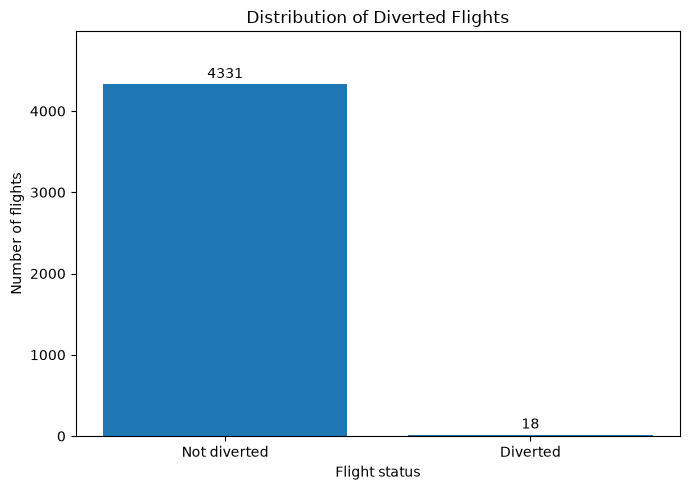

Saved figures/A2_DIVERTED_bar.png


In [63]:
save_binary_bar_chart(diverted_frequency, "DIVERTED",
                      "Distribution of Diverted Flights")

Almost no flights in this dataset were diverted, with 4,331 records or 99.59 per cent not diverted and 18 records or 0.41 per cent diverted. The mode is 0, meaning not diverted, and the two categories are extremely unbalanced.

#### CANCELLED

`CANCELLED` records whether the flight was cancelled, where 1 indicates a cancelled flight. It is treated the same way as `DIVERTED`, using the nominal summaries only.

In [64]:
cancelled_meanings = {0: "Not cancelled", 1: "Cancelled"}

cancelled_frequency = binary_frequency_table("CANCELLED", cancelled_meanings)
cancelled_summary = binary_summary("CANCELLED", cancelled_frequency)

cancelled_frequency.to_csv("outputs/A2_CANCELLED_frequency.csv", index=False)
cancelled_summary.to_csv("outputs/A2_CANCELLED_summary.csv", index=False)

print("Frequencies sum to:", int(cancelled_frequency["Frequency"].sum()))
print("Percentages sum to:", round(cancelled_frequency["Percentage"].sum(), 2))
cancelled_frequency

Frequencies sum to: 4349
Percentages sum to: 100.0


,Category,Meaning,Frequency,Percentage
0,0,Not cancelled,4283,98.48
1,1,Cancelled,66,1.52


In [65]:
cancelled_summary

,Attribute,N,Missing,Unique Categories,Mode,Mode Meaning,Mode Frequency,Mode Percentage
0,CANCELLED,4349,0,2,0,Not cancelled,4283,98.48


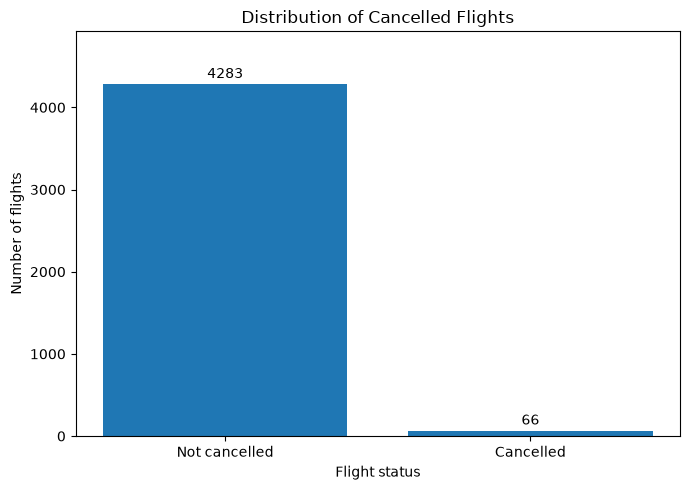

Saved figures/A2_CANCELLED_bar.png


In [66]:
save_binary_bar_chart(cancelled_frequency, "CANCELLED",
                      "Distribution of Cancelled Flights")

Cancellations are also rare, with 4,283 records or 98.48 per cent not cancelled and 66 records or 1.52 per cent cancelled. The mode is 0, meaning not cancelled, and cancelled flights are about three and a half times as common in this dataset as diverted flights.

### A2.5 Batch 2 overview

The two numeric attributes are placed side by side so their scales can be compared directly. Both are ratio attributes, but they measure different quantities, so the comparison is about shape rather than about which numbers are larger.

In [67]:
numeric_comparison = pd.DataFrame({
    "Statistic": list(scheduled_time_summary.keys()),
    "SCHEDULED_TIME": [format_value(v) for v in scheduled_time_summary.values()],
    "DISTANCE": [format_value(v) for v in distance_summary.values()],
})
numeric_comparison

,Statistic,SCHEDULED_TIME,DISTANCE
0,N,4349,4349
1,Missing,0,0
2,Mean,140.74,810.82
3,Median,121,640
4,Minimum,37,67
5,Maximum,602,4983
6,Range,565,4916
7,Variance,5343.10,342896.24
8,Standard deviation,73.10,585.57
9,Q1,86,391


The overview table below covers all four attributes. Numeric and nominal attributes need different statistics, so rather than forcing them into one misleading grid of columns, the last column holds a short written summary built from the values calculated above.

In [68]:
overview_rows = [
    {"Attribute": "SCHEDULED_TIME", "Attribute Type": "Ratio",
     "N": scheduled_time_summary["N"], "Missing": scheduled_time_summary["Missing"],
     "Primary Summary": f"Mean {scheduled_time_summary['Mean']:.2f} minutes, "
                        f"median {format_value(scheduled_time_summary['Median'])}, "
                        f"range {format_value(scheduled_time_summary['Minimum'])} to "
                        f"{format_value(scheduled_time_summary['Maximum'])}"},
    {"Attribute": "DISTANCE", "Attribute Type": "Ratio",
     "N": distance_summary["N"], "Missing": distance_summary["Missing"],
     "Primary Summary": f"Mean {distance_summary['Mean']:.2f}, "
                        f"median {format_value(distance_summary['Median'])}, "
                        f"range {format_value(distance_summary['Minimum'])} to "
                        f"{format_value(distance_summary['Maximum'])}"},
]

for name, frequency in [("DIVERTED", diverted_frequency), ("CANCELLED", cancelled_frequency)]:
    flagged = frequency[frequency["Category"] == 1].iloc[0]
    not_flagged = frequency[frequency["Category"] == 0].iloc[0]
    overview_rows.append({
        "Attribute": name, "Attribute Type": "Nominal",
        "N": len(df_raw), "Missing": int(df_raw[name].isna().sum()),
        "Primary Summary": f"{not_flagged['Meaning']} {not_flagged['Frequency']} "
                           f"({not_flagged['Percentage']}%), {flagged['Meaning']} "
                           f"{flagged['Frequency']} ({flagged['Percentage']}%)"})

batch2_overview = pd.DataFrame(overview_rows)
batch2_overview.to_csv("outputs/A2_batch2_overview.csv", index=False)
batch2_overview

,Attribute,Attribute Type,N,Missing,Primary Summary
0,SCHEDULED_TIME,Ratio,4349,0,"Mean 140.74 minutes, median 121, range 37 to 602"
1,DISTANCE,Ratio,4349,0,"Mean 810.82, median 640, range 67 to 4983"
2,DIVERTED,Nominal,4349,0,"Not diverted 4331 (99.59%), Diverted 18 (0.41%)"
3,CANCELLED,Nominal,4349,0,"Not cancelled 4283 (98.48%), Cancelled 66 (1.52%)"


### A2.6 Validation of Batch 2

These checks confirm the results mechanically. Two of them deserve a note.

The `ddof=1` checks do not simply trust the pandas default. The variance is recalculated by hand as the sum of squared deviations divided by `n - 1`, and the result is compared both with the reported value and with the population version that divides by `n`. Passing both parts proves the sample formula was used.

The final check re-reads `25740123.csv` from disk into a separate frame and compares it with `df_raw` row by row, which confirms the raw data was never modified in memory either.

In [69]:
def is_sample_variance(attribute_name, reported_variance):
    """Confirm a reported variance uses the sample formula with n - 1 in the denominator."""
    column = df_raw[attribute_name]
    n = int(column.notna().sum())
    manual_sample = ((column - column.mean()) ** 2).sum() / (n - 1)
    population = column.var(ddof=0)
    return bool(np.isclose(reported_variance, manual_sample)
                and not np.isclose(reported_variance, population))


expected_figures_b2 = ["figures/A2_SCHEDULED_TIME_hist.png", "figures/A2_DISTANCE_hist.png",
                       "figures/A2_DIVERTED_bar.png", "figures/A2_CANCELLED_bar.png"]
expected_outputs_b2 = ["outputs/A2_SCHEDULED_TIME_summary.csv", "outputs/A2_DISTANCE_summary.csv",
                       "outputs/A2_DIVERTED_frequency.csv", "outputs/A2_DIVERTED_summary.csv",
                       "outputs/A2_CANCELLED_frequency.csv", "outputs/A2_CANCELLED_summary.csv",
                       "outputs/A2_batch2_overview.csv"]

# Field names used anywhere in the two nominal summaries, checked against numeric statistics.
nominal_fields = (list(diverted_frequency.columns) + list(cancelled_frequency.columns)
                  + list(diverted_summary.columns) + list(cancelled_summary.columns))
numeric_statistic_names = {"mean", "median", "variance", "standard deviation",
                           "std", "q1", "q3", "iqr", "range", "skew"}

fresh_copy = pd.read_csv(RAW_CSV)
print("Nominal field names checked:", sorted(set(nominal_fields)))

Nominal field names checked: ['Attribute', 'Category', 'Frequency', 'Meaning', 'Missing', 'Mode', 'Mode Frequency', 'Mode Meaning', 'Mode Percentage', 'N', 'Percentage', 'Unique Categories']


In [70]:
b2_checks = {
    "1. All four attributes exist": all(a in df_raw.columns for a in batch2_attributes),
    "2. All four have zero missing values": all(df_raw[a].isna().sum() == 0 for a in batch2_attributes),
    "3. df_raw remains 4349 by 25": df_raw.shape == (4349, 25),
    "4. SCHEDULED_TIME N equals 4349": scheduled_time_summary["N"] == 4349,
    "5. DISTANCE N equals 4349": distance_summary["N"] == 4349,
    "6. Ranges equal maximum minus minimum": (
        scheduled_time_summary["Range"] == scheduled_time_summary["Maximum"] - scheduled_time_summary["Minimum"]
        and distance_summary["Range"] == distance_summary["Maximum"] - distance_summary["Minimum"]),
    "7. Variance uses ddof=1 for both attributes": (
        is_sample_variance("SCHEDULED_TIME", scheduled_time_summary["Variance"])
        and is_sample_variance("DISTANCE", distance_summary["Variance"])),
    "8. Standard deviation is the square root of the sample variance": (
        np.isclose(scheduled_time_summary["Standard deviation"], np.sqrt(scheduled_time_summary["Variance"]))
        and np.isclose(distance_summary["Standard deviation"], np.sqrt(distance_summary["Variance"]))),
    "9. Q1 <= Median <= Q3 for both attributes": (
        scheduled_time_summary["Q1"] <= scheduled_time_summary["Median"] <= scheduled_time_summary["Q3"]
        and distance_summary["Q1"] <= distance_summary["Median"] <= distance_summary["Q3"]),
    "10. DIVERTED frequencies sum to 4349": int(diverted_frequency["Frequency"].sum()) == 4349,
    "11. DIVERTED percentages sum to about 100": abs(diverted_frequency["Percentage"].sum() - 100) <= 0.05,
    "12. CANCELLED frequencies sum to 4349": int(cancelled_frequency["Frequency"].sum()) == 4349,
    "13. CANCELLED percentages sum to about 100": abs(cancelled_frequency["Percentage"].sum() - 100) <= 0.05,
    "14. DIVERTED count for 1 matches the P0 value of 18": int((df_raw["DIVERTED"] == 1).sum()) == 18,
    "15. CANCELLED count for 1 matches the P0 value of 66": int((df_raw["CANCELLED"] == 1).sum()) == 66,
    "16. No numeric statistics applied to the two binary attributes": all(
        field.strip().lower() not in numeric_statistic_names for field in nominal_fields),
    "17. All four figure files exist": all(os.path.exists(p) for p in expected_figures_b2),
    "18. All expected output CSV files exist": all(os.path.exists(p) for p in expected_outputs_b2),
    "19. df_raw still matches the file on disk": df_raw.equals(fresh_copy),
    "20. IQR equals Q3 minus Q1 for both attributes": (
        scheduled_time_summary["IQR"] == scheduled_time_summary["Q3"] - scheduled_time_summary["Q1"]
        and distance_summary["IQR"] == distance_summary["Q3"] - distance_summary["Q1"]),
    "21. IQR is 84 for SCHEDULED_TIME and 659 for DISTANCE": (
        scheduled_time_summary["IQR"] == 84 and distance_summary["IQR"] == 659),
    "22. Skewness rounds to 1.43 for SCHEDULED_TIME and 1.52 for DISTANCE": (
        round(scheduled_time_summary["Skewness"], 2) == 1.43
        and round(distance_summary["Skewness"], 2) == 1.52),
}

validation_b2 = pd.DataFrame({"Check": list(b2_checks.keys()),
                              "Result": ["PASS" if v else "FAIL" for v in b2_checks.values()]})
print("Checks passed:", sum(b2_checks.values()), "of", len(b2_checks))
validation_b2

Checks passed: 22 of 22


,Check,Result
0,1. All four attributes exist,PASS
1,2. All four have zero missing values,PASS
2,3. df_raw remains 4349 by 25,PASS
3,4. SCHEDULED_TIME N equals 4349,PASS
4,5. DISTANCE N equals 4349,PASS
5,6. Ranges equal maximum minus minimum,PASS
6,7. Variance uses ddof=1 for both attributes,PASS
7,8. Standard deviation is the square root of th...,PASS
8,9. Q1 <= Median <= Q3 for both attributes,PASS
9,10. DIVERTED frequencies sum to 4349,PASS


All Batch 2 checks pass. The two ratio attributes are summarised with the full numeric statistics using sample variance and sample standard deviation, the two binary attributes are summarised as categories with no numeric averaging, the recomputed diverted and cancelled counts agree with the P0 audit, and `df_raw` is still identical to the file on disk. The remaining A2 attributes are covered in later batches.

### A2.7 Taxi and Flight Durations

This group covers `TAXI_OUT`, `ELAPSED_TIME`, `AIR_TIME` and `TAXI_IN`. All four record a
duration in minutes, so all four are ratio attributes: they have a meaningful zero point, and
both differences and ratios between values make sense.

Unlike the attributes summarised earlier in A2, all four contain a small number of missing
values. The approved treatment for this group is attribute-wise removal. For each attribute a
temporary Series is built with `dropna()`, and the statistics are then recomputed from that
temporary Series. Each attribute is treated on its own, so the four attributes can end up with
different valid sample sizes.

`df_raw` is never modified. No row is deleted from it, no value is imputed and no blank is
turned into a zero. The raw frame stays at 4349 rows and 25 columns throughout the notebook,
and removal is applied only to the temporary Series.

Every attribute is summarised twice, once for the original column while its missing values are
still present and once after removal, so the effect of the treatment can be read directly from
the tables and the figures.

The first cell is a checkpoint rather than a result. It confirms the four attributes exist and
recomputes their missing counts and percentages straight from `df_raw`, so that any
disagreement with the P0 audit would be visible before the summaries are calculated.

In [71]:
duration_attributes = ["TAXI_OUT", "ELAPSED_TIME", "AIR_TIME", "TAXI_IN"]

print("Raw data shape:", df_raw.shape)
for attribute in duration_attributes:
    column = df_raw[attribute]
    missing = int(column.isna().sum())
    print(f"{attribute:<14} present={attribute in df_raw.columns}  "
          f"valid={int(column.notna().sum())}  missing={missing}  "
          f"({missing / len(df_raw) * 100:.2f} per cent)")

print()
print("All four present:", all(a in df_raw.columns for a in duration_attributes))
print("Shape is 4349 by 25:", df_raw.shape == (4349, 25))

Raw data shape: (4349, 25)
TAXI_OUT       present=True  valid=4284  missing=65  (1.49 per cent)
ELAPSED_TIME   present=True  valid=4265  missing=84  (1.93 per cent)
AIR_TIME       present=True  valid=4265  missing=84  (1.93 per cent)
TAXI_IN        present=True  valid=4282  missing=67  (1.54 per cent)

All four present: True
Shape is 4349 by 25: True


`describe_duration` calculates every statistic this group needs from a single Series. It takes a
Series rather than an attribute name so that exactly the same code can describe the original
column and the temporary cleaned Series. Using one code path for both sides removes any doubt
that a difference between the two could come from the calculation instead of from the data.

`ddof=1` is written out in full for the variance and the standard deviation, so the sample
formulas that divide by `n - 1` are explicit rather than inherited from a default.

One statistical point is worth stating before any result appears. The pandas methods used here,
including `mean`, `median`, `var`, `std`, `quantile` and `skew`, skip missing values by default.
The statistics of the original column are therefore already based only on its recorded values.

In [72]:
def describe_duration(series):
    """Return every statistic required for a duration attribute, ignoring missing values."""
    total_rows = len(series)
    missing = int(series.isna().sum())

    return {
        "Total rows": total_rows,
        "Valid N": int(series.notna().sum()),
        "Missing": missing,
        "Missing percentage": missing / total_rows * 100,
        "Mean": series.mean(),
        "Median": series.median(),
        "Minimum": series.min(),
        "Maximum": series.max(),
        "Range": series.max() - series.min(),
        "Variance": series.var(ddof=1),            # sample variance, divides by n - 1
        "Standard deviation": series.std(ddof=1),  # sample standard deviation
        "Q1": series.quantile(0.25),
        "Q3": series.quantile(0.75),
        "IQR": series.quantile(0.75) - series.quantile(0.25),
        "Skewness": series.skew(),
    }

`missing_value_comparison` carries out the removal for one attribute and returns both
descriptions. The `dropna()` call builds a new temporary Series and leaves `df_raw` untouched,
which is exactly what attribute-wise removal means here.

`comparison_table` then places the two descriptions side by side. Only the display is rounded,
using the same `format_value` helper as the earlier A2 tables, so every calculation above it
runs at full precision.

In [73]:
def missing_value_comparison(attribute_name):
    """Describe one attribute before and after attribute-wise removal of its missing values."""
    original = df_raw[attribute_name]
    clean = original.dropna()  # temporary Series only, df_raw is never changed
    return describe_duration(original), describe_duration(clean)


def comparison_table(before, after):
    """Place the before and after statistics side by side for the report."""
    return pd.DataFrame({
        "Statistic": list(before.keys()),
        "Original column": [format_value(value) for value in before.values()],
        "After removal": [format_value(after[name]) for name in before],
    })


duration_before, duration_after, duration_clean = {}, {}, {}
for attribute in duration_attributes:
    duration_before[attribute], duration_after[attribute] = missing_value_comparison(attribute)
    duration_clean[attribute] = df_raw[attribute].dropna()

print("Described attributes:", list(duration_before))

Described attributes: ['TAXI_OUT', 'ELAPSED_TIME', 'AIR_TIME', 'TAXI_IN']


Each attribute also gets one two-panel figure. The bin edges come from `np.histogram_bin_edges`
using the Freedman-Diaconis rule, so the bin width follows from the spread of the data rather
than from a bin count chosen by hand. The same edges and the same x-axis limits are applied to
both panels, which is what makes the two shapes directly comparable.

A missing value has no numeric position, so it cannot be drawn as a bar. The left panel
therefore plots the recorded values of the original column and reports the missing count in an
annotation instead. Nothing is converted to zero to force missing values onto the axis.

This binning exists only to draw these distributions. It is not the B1 preprocessing task, no
smoothing is applied and no new binned attribute is created.

In [74]:
def save_missing_comparison_figure(attribute_name):
    """Draw the recorded values before and after removal using one shared set of bin edges."""
    original = df_raw[attribute_name]
    clean = duration_clean[attribute_name]
    bin_edges = np.histogram_bin_edges(clean, bins="fd")  # Freedman-Diaconis, no manual count
    before, after = duration_before[attribute_name], duration_after[attribute_name]

    notes = [f"Total rows {before['Total rows']}\nValid N {before['Valid N']}\n"
             f"Missing {before['Missing']}\n"
             f"Missing {before['Missing percentage']:.2f} per cent",
             f"Rows after removal {after['Total rows']}\nMissing 0"]
    panel_titles = [f"{attribute_name}: original recorded values",
                    f"{attribute_name}: after removal"]

    figure, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
    for panel, values, title, note in zip(axes, [original.dropna(), clean], panel_titles, notes):
        # A thin edge line keeps the bars visible when the rule returns many narrow bins.
        panel.hist(values, bins=bin_edges, edgecolor="white", linewidth=0.3)
        panel.set_xlim(bin_edges[0], bin_edges[-1])
        panel.set_title(title)
        panel.set_xlabel(f"{attribute_name} (minutes)")
        panel.annotate(note, xy=(0.97, 0.95), xycoords="axes fraction",
                       ha="right", va="top", fontsize=9)

    axes[0].set_ylabel("Number of flights")
    figure.tight_layout()
    figure_path = f"figures/A2_{attribute_name}_missing_comparison.png"
    figure.savefig(figure_path, dpi=200)
    plt.show()
    print("Saved", figure_path, "using", len(bin_edges) - 1, "shared bins")

#### TAXI_OUT

`TAXI_OUT` is the time in minutes between leaving the departure gate and take-off. The
comparison table below is printed at full precision first, so the exact values stay visible
next to the rounded report table.

In [75]:
taxi_out_before, taxi_out_after = duration_before["TAXI_OUT"], duration_after["TAXI_OUT"]

print("Full precision values for TAXI_OUT after removal:")
for name, value in taxi_out_after.items():
    print(f"  {name:<20} {value}")

taxi_out_comparison = comparison_table(taxi_out_before, taxi_out_after)
taxi_out_comparison.to_csv("outputs/A2_TAXI_OUT_missing_comparison.csv", index=False)
taxi_out_comparison

Full precision values for TAXI_OUT after removal:
  Total rows           4284
  Valid N              4284
  Missing              0
  Missing percentage   0.0
  Mean                 16.146825396825395
  Median               14.0
  Minimum              1.0
  Maximum              110.0
  Range                109.0
  Variance             79.7610662678956
  Standard deviation   8.93090512030531
  Q1                   11.0
  Q3                   18.0
  IQR                  7.0
  Skewness             3.163441671389028


,Statistic,Original column,After removal
0,Total rows,4349,4284
1,Valid N,4284,4284
2,Missing,65,0
3,Missing percentage,1.49,0
4,Mean,16.15,16.15
5,Median,14,14
6,Minimum,1,1
7,Maximum,110,110
8,Range,109,109
9,Variance,79.76,79.76


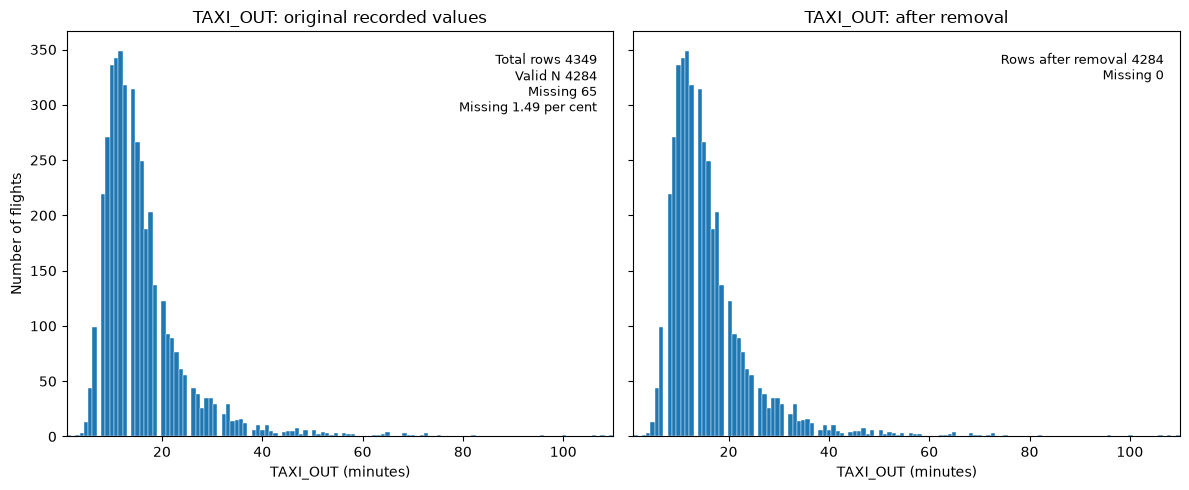

Saved figures/A2_TAXI_OUT_missing_comparison.png using 127 shared bins


In [76]:
save_missing_comparison_figure("TAXI_OUT")

`TAXI_OUT` has 4284 recorded values and 65 missing values, which is 1.49 per cent of the 4349
rows. Taxi-out time is short and strongly right skewed, with a mean of 16.15 minutes above a
median of 14 minutes, a quartile range from 11 to 18 minutes, an IQR of 7 minutes and a
skewness of 3.16, so most flights push back and take off within a narrow band while a thin
tail extends to the longest recorded wait of 110 minutes. Removal lowers the usable sample from
4349 rows to 4284 and takes the missing count to zero, but every recorded value is retained, so
the mean, median, quartiles, IQR, standard deviation and skewness are unchanged and the two
histogram panels are identical.

#### ELAPSED_TIME

`ELAPSED_TIME` is the actual total duration of the flight in minutes. It is the realised
counterpart of `SCHEDULED_TIME`, which was summarised earlier in A2.

In [77]:
elapsed_before, elapsed_after = duration_before["ELAPSED_TIME"], duration_after["ELAPSED_TIME"]

print("Full precision values for ELAPSED_TIME after removal:")
for name, value in elapsed_after.items():
    print(f"  {name:<20} {value}")

elapsed_comparison = comparison_table(elapsed_before, elapsed_after)
elapsed_comparison.to_csv("outputs/A2_ELAPSED_TIME_missing_comparison.csv", index=False)
elapsed_comparison

Full precision values for ELAPSED_TIME after removal:
  Total rows           4265
  Valid N              4265
  Missing              0
  Missing percentage   0.0
  Mean                 135.38874560375146
  Median               116.0
  Minimum              27.0
  Maximum              610.0
  Range                583.0
  Variance             5184.52848494113
  Standard deviation   72.00366994078239
  Q1                   83.0
  Q3                   165.0
  IQR                  82.0
  Skewness             1.437354448079968


,Statistic,Original column,After removal
0,Total rows,4349,4265
1,Valid N,4265,4265
2,Missing,84,0
3,Missing percentage,1.93,0
4,Mean,135.39,135.39
5,Median,116,116
6,Minimum,27,27
7,Maximum,610,610
8,Range,583,583
9,Variance,5184.53,5184.53


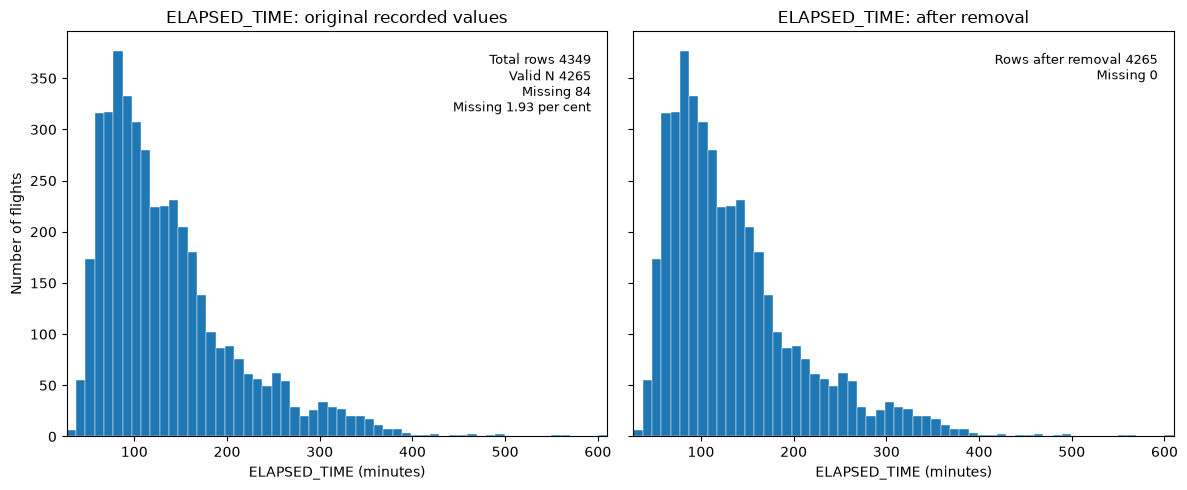

Saved figures/A2_ELAPSED_TIME_missing_comparison.png using 58 shared bins


In [78]:
save_missing_comparison_figure("ELAPSED_TIME")

`ELAPSED_TIME` has 4265 recorded values and 84 missing values, which is 1.93 per cent of the
rows. The mean of 135.39 minutes sits above the median of 116 minutes and the skewness is 1.44,
so the distribution leans to the right with a long tail towards the longest recorded flight of
610 minutes. The row-set check below confirms that the 84 missing rows are exactly the rows
where `CANCELLED` equals 1 or `DIVERTED` equals 1, so the missing durations coincide with
cancelled or diverted flight records rather than being scattered across ordinary flights.
Removal reduces the usable sample to 4265 rows and sets the missing count to zero, while every
recorded value and therefore every summary statistic stays the same.

#### AIR_TIME

`AIR_TIME` is the time in minutes spent in the air, so it excludes the taxi periods at both
ends of the journey and is shorter than `ELAPSED_TIME` for the same flight.

In [79]:
air_time_before, air_time_after = duration_before["AIR_TIME"], duration_after["AIR_TIME"]

print("Full precision values for AIR_TIME after removal:")
for name, value in air_time_after.items():
    print(f"  {name:<20} {value}")

air_time_comparison = comparison_table(air_time_before, air_time_after)
air_time_comparison.to_csv("outputs/A2_AIR_TIME_missing_comparison.csv", index=False)
air_time_comparison

Full precision values for AIR_TIME after removal:
  Total rows           4265
  Valid N              4265
  Missing              0
  Missing percentage   0.0
  Mean                 111.76459554513482
  Median               92.0
  Minimum              14.0
  Maximum              535.0
  Range                521.0
  Variance             4830.6326580504965
  Standard deviation   69.50275288109455
  Q1                   61.0
  Q3                   141.0
  IQR                  80.0
  Skewness             1.4507832341284652


,Statistic,Original column,After removal
0,Total rows,4349,4265
1,Valid N,4265,4265
2,Missing,84,0
3,Missing percentage,1.93,0
4,Mean,111.76,111.76
5,Median,92,92
6,Minimum,14,14
7,Maximum,535,535
8,Range,521,521
9,Variance,4830.63,4830.63


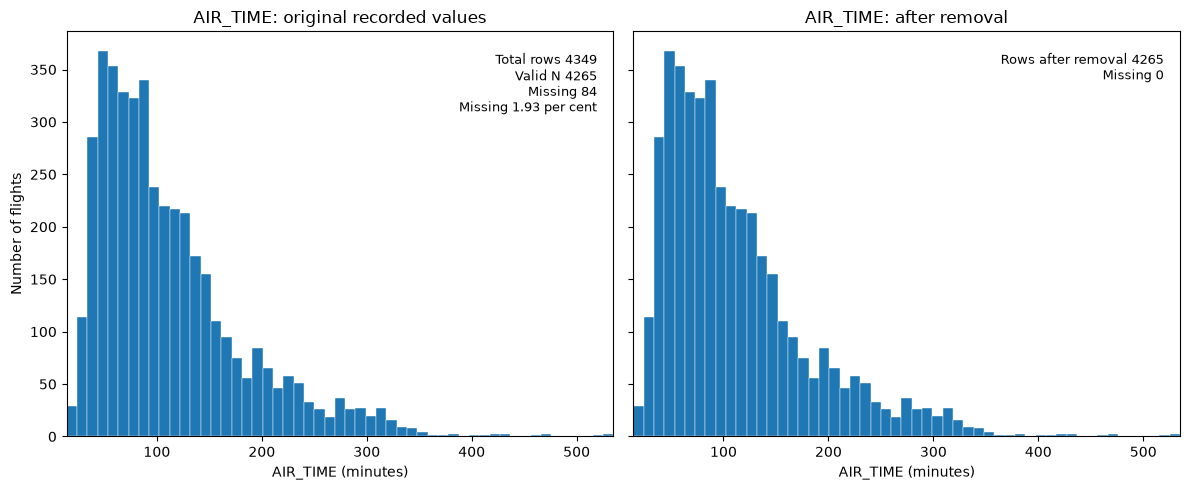

Saved figures/A2_AIR_TIME_missing_comparison.png using 53 shared bins


In [80]:
save_missing_comparison_figure("AIR_TIME")

`AIR_TIME` has 4265 recorded values and 84 missing values, which is 1.93 per cent of the rows,
the same count as `ELAPSED_TIME`. The mean of 111.76 minutes sits above the median of 92
minutes with a skewness of 1.45, giving the same right-leaning shape as the total flight
duration but shifted lower, because the recorded range runs from 14 to 535 minutes. The
exact row-set check passes here as well, so its 84 missing rows are precisely the cancelled or
diverted records. Removal takes the usable sample to 4265 rows and the missing count to zero
without altering any recorded value or any summary statistic.

#### TAXI_IN

`TAXI_IN` is the time in minutes between landing and arriving at the destination gate, so it is
the arrival counterpart of `TAXI_OUT`.

In [81]:
taxi_in_before, taxi_in_after = duration_before["TAXI_IN"], duration_after["TAXI_IN"]

print("Full precision values for TAXI_IN after removal:")
for name, value in taxi_in_after.items():
    print(f"  {name:<20} {value}")

taxi_in_comparison = comparison_table(taxi_in_before, taxi_in_after)
taxi_in_comparison.to_csv("outputs/A2_TAXI_IN_missing_comparison.csv", index=False)
taxi_in_comparison

Full precision values for TAXI_IN after removal:
  Total rows           4282
  Valid N              4282
  Missing              0
  Missing percentage   0.0
  Mean                 7.488323213451658
  Median               6.0
  Minimum              1.0
  Maximum              172.0
  Range                171.0
  Variance             43.1408353563823
  Standard deviation   6.568168341050821
  Q1                   4.0
  Q3                   8.0
  IQR                  4.0
  Skewness             9.749013138831398


,Statistic,Original column,After removal
0,Total rows,4349,4282
1,Valid N,4282,4282
2,Missing,67,0
3,Missing percentage,1.54,0
4,Mean,7.49,7.49
5,Median,6,6
6,Minimum,1,1
7,Maximum,172,172
8,Range,171,171
9,Variance,43.14,43.14


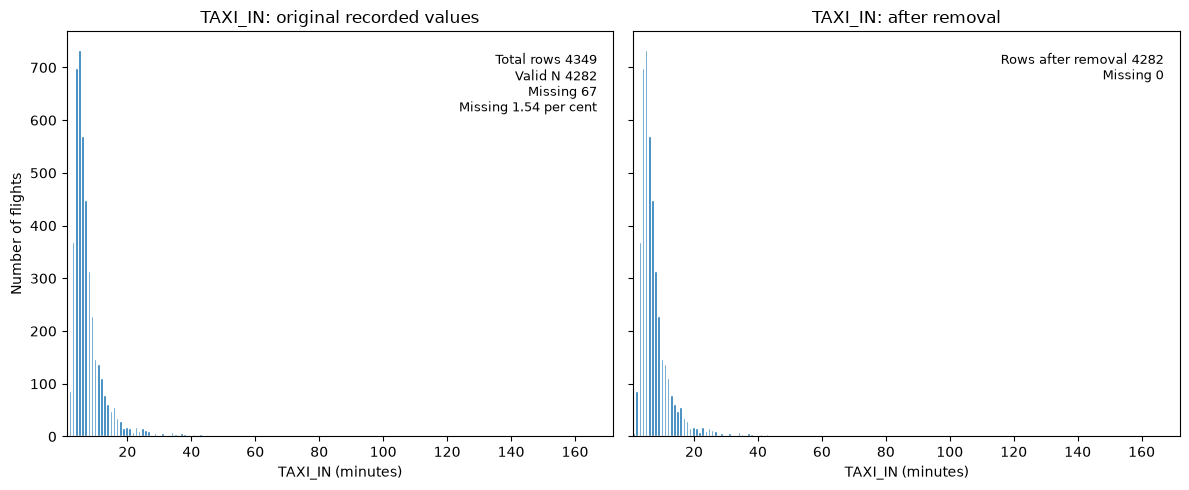

Saved figures/A2_TAXI_IN_missing_comparison.png using 348 shared bins


In [82]:
save_missing_comparison_figure("TAXI_IN")

`TAXI_IN` has 4282 recorded values and 67 missing values, which is 1.54 per cent of the rows. It
is the shortest and by far the most strongly right skewed of the four durations, with a mean of
7.49 minutes against a median of 6 minutes, a quartile range of only 4 to 8 minutes, an IQR of
4 minutes and a skewness of 9.75, while the largest recorded value reaches 172 minutes. The
computed skewness therefore supports describing the shape as strongly right skewed, with the
bulk of arrivals reaching the gate within a few minutes of landing. The largest values are
simply the extreme end of that tail and are not labelled as outliers here, because formal
outlier identification belongs to A3. Removal lowers the usable sample to 4282 rows and sets the
missing count to zero, leaving every recorded value and every summary statistic unchanged.

##### Combined summary after removal

The next table gathers the after-removal summaries for all four attributes into one
report-ready block, which makes the four durations easy to compare side by side and easy to
quote in the report. The row label `N` is the valid sample size of each cleaned Series.

In [83]:
combined_statistics = ["N", "Missing", "Mean", "Median", "Minimum", "Maximum", "Range",
                       "Variance", "Standard deviation", "Q1", "Q3", "IQR", "Skewness"]


def after_removal_value(attribute_name, statistic):
    """Read one after-removal statistic, mapping the report label N onto Valid N."""
    key = "Valid N" if statistic == "N" else statistic
    return duration_after[attribute_name][key]


duration_clean_summary = pd.DataFrame({"Statistic": combined_statistics})
for attribute in duration_attributes:
    duration_clean_summary[attribute] = [format_value(after_removal_value(attribute, statistic))
                                         for statistic in combined_statistics]

duration_clean_summary.to_csv("outputs/A2_duration_summary_after_removal.csv", index=False)
duration_clean_summary

,Statistic,TAXI_OUT,ELAPSED_TIME,AIR_TIME,TAXI_IN
0,N,4284,4265,4265,4282
1,Missing,0,0,0,0
2,Mean,16.15,135.39,111.76,7.49
3,Median,14,116,92,6
4,Minimum,1,27,14,1
5,Maximum,110,610,535,172
6,Range,109,583,521,171
7,Variance,79.76,5184.53,4830.63,43.14
8,Standard deviation,8.93,72.00,69.50,6.57
9,Q1,11,83,61,4


The overview table below records only what was counted: how many rows each attribute had, how
many values were recorded, how many were missing, the missing percentage and how many rows
remain after removal. It deliberately carries no explanation of why the values are missing,
because that belongs with the status check and the written interpretation rather than in a
counting table.

In [84]:
overview_rows = []
for attribute in duration_attributes:
    before = duration_before[attribute]
    overview_rows.append({
        "Attribute": attribute,
        "Total Rows": before["Total rows"],
        "Valid N": before["Valid N"],
        "Missing": before["Missing"],
        "Missing Percentage": round(before["Missing percentage"], 2),
        "Rows After Removal": duration_after[attribute]["Total rows"],
    })

duration_missing_overview = pd.DataFrame(overview_rows)
duration_missing_overview.to_csv("outputs/A2_duration_missing_overview.csv", index=False)
duration_missing_overview

,Attribute,Total Rows,Valid N,Missing,Missing Percentage,Rows After Removal
0,TAXI_OUT,4349,4284,65,1.49,4284
1,ELAPSED_TIME,4349,4265,84,1.93,4265
2,AIR_TIME,4349,4265,84,1.93,4265
3,TAXI_IN,4349,4282,67,1.54,4282


##### Which flights have missing durations

This check tests whether the missing durations line up with abnormal flight status. A row is
flagged when `CANCELLED` equals 1 or `DIVERTED` equals 1, and the missing rows of each attribute
are compared against that flag.

Matching totals alone would not be convincing, because two different sets of rows can share the
same size. The final column therefore compares the row sets themselves position by position, so
it only reports `True` when the missing rows are exactly the flagged rows. For the two taxi
attributes the split of cancelled, diverted and neither is reported instead, because their
missing counts differ from the flagged total.

In [85]:
duration_status_mask = (df_raw["CANCELLED"] == 1) | (df_raw["DIVERTED"] == 1)
print("Rows that are cancelled or diverted:", int(duration_status_mask.sum()))

status_rows = []
for attribute in duration_attributes:
    missing_mask = df_raw[attribute].isna()
    status_rows.append({
        "Attribute": attribute,
        "Missing": int(missing_mask.sum()),
        "Missing and cancelled": int((missing_mask & (df_raw["CANCELLED"] == 1)).sum()),
        "Missing and diverted": int((missing_mask & (df_raw["DIVERTED"] == 1)).sum()),
        "Missing and neither": int((missing_mask & ~duration_status_mask).sum()),
        "Missing rows equal cancelled or diverted rows":
            bool((missing_mask == duration_status_mask).all()),
    })

duration_status_check = pd.DataFrame(status_rows)
duration_status_check.to_csv("outputs/A2_duration_missing_status_check.csv", index=False)
duration_status_check

Rows that are cancelled or diverted: 84


,Attribute,Missing,Missing and cancelled,Missing and diverted,Missing and neither,Missing rows equal cancelled or diverted rows
0,TAXI_OUT,65,65,0,0,False
1,ELAPSED_TIME,84,66,18,0,True
2,AIR_TIME,84,66,18,0,True
3,TAXI_IN,67,66,1,0,False


##### Why removal was chosen, and why the statistics do not move

Attribute-wise removal was used because the missing proportions are small, between 1.49 and
1.93 per cent, and because the missing records are linked to abnormal flight-status records
rather than spread evenly across normal flights. Imputing a typical duration would create an
artificial value for a flight that did not complete a normal journey, for example an air time
for a flight that never departed. Removal keeps every recorded duration without inventing a
single new one. The original `df_raw` is retained unchanged and removal is applied only to a
temporary Series for each attribute.

The verified relationships differ by attribute and are described only as far as the code
confirms them. For `ELAPSED_TIME` and `AIR_TIME` the 84 missing rows are exactly the rows that
are cancelled or diverted. For `TAXI_OUT` all 65 missing rows are cancelled flights, and for
`TAXI_IN` the 67 missing rows are 66 cancelled flights and 1 diverted flight. These are row
correspondences observed in the data and not a claim that every missing value arose from an
identical operational cause.

The comparison tables show that the numeric statistics are the same before and after removal,
and that is the correct result rather than a mistake. The pandas summary methods ignore missing
values by default, so explicit removal does not change the recorded observations used in the
calculations. What does change is the usable sample size, which falls from 4349 rows to the
valid count of each attribute, and the missing count, which becomes zero in the temporary
cleaned Series. Because the set of recorded values is untouched, the mean, median, quartiles,
IQR, variance, standard deviation and skewness all stay the same and the two histogram panels
of each figure are identical.

##### Validation of the duration attributes

These checks confirm the results mechanically rather than by eye. Three of them deserve a note.

Check 12 does not compare the cleaned Series against another `dropna()` call, which would prove
nothing. It selects the recorded values with a boolean mask instead and compares both the values
and the row labels, so it confirms removal kept exactly the recorded observations in their
original order.

Check 20 reuses `is_sample_variance` from the earlier A2 validation, which rebuilds the variance
by hand as the sum of squared deviations divided by `n - 1` and confirms the reported figure
matches that while differing from the population version. This proves `ddof=1` was used rather
than trusting a default.

Checks 23 and 24 recompute the status split of the missing rows from `df_raw` and compare it
with the saved table, so the table cannot drift away from the data.

In [86]:
def recorded_values_match(attribute_name):
    """Confirm the cleaned Series holds exactly the recorded values, in the original order."""
    original = df_raw[attribute_name]
    recorded = original[original.notna()]  # selected with a mask, not with a second dropna
    clean = duration_clean[attribute_name]
    return bool(recorded.index.equals(clean.index)
                and np.array_equal(recorded.to_numpy(), clean.to_numpy()))


def status_counts_match(attribute_name):
    """Recompute the status split of the missing rows and compare it with the saved table."""
    missing_mask = df_raw[attribute_name].isna()
    cancelled = int((missing_mask & (df_raw["CANCELLED"] == 1)).sum())
    diverted = int((missing_mask & (df_raw["DIVERTED"] == 1)).sum())
    neither = int((missing_mask & ~duration_status_mask).sum())
    row = duration_status_check.set_index("Attribute").loc[attribute_name]
    return bool(cancelled == row["Missing and cancelled"]
                and diverted == row["Missing and diverted"]
                and neither == row["Missing and neither"]
                and cancelled + diverted + neither == int(missing_mask.sum()))


expected_figures_a27 = [f"figures/A2_{a}_missing_comparison.png" for a in duration_attributes]
expected_outputs_a27 = ([f"outputs/A2_{a}_missing_comparison.csv" for a in duration_attributes]
                        + ["outputs/A2_duration_summary_after_removal.csv",
                           "outputs/A2_duration_missing_overview.csv",
                           "outputs/A2_duration_missing_status_check.csv"])

fresh_duration_copy = pd.read_csv(RAW_CSV)
print("Files to check:", len(expected_figures_a27), "figures and", len(expected_outputs_a27), "tables")

Files to check: 4 figures and 7 tables


In [87]:
a27_checks = {
    "1. All four attributes exist": all(a in df_raw.columns for a in duration_attributes),
    "2. df_raw remains 4349 by 25": df_raw.shape == (4349, 25),
    "3. TAXI_OUT missing equals 65": duration_before["TAXI_OUT"]["Missing"] == 65,
    "4. ELAPSED_TIME missing equals 84": duration_before["ELAPSED_TIME"]["Missing"] == 84,
    "5. AIR_TIME missing equals 84": duration_before["AIR_TIME"]["Missing"] == 84,
    "6. TAXI_IN missing equals 67": duration_before["TAXI_IN"]["Missing"] == 67,
    "7. TAXI_OUT cleaned N equals 4284": duration_after["TAXI_OUT"]["Valid N"] == 4284,
    "8. ELAPSED_TIME cleaned N equals 4265": duration_after["ELAPSED_TIME"]["Valid N"] == 4265,
    "9. AIR_TIME cleaned N equals 4265": duration_after["AIR_TIME"]["Valid N"] == 4265,
    "10. TAXI_IN cleaned N equals 4282": duration_after["TAXI_IN"]["Valid N"] == 4282,
    "11. Every cleaned Series has zero missing values": all(
        duration_after[a]["Missing"] == 0 for a in duration_attributes),
    "12. Cleaned values equal the recorded values in the same order": all(
        recorded_values_match(a) for a in duration_attributes),
    "13. Means unchanged by removal": all(
        np.isclose(duration_before[a]["Mean"], duration_after[a]["Mean"])
        for a in duration_attributes),
    "14. Medians unchanged by removal": all(
        duration_before[a]["Median"] == duration_after[a]["Median"] for a in duration_attributes),
    "15. Variances unchanged by removal": all(
        np.isclose(duration_before[a]["Variance"], duration_after[a]["Variance"])
        for a in duration_attributes),
    "16. Standard deviations unchanged by removal": all(
        np.isclose(duration_before[a]["Standard deviation"], duration_after[a]["Standard deviation"])
        for a in duration_attributes),
    "17. Quartiles unchanged by removal": all(
        duration_before[a]["Q1"] == duration_after[a]["Q1"]
        and duration_before[a]["Q3"] == duration_after[a]["Q3"] for a in duration_attributes),
    "18. IQR values unchanged by removal": all(
        duration_before[a]["IQR"] == duration_after[a]["IQR"] for a in duration_attributes),
    "19. Skewness values unchanged by removal": all(
        np.isclose(duration_before[a]["Skewness"], duration_after[a]["Skewness"])
        for a in duration_attributes),
    "20. Variance uses ddof=1 for all four attributes": all(
        is_sample_variance(a, duration_after[a]["Variance"]) for a in duration_attributes),
    "21. ELAPSED_TIME missing rows equal the cancelled or diverted rows": bool(
        (df_raw["ELAPSED_TIME"].isna() == duration_status_mask).all()),
    "22. AIR_TIME missing rows equal the cancelled or diverted rows": bool(
        (df_raw["AIR_TIME"].isna() == duration_status_mask).all()),
    "23. TAXI_OUT missing status counts match the recomputed data": status_counts_match("TAXI_OUT"),
    "24. TAXI_IN missing status counts match the recomputed data": status_counts_match("TAXI_IN"),
    "25. All four comparison figures exist": all(
        os.path.exists(p) for p in expected_figures_a27),
    "26. All expected output CSV files exist": all(
        os.path.exists(p) for p in expected_outputs_a27),
    "27. df_raw still matches the file on disk": df_raw.equals(fresh_duration_copy),
}

validation_a27 = pd.DataFrame({"Check": list(a27_checks.keys()),
                               "Result": ["PASS" if v else "FAIL" for v in a27_checks.values()]})
print("Checks passed:", sum(a27_checks.values()), "of", len(a27_checks))
validation_a27

Checks passed: 27 of 27


,Check,Result
0,1. All four attributes exist,PASS
1,2. df_raw remains 4349 by 25,PASS
2,3. TAXI_OUT missing equals 65,PASS
3,4. ELAPSED_TIME missing equals 84,PASS
4,5. AIR_TIME missing equals 84,PASS
5,6. TAXI_IN missing equals 67,PASS
6,7. TAXI_OUT cleaned N equals 4284,PASS
7,8. ELAPSED_TIME cleaned N equals 4265,PASS
8,9. AIR_TIME cleaned N equals 4265,PASS
9,10. TAXI_IN cleaned N equals 4282,PASS


All duration checks pass. The four attributes are summarised with the full set of quantitative
statistics using sample variance and sample standard deviation, the recomputed missing counts of
65, 84, 84 and 67 agree with the P0 audit, and the missing rows of `ELAPSED_TIME` and `AIR_TIME`
are confirmed to be exactly the cancelled or diverted rows. Removal was applied only to
temporary Series, so `df_raw` is still identical to the file on disk at 4349 rows and 25 columns.
The remaining A2 attributes are covered in later sections.

### A2.8 Delay Attributes

This group covers five delay attributes.

`DEPARTURE_DELAY` and `ARRIVAL_DELAY` are signed offsets from the scheduled times. Negative
values mean the flight left or arrived early, zero means it was on time, and positive values
mean it was late. Both were classified as interval attributes in A1, and the negative values
are valid observations rather than data errors.

`AIR_SYSTEM_DELAY`, `SECURITY_DELAY` and `WEATHER_DELAY` are delay-cause durations in minutes.
They were classified as ratio attributes in A1. A recorded zero is a genuine observation of
zero delay of that type. A blank cell is missing and must never be treated as zero.

All five attributes contain missing values. The approved treatment for this group is
attribute-wise removal: for each attribute a temporary Series is built with `dropna()`, and
the statistics are recomputed from that temporary Series. `df_raw` is never modified, no row
is deleted from it, no value is imputed and no blank is turned into a zero. The raw frame
stays at 4349 rows and 25 columns.

Every attribute is summarised twice, once for the original column while its missing values
are still present and once after removal, so the effect of the treatment can be read from the
tables and the figures.

The first cell is a checkpoint. It confirms the five attributes exist and recomputes their
missing counts and percentages from `df_raw`, so any disagreement with the P0 audit would be
visible before the summaries are calculated.

In [88]:
delay_attributes = ["DEPARTURE_DELAY", "ARRIVAL_DELAY",
                    "AIR_SYSTEM_DELAY", "SECURITY_DELAY", "WEATHER_DELAY"]
signed_delay_attributes = ["DEPARTURE_DELAY", "ARRIVAL_DELAY"]
cause_delay_attributes = ["AIR_SYSTEM_DELAY", "SECURITY_DELAY", "WEATHER_DELAY"]

print("Raw data shape:", df_raw.shape)
for attribute in delay_attributes:
    column = df_raw[attribute]
    missing = int(column.isna().sum())
    print(f"{attribute:<18} present={attribute in df_raw.columns}  "
          f"valid={int(column.notna().sum())}  missing={missing}  "
          f"({missing / len(df_raw) * 100:.2f} per cent)")

print()
print("All five present:", all(a in df_raw.columns for a in delay_attributes))
print("Shape is 4349 by 25:", df_raw.shape == (4349, 25))

Raw data shape: (4349, 25)
DEPARTURE_DELAY    present=True  valid=4288  missing=61  (1.40 per cent)
ARRIVAL_DELAY      present=True  valid=4265  missing=84  (1.93 per cent)
AIR_SYSTEM_DELAY   present=True  valid=827  missing=3522  (80.98 per cent)
SECURITY_DELAY     present=True  valid=827  missing=3522  (80.98 per cent)
WEATHER_DELAY      present=True  valid=827  missing=3522  (80.98 per cent)

All five present: True
Shape is 4349 by 25: True


`describe_numeric_series` calculates every statistic this group needs from a single Series. It
takes a Series rather than an attribute name so that the same code can describe the original
column and the temporary cleaned Series. The helper is written for any numeric Series and does
not assume the attribute is a ratio measure, which matters because `DEPARTURE_DELAY` and
`ARRIVAL_DELAY` are interval attributes.

`ddof=1` is written out in full for the variance and the standard deviation, so the sample
formulas that divide by `n - 1` are explicit.

As in the duration group, the pandas methods used here skip missing values by default. The
statistics of the original column are therefore already based only on its recorded values.

In [89]:
def describe_numeric_series(series):
    """Return the full set of numeric summary statistics for one Series."""
    total_rows = len(series)
    missing = int(series.isna().sum())

    return {
        "Total rows": total_rows,
        "Valid N": int(series.notna().sum()),
        "Missing": missing,
        "Missing percentage": missing / total_rows * 100,
        "Mean": series.mean(),
        "Median": series.median(),
        "Minimum": series.min(),
        "Maximum": series.max(),
        "Range": series.max() - series.min(),
        "Variance": series.var(ddof=1),            # sample variance, divides by n - 1
        "Standard deviation": series.std(ddof=1),  # sample standard deviation
        "Q1": series.quantile(0.25),
        "Q3": series.quantile(0.75),
        "IQR": series.quantile(0.75) - series.quantile(0.25),
        "Skewness": series.skew(),
    }


def delay_missing_comparison(attribute_name):
    """Describe one delay attribute before and after attribute-wise removal."""
    original = df_raw[attribute_name]
    clean = original.dropna()  # temporary Series only, df_raw is never changed
    return describe_numeric_series(original), describe_numeric_series(clean)


delay_before, delay_after, delay_clean = {}, {}, {}
for attribute in delay_attributes:
    delay_before[attribute], delay_after[attribute] = delay_missing_comparison(attribute)
    delay_clean[attribute] = df_raw[attribute].dropna()

print("Described attributes:", list(delay_before))

Described attributes: ['DEPARTURE_DELAY', 'ARRIVAL_DELAY', 'AIR_SYSTEM_DELAY', 'SECURITY_DELAY', 'WEATHER_DELAY']


Each attribute gets one two-panel figure. The bin edges come from `np.histogram_bin_edges`
using the `"auto"` rule, so the bin width follows from the data rather than from a count chosen
by hand. The same edges and the same x-axis limits are applied to both panels.

A missing value has no numeric position, so it cannot be drawn as a bar. The left panel
therefore plots the recorded values of the original column and reports the missing count in an
annotation. Nothing is converted to zero to force missing values onto the axis, which is
especially important for the three delay-cause attributes where recorded zeros and blank cells
mean different things.

This binning exists only to draw these distributions. It is not the B1 preprocessing task, no
smoothing is applied and no valid delay value is removed to improve the appearance of the chart.

In [90]:
def save_delay_comparison_figure(attribute_name):
    """Draw the recorded values before and after removal using one shared set of bin edges."""
    original = df_raw[attribute_name]
    clean = delay_clean[attribute_name]
    bin_edges = np.histogram_bin_edges(clean, bins="auto")
    before, after = delay_before[attribute_name], delay_after[attribute_name]

    notes = [f"Total rows {before['Total rows']}\nValid N {before['Valid N']}\n"
             f"Missing {before['Missing']}\n"
             f"Missing {before['Missing percentage']:.2f} per cent",
             f"Rows after removal {after['Total rows']}\nMissing 0"]
    panel_titles = [f"{attribute_name}: original recorded values",
                    f"{attribute_name}: after removal"]

    figure, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
    for panel, values, title, note in zip(axes, [original.dropna(), clean], panel_titles, notes):
        # A thin edge line keeps the bars visible when the rule returns many narrow bins.
        panel.hist(values, bins=bin_edges, edgecolor="white", linewidth=0.3)
        panel.set_xlim(bin_edges[0], bin_edges[-1])
        panel.set_title(title)
        panel.set_xlabel(f"{attribute_name} (minutes)")
        panel.annotate(note, xy=(0.97, 0.95), xycoords="axes fraction",
                       ha="right", va="top", fontsize=9)

    axes[0].set_ylabel("Number of flights")
    figure.tight_layout()
    figure_path = f"figures/A2_{attribute_name}_missing_comparison.png"
    figure.savefig(figure_path, dpi=200)
    plt.show()
    print("Saved", figure_path, "using", len(bin_edges) - 1, "shared bins")

#### DEPARTURE_DELAY

`DEPARTURE_DELAY` is the departure delay in minutes relative to the scheduled departure time.
Negative values mean the flight left early. The comparison table is printed at full precision
first, so the exact values stay visible next to the rounded report table.

In [91]:
departure_before = delay_before["DEPARTURE_DELAY"]
departure_after = delay_after["DEPARTURE_DELAY"]

print("Full precision values for DEPARTURE_DELAY after removal:")
for name, value in departure_after.items():
    print(f"  {name:<20} {value}")

departure_comparison = comparison_table(departure_before, departure_after)
departure_comparison.to_csv("outputs/A2_DEPARTURE_DELAY_missing_comparison.csv", index=False)
departure_comparison

Full precision values for DEPARTURE_DELAY after removal:
  Total rows           4288
  Valid N              4288
  Missing              0
  Missing percentage   0.0
  Mean                 10.810401119402986
  Median               -1.0
  Minimum              -36.0
  Maximum              836.0
  Range                872.0
  Variance             1537.2892129951188
  Standard deviation   39.20827990354995
  Q1                   -4.0
  Q3                   9.0
  IQR                  13.0
  Skewness             7.201213260853006


,Statistic,Original column,After removal
0,Total rows,4349,4288
1,Valid N,4288,4288
2,Missing,61,0
3,Missing percentage,1.40,0
4,Mean,10.81,10.81
5,Median,-1,-1
6,Minimum,-36,-36
7,Maximum,836,836
8,Range,872,872
9,Variance,1537.29,1537.29


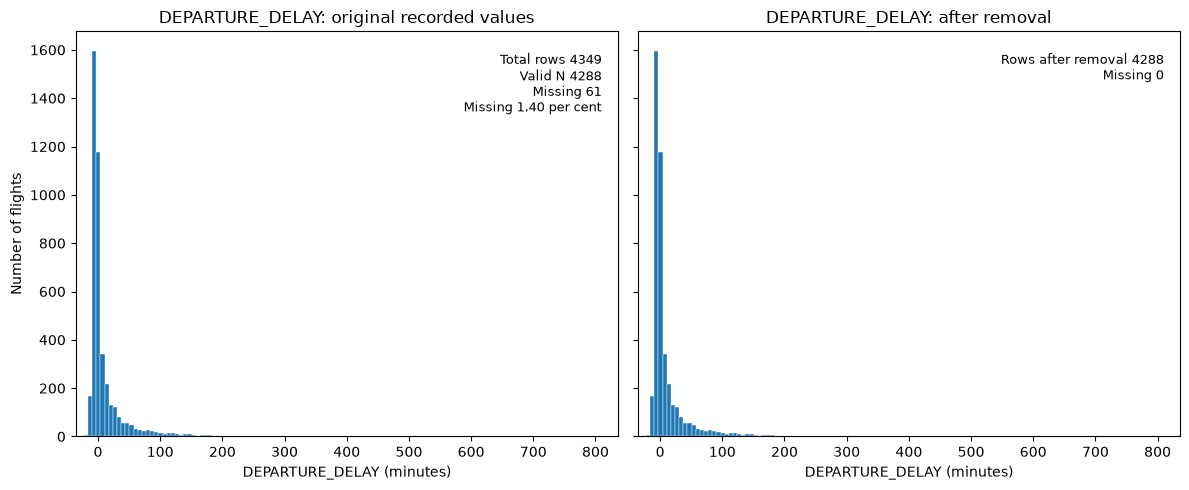

Saved figures/A2_DEPARTURE_DELAY_missing_comparison.png using 131 shared bins


In [92]:
save_delay_comparison_figure("DEPARTURE_DELAY")

`DEPARTURE_DELAY` has 4288 recorded values and 61 missing values, which is 1.40 per cent of the
4349 rows. The mean of 10.81 minutes sits well above the median of −1 minute, and the skewness
of 7.20 shows a strong right-leaning shape: many flights leave early or nearly on time, while a
long positive tail reaches the largest recorded delay of 836 minutes. The 2388 negative values
are early departures and are kept as valid observations. All 61 missing rows are cancelled
flights, but five cancelled flights still have a recorded departure delay, so the missing rows
are not the complete cancelled set. Removal lowers the usable sample from 4349 to 4288 and sets
the missing count to zero, while every recorded value and every summary statistic stays the same.

#### ARRIVAL_DELAY

`ARRIVAL_DELAY` is the arrival delay in minutes relative to the scheduled arrival time.
Negative values mean the flight arrived early.

In [93]:
arrival_before = delay_before["ARRIVAL_DELAY"]
arrival_after = delay_after["ARRIVAL_DELAY"]

print("Full precision values for ARRIVAL_DELAY after removal:")
for name, value in arrival_after.items():
    print(f"  {name:<20} {value}")

arrival_comparison = comparison_table(arrival_before, arrival_after)
arrival_comparison.to_csv("outputs/A2_ARRIVAL_DELAY_missing_comparison.csv", index=False)
arrival_comparison

Full precision values for ARRIVAL_DELAY after removal:
  Total rows           4265
  Valid N              4265
  Missing              0
  Missing percentage   0.0
  Mean                 5.410550996483001
  Median               -5.0
  Minimum              -61.0
  Maximum              865.0
  Range                926.0
  Variance             1730.5220743914535
  Standard deviation   41.59954416086135
  Q1                   -13.0
  Q3                   8.0
  IQR                  21.0
  Skewness             6.435520688525145


,Statistic,Original column,After removal
0,Total rows,4349,4265
1,Valid N,4265,4265
2,Missing,84,0
3,Missing percentage,1.93,0
4,Mean,5.41,5.41
5,Median,-5,-5
6,Minimum,-61,-61
7,Maximum,865,865
8,Range,926,926
9,Variance,1730.52,1730.52


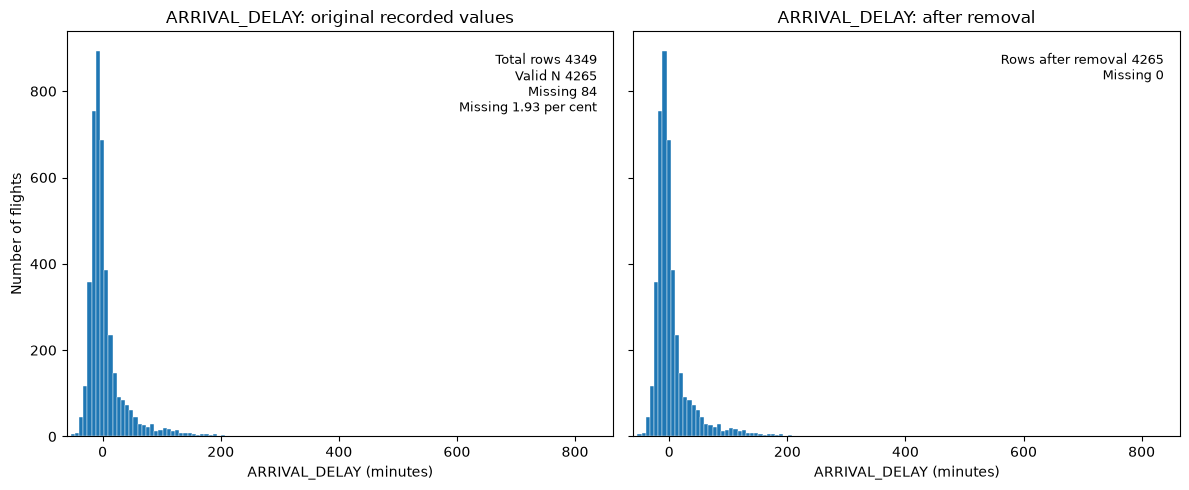

Saved figures/A2_ARRIVAL_DELAY_missing_comparison.png using 131 shared bins


In [94]:
save_delay_comparison_figure("ARRIVAL_DELAY")

`ARRIVAL_DELAY` has 4265 recorded values and 84 missing values, which is 1.93 per cent of the
rows. The mean of 5.41 minutes sits above the median of −5 minutes and the skewness of 6.44
shows a strong right-leaning shape, with 2633 recorded early arrivals and a long positive tail
to the largest recorded delay of 865 minutes. The exact row-set check below confirms that the
84 missing rows are precisely the cancelled or diverted records. Removal reduces the usable
sample to 4265 rows and sets the missing count to zero without changing any recorded value or
summary statistic. No Small, Medium or Long Delay categories are created here, because that
discretisation belongs to B3.

#### AIR_SYSTEM_DELAY

`AIR_SYSTEM_DELAY` is the delay in minutes attributed to the air system. Only flights with a
recorded delay-cause value appear in this column. A recorded zero means no air-system delay was
attributed to that flight. A blank cell is missing and is not treated as zero.

In [95]:
air_system_before = delay_before["AIR_SYSTEM_DELAY"]
air_system_after = delay_after["AIR_SYSTEM_DELAY"]

print("Full precision values for AIR_SYSTEM_DELAY after removal:")
for name, value in air_system_after.items():
    print(f"  {name:<20} {value}")

print()
print("Recorded zeros:", int((delay_clean["AIR_SYSTEM_DELAY"] == 0).sum()))
print("Recorded positive values:", int((delay_clean["AIR_SYSTEM_DELAY"] > 0).sum()))

air_system_comparison = comparison_table(air_system_before, air_system_after)
air_system_comparison.to_csv("outputs/A2_AIR_SYSTEM_DELAY_missing_comparison.csv", index=False)
air_system_comparison

Full precision values for AIR_SYSTEM_DELAY after removal:
  Total rows           827
  Valid N              827
  Missing              0
  Missing percentage   0.0
  Mean                 12.638452237001209
  Median               0.0
  Minimum              0.0
  Maximum              432.0
  Range                432.0
  Variance             882.5943065603673
  Standard deviation   29.708488796308156
  Q1                   0.0
  Q3                   17.0
  IQR                  17.0
  Skewness             6.66979184184857

Recorded zeros: 432
Recorded positive values: 395


,Statistic,Original column,After removal
0,Total rows,4349,827
1,Valid N,827,827
2,Missing,3522,0
3,Missing percentage,80.98,0
4,Mean,12.64,12.64
5,Median,0,0
6,Minimum,0,0
7,Maximum,432,432
8,Range,432,432
9,Variance,882.59,882.59


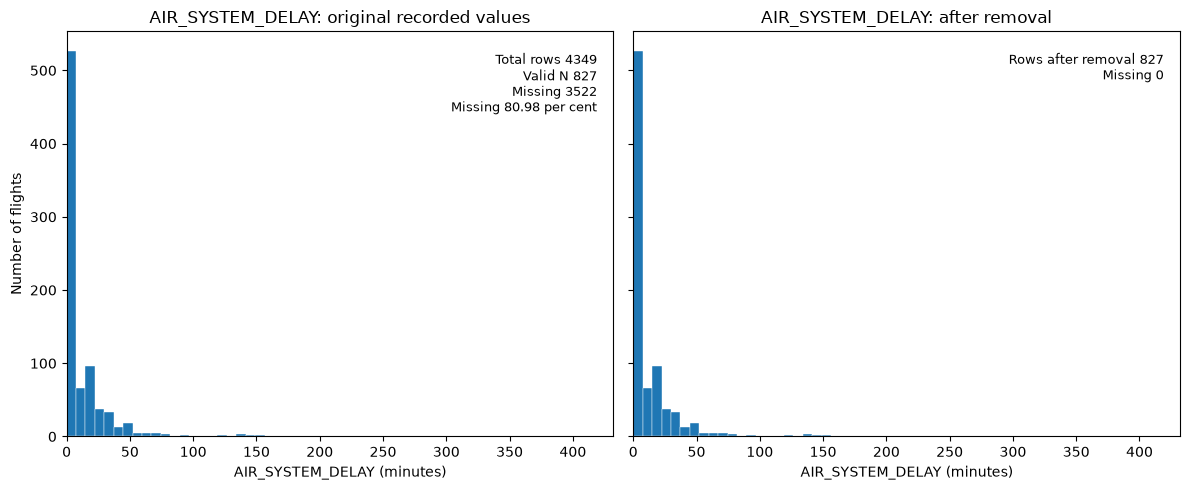

Saved figures/A2_AIR_SYSTEM_DELAY_missing_comparison.png using 58 shared bins


In [96]:
save_delay_comparison_figure("AIR_SYSTEM_DELAY")

`AIR_SYSTEM_DELAY` has only 827 recorded values and 3522 missing values, which is 80.98 per cent
of the rows. The exact eligibility check below confirms that those 827 recorded rows are
precisely the flights with `ARRIVAL_DELAY` of 15 minutes or more, so the summary describes that
eligible subset and not the whole dataset of 4349 flights. Among the recorded cases the
distribution is zero-heavy and right skewed: 432 recorded zeros, a median of 0, a mean of 12.64
minutes and a skewness of 6.67, with a thin tail to 432 minutes. Removal lowers the usable
sample to 827 rows and sets the missing count to zero, while the recorded values and their
summary statistics remain unchanged.

#### SECURITY_DELAY

`SECURITY_DELAY` is the delay in minutes attributed to security. As with the other cause
columns, a recorded zero is an observed value and a blank cell is missing.

In [97]:
security_before = delay_before["SECURITY_DELAY"]
security_after = delay_after["SECURITY_DELAY"]

print("Full precision values for SECURITY_DELAY after removal:")
for name, value in security_after.items():
    print(f"  {name:<20} {value}")

print()
print("Recorded zeros:", int((delay_clean["SECURITY_DELAY"] == 0).sum()))
print("Recorded positive values:", int((delay_clean["SECURITY_DELAY"] > 0).sum()))

security_comparison = comparison_table(security_before, security_after)
security_comparison.to_csv("outputs/A2_SECURITY_DELAY_missing_comparison.csv", index=False)
security_comparison

Full precision values for SECURITY_DELAY after removal:
  Total rows           827
  Valid N              827
  Missing              0
  Missing percentage   0.0
  Mean                 0.07134220072551391
  Median               0.0
  Minimum              0.0
  Maximum              32.0
  Range                32.0
  Variance             1.6668169614493884
  Standard deviation   1.2910526563426405
  Q1                   0.0
  Q3                   0.0
  IQR                  0.0
  Skewness             21.187571787762142

Recorded zeros: 823
Recorded positive values: 4


,Statistic,Original column,After removal
0,Total rows,4349,827
1,Valid N,827,827
2,Missing,3522,0
3,Missing percentage,80.98,0
4,Mean,0.07,0.07
5,Median,0,0
6,Minimum,0,0
7,Maximum,32,32
8,Range,32,32
9,Variance,1.67,1.67


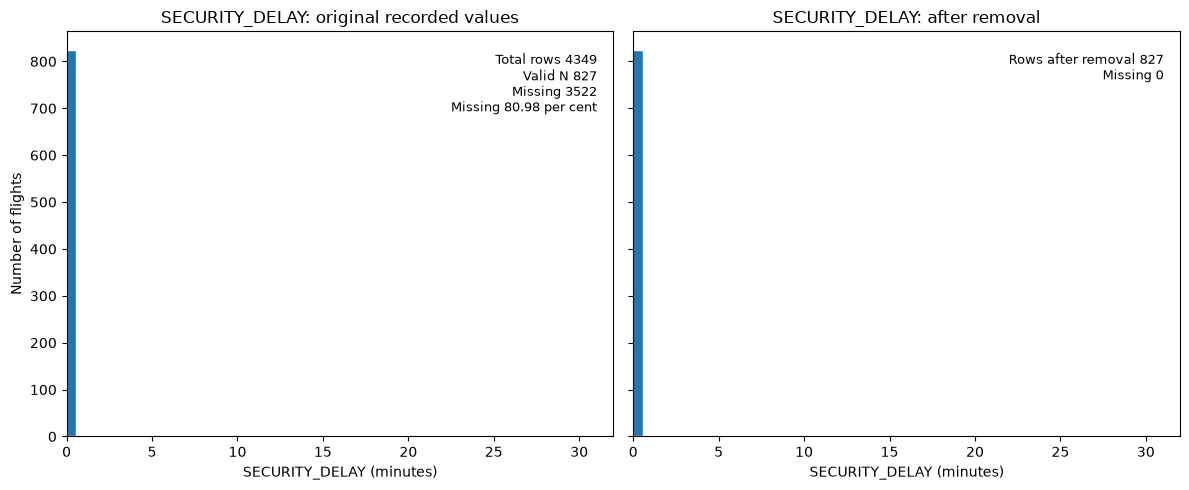

Saved figures/A2_SECURITY_DELAY_missing_comparison.png using 58 shared bins


In [98]:
save_delay_comparison_figure("SECURITY_DELAY")

`SECURITY_DELAY` also has 827 recorded values and 3522 missing values (80.98 per cent), and its
recorded rows are exactly the flights with `ARRIVAL_DELAY` of 15 minutes or more. Security delay
is almost entirely zero among those recorded cases: 823 recorded zeros, only 4 positive values,
a mean of 0.07 minutes, a median of 0, an IQR of 0 and a skewness of 21.19. The summary therefore
applies only to the 827 eligible flights and must not be read as if it described every flight in
the dataset. Removal takes the usable sample to 827 rows and the missing count to zero without
changing the recorded-value distribution.

#### WEATHER_DELAY

`WEATHER_DELAY` is the delay in minutes attributed to weather. Recorded zeros and blank cells
are kept as distinct states.

In [99]:
weather_before = delay_before["WEATHER_DELAY"]
weather_after = delay_after["WEATHER_DELAY"]

print("Full precision values for WEATHER_DELAY after removal:")
for name, value in weather_after.items():
    print(f"  {name:<20} {value}")

print()
print("Recorded zeros:", int((delay_clean["WEATHER_DELAY"] == 0).sum()))
print("Recorded positive values:", int((delay_clean["WEATHER_DELAY"] > 0).sum()))

weather_comparison = comparison_table(weather_before, weather_after)
weather_comparison.to_csv("outputs/A2_WEATHER_DELAY_missing_comparison.csv", index=False)
weather_comparison

Full precision values for WEATHER_DELAY after removal:
  Total rows           827
  Valid N              827
  Missing              0
  Missing percentage   0.0
  Mean                 3.2769044740024182
  Median               0.0
  Minimum              0.0
  Maximum              417.0
  Range                417.0
  Variance             455.03582188311555
  Standard deviation   21.331568669066876
  Q1                   0.0
  Q3                   0.0
  IQR                  0.0
  Skewness             12.22721917103971

Recorded zeros: 777
Recorded positive values: 50


,Statistic,Original column,After removal
0,Total rows,4349,827
1,Valid N,827,827
2,Missing,3522,0
3,Missing percentage,80.98,0
4,Mean,3.28,3.28
5,Median,0,0
6,Minimum,0,0
7,Maximum,417,417
8,Range,417,417
9,Variance,455.04,455.04


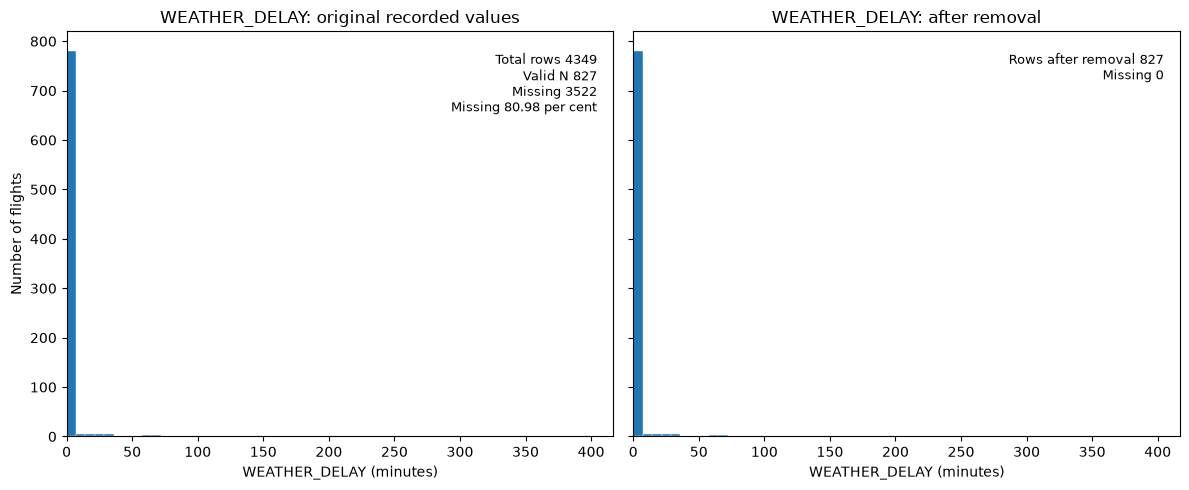

Saved figures/A2_WEATHER_DELAY_missing_comparison.png using 58 shared bins


In [100]:
save_delay_comparison_figure("WEATHER_DELAY")

`WEATHER_DELAY` likewise has 827 recorded values and 3522 missing values (80.98 per cent),
exactly matching the flights with `ARRIVAL_DELAY` of 15 minutes or more. Among those recorded
cases the distribution is zero-heavy and strongly right skewed: 777 recorded zeros, 50 positive
values, a mean of 3.28 minutes, a median of 0, an IQR of 0 and a skewness of 12.23, with a thin
tail to 417 minutes. The summary describes only the 827 eligible flights. Removal lowers the
usable sample to 827 rows and sets the missing count to zero, leaving every recorded value and
every summary statistic unchanged.

##### Combined summary after removal

The next table gathers the after-removal summaries for all five delay attributes into one
report-ready block. For the three delay-cause columns, `N` is 827 and the statistics describe
only those recorded cases.

In [101]:
delay_combined_statistics = ["N", "Missing", "Mean", "Median", "Minimum", "Maximum", "Range",
                             "Variance", "Standard deviation", "Q1", "Q3", "IQR", "Skewness"]


def delay_after_value(attribute_name, statistic):
    """Read one after-removal statistic, mapping the report label N onto Valid N."""
    key = "Valid N" if statistic == "N" else statistic
    return delay_after[attribute_name][key]


delay_clean_summary = pd.DataFrame({"Statistic": delay_combined_statistics})
for attribute in delay_attributes:
    delay_clean_summary[attribute] = [
        format_value(delay_after_value(attribute, statistic))
        for statistic in delay_combined_statistics
    ]

delay_clean_summary.to_csv("outputs/A2_delay_summary_after_removal.csv", index=False)
delay_clean_summary

,Statistic,DEPARTURE_DELAY,ARRIVAL_DELAY,AIR_SYSTEM_DELAY,SECURITY_DELAY,WEATHER_DELAY
0,N,4288,4265,827,827,827
1,Missing,0,0,0,0,0
2,Mean,10.81,5.41,12.64,0.07,3.28
3,Median,-1,-5,0,0,0
4,Minimum,-36,-61,0,0,0
5,Maximum,836,865,432,32,417
6,Range,872,926,432,32,417
7,Variance,1537.29,1730.52,882.59,1.67,455.04
8,Standard deviation,39.21,41.60,29.71,1.29,21.33
9,Q1,-4,-13,0,0,0


The overview table below records only the counts: how many rows each attribute had, how many
values were recorded, how many were missing, the missing percentage and how many rows remain
after removal.

In [102]:
delay_overview_rows = []
for attribute in delay_attributes:
    before = delay_before[attribute]
    delay_overview_rows.append({
        "Attribute": attribute,
        "Total Rows": before["Total rows"],
        "Valid N": before["Valid N"],
        "Missing": before["Missing"],
        "Missing Percentage": round(before["Missing percentage"], 2),
        "Rows After Removal": delay_after[attribute]["Total rows"],
    })

delay_missing_overview = pd.DataFrame(delay_overview_rows)
delay_missing_overview.to_csv("outputs/A2_delay_missing_overview.csv", index=False)
delay_missing_overview

,Attribute,Total Rows,Valid N,Missing,Missing Percentage,Rows After Removal
0,DEPARTURE_DELAY,4349,4288,61,1.40,4288
1,ARRIVAL_DELAY,4349,4265,84,1.93,4265
2,AIR_SYSTEM_DELAY,4349,827,3522,80.98,827
3,SECURITY_DELAY,4349,827,3522,80.98,827
4,WEATHER_DELAY,4349,827,3522,80.98,827


##### Signed delay counts

For the two signed delay attributes, the recorded values are split into early (negative), on
time (zero) and late (positive). Negative values indicate early departure or arrival and are
not treated as errors.

In [103]:
signed_rows = []
for attribute in signed_delay_attributes:
    clean = delay_clean[attribute]
    negative = int((clean < 0).sum())
    zero = int((clean == 0).sum())
    positive = int((clean > 0).sum())
    signed_rows.append({
        "Attribute": attribute,
        "Negative": negative,
        "Zero": zero,
        "Positive": positive,
        "Valid N": int(clean.notna().sum()),
    })

signed_delay_counts = pd.DataFrame(signed_rows)
signed_delay_counts.to_csv("outputs/A2_signed_delay_counts.csv", index=False)
print("Each signed split sums to Valid N:",
      bool(((signed_delay_counts["Negative"]
             + signed_delay_counts["Zero"]
             + signed_delay_counts["Positive"])
            == signed_delay_counts["Valid N"]).all()))
signed_delay_counts

Each signed split sums to Valid N: True


,Attribute,Negative,Zero,Positive,Valid N
0,DEPARTURE_DELAY,2388,254,1646,4288
1,ARRIVAL_DELAY,2633,81,1551,4265


##### Which flights have missing signed delays

This check tests how the missing signed delays line up with flight status. Matching totals alone
would not be enough, so exact row sets are compared where that is the right question.

For `DEPARTURE_DELAY` the question is whether every missing row is cancelled, not whether the
missing rows equal the complete cancelled set. For `ARRIVAL_DELAY` the missing rows are compared
directly with the cancelled-or-diverted mask.

In [104]:
delay_status_mask = (df_raw["CANCELLED"] == 1) | (df_raw["DIVERTED"] == 1)
departure_missing = df_raw["DEPARTURE_DELAY"].isna()
arrival_missing = df_raw["ARRIVAL_DELAY"].isna()

delay_status_check = pd.DataFrame([
    {
        "Attribute": "DEPARTURE_DELAY",
        "Missing": int(departure_missing.sum()),
        "Missing and cancelled": int((departure_missing & (df_raw["CANCELLED"] == 1)).sum()),
        "Missing and diverted": int((departure_missing & (df_raw["DIVERTED"] == 1)).sum()),
        "Missing and neither": int((departure_missing & ~delay_status_mask).sum()),
        "Cancelled with recorded value": int(
            ((df_raw["CANCELLED"] == 1) & df_raw["DEPARTURE_DELAY"].notna()).sum()),
        "All missing rows are cancelled": bool(
            (departure_missing & (df_raw["CANCELLED"] == 1)).sum() == departure_missing.sum()),
        "Missing rows equal all cancelled rows": bool(
            (departure_missing == (df_raw["CANCELLED"] == 1)).all()),
        "Missing rows equal cancelled or diverted rows": bool(
            (departure_missing == delay_status_mask).all()),
    },
    {
        "Attribute": "ARRIVAL_DELAY",
        "Missing": int(arrival_missing.sum()),
        "Missing and cancelled": int((arrival_missing & (df_raw["CANCELLED"] == 1)).sum()),
        "Missing and diverted": int((arrival_missing & (df_raw["DIVERTED"] == 1)).sum()),
        "Missing and neither": int((arrival_missing & ~delay_status_mask).sum()),
        "Cancelled with recorded value": int(
            ((df_raw["CANCELLED"] == 1) & df_raw["ARRIVAL_DELAY"].notna()).sum()),
        "All missing rows are cancelled": bool(
            (arrival_missing & (df_raw["CANCELLED"] == 1)).sum() == arrival_missing.sum()),
        "Missing rows equal all cancelled rows": bool(
            (arrival_missing == (df_raw["CANCELLED"] == 1)).all()),
        "Missing rows equal cancelled or diverted rows": bool(
            (arrival_missing == delay_status_mask).all()),
    },
])

delay_status_check.to_csv("outputs/A2_delay_status_check.csv", index=False)
delay_status_check

,Attribute,Missing,Missing and cancelled,Missing and diverted,Missing and neither,Cancelled with recorded value,All missing rows are cancelled,Missing rows equal all cancelled rows,Missing rows equal cancelled or diverted rows
0,DEPARTURE_DELAY,61,61,0,0,5,True,False,False
1,ARRIVAL_DELAY,84,66,18,0,0,False,False,True


##### Delay-cause eligibility and recorded zeros

The three delay-cause columns only contain recorded values for a structurally defined subset of
flights. The check below verifies three facts by exact Boolean comparison rather than by counting
alone:

1. the three columns share the same missing-value mask
2. each recorded-row mask equals `ARRIVAL_DELAY >= 15` row by row
3. recorded zeros are genuine numeric zeros and are counted separately from the missing blanks

A recorded zero is an observed delay-cause duration of zero, whereas a blank cell is missing.
The two states are kept distinct.

In [105]:
arrival_delay_ge_15 = df_raw["ARRIVAL_DELAY"].ge(15)
cause_missing_masks_identical = all(
    df_raw[attribute].isna().equals(df_raw["AIR_SYSTEM_DELAY"].isna())
    for attribute in cause_delay_attributes
)

cause_rows = []
for attribute in cause_delay_attributes:
    clean = delay_clean[attribute]
    cause_rows.append({
        "Attribute": attribute,
        "Recorded N": int(clean.notna().sum()),
        "Missing": int(df_raw[attribute].isna().sum()),
        "Missing Percentage": round(df_raw[attribute].isna().mean() * 100, 2),
        "Recorded Zero": int((clean == 0).sum()),
        "Recorded Positive": int((clean > 0).sum()),
        "Recorded Rows Equal ARRIVAL_DELAY >= 15": bool(
            (df_raw[attribute].notna() == arrival_delay_ge_15).all()),
    })

delay_cause_eligibility = pd.DataFrame(cause_rows)
delay_cause_eligibility.to_csv("outputs/A2_delay_cause_eligibility_check.csv", index=False)

print("Identical missing masks across the three cause columns:",
      cause_missing_masks_identical)
print("ARRIVAL_DELAY >= 15 count:", int(arrival_delay_ge_15.sum()))
delay_cause_eligibility

Identical missing masks across the three cause columns: True
ARRIVAL_DELAY >= 15 count: 827


,Attribute,Recorded N,Missing,Missing Percentage,Recorded Zero,Recorded Positive,Recorded Rows Equal ARRIVAL_DELAY >= 15
0,AIR_SYSTEM_DELAY,827,3522,80.98,432,395,True
1,SECURITY_DELAY,827,3522,80.98,823,4,True
2,WEATHER_DELAY,827,3522,80.98,777,50,True


##### Why removal was chosen, and why the statistics do not move

Attribute-wise removal was used because the teaching team permits removal or imputation and
because removal preserves every observed delay value without inventing new ones.
`DEPARTURE_DELAY` and `ARRIVAL_DELAY` have relatively few missing values that are linked to
flight status. The three delay-cause columns are different: more than 80 per cent of their cells
are blank, and only 827 cases are recorded. Replacing more than 80 per cent of those columns
with an imputed value would create a very large number of artificial observations. Median
imputation would be especially misleading for `SECURITY_DELAY` and `WEATHER_DELAY`, because their
recorded medians are zero and would therefore turn thousands of blanks into zeros. Blanks must
remain distinct from genuine recorded zeros, and `df_raw` remains unchanged.

Removal does not make the 827 delay-cause observations representative of all 4349 flights. Those
827 cases are exactly the flights with `ARRIVAL_DELAY` of 15 minutes or more, and the summaries
are interpreted within that scope.

The comparison tables show that the numeric statistics are the same before and after removal,
and that is the correct result. The pandas summary methods ignore missing values by default, so
explicit removal does not change the recorded observations used in the calculations. What does
change is the usable sample size, which falls from 4349 rows to the valid count of each
attribute, and the missing count, which becomes zero in the temporary cleaned Series. Because
the set of recorded values is untouched, the mean, median, quartiles, IQR, variance, standard
deviation and skewness all stay the same and the two histogram panels of each figure are
identical.

##### Validation of the delay attributes

These checks confirm the results mechanically. Several of them are deliberately stronger than a
surface comparison.

Check 12 selects the recorded values with a boolean mask rather than a second `dropna()`, so it
confirms that removal kept exactly the recorded observations in their original order.

Check 20 reuses `is_sample_variance`, which rebuilds the variance by hand as the sum of squared
deviations divided by `n - 1` and confirms the reported figure matches that while differing from
the population version.

Checks 25 and 26 compare exact Boolean masks rather than counts alone, so the delay-cause
eligibility result cannot pass merely because two sets happen to have the same size.

In [106]:
def delay_recorded_values_match(attribute_name):
    """Confirm the cleaned Series holds exactly the recorded values, in the original order."""
    original = df_raw[attribute_name]
    recorded = original[original.notna()]
    clean = delay_clean[attribute_name]
    return bool(recorded.index.equals(clean.index)
                and np.array_equal(recorded.to_numpy(), clean.to_numpy()))


expected_figures_a28 = [f"figures/A2_{a}_missing_comparison.png" for a in delay_attributes]
expected_outputs_a28 = ([f"outputs/A2_{a}_missing_comparison.csv" for a in delay_attributes]
                        + ["outputs/A2_delay_missing_overview.csv",
                           "outputs/A2_delay_summary_after_removal.csv",
                           "outputs/A2_signed_delay_counts.csv",
                           "outputs/A2_delay_status_check.csv",
                           "outputs/A2_delay_cause_eligibility_check.csv"])

fresh_delay_copy = pd.read_csv(RAW_CSV)
print("Files to check:", len(expected_figures_a28), "figures and", len(expected_outputs_a28), "tables")

Files to check: 5 figures and 10 tables


In [107]:
a28_checks = {
    "1. All five attributes exist": all(a in df_raw.columns for a in delay_attributes),
    "2. df_raw remains 4349 by 25": df_raw.shape == (4349, 25),
    "3. DEPARTURE_DELAY missing equals 61": delay_before["DEPARTURE_DELAY"]["Missing"] == 61,
    "4. ARRIVAL_DELAY missing equals 84": delay_before["ARRIVAL_DELAY"]["Missing"] == 84,
    "5. AIR_SYSTEM_DELAY missing equals 3522": delay_before["AIR_SYSTEM_DELAY"]["Missing"] == 3522,
    "6. SECURITY_DELAY missing equals 3522": delay_before["SECURITY_DELAY"]["Missing"] == 3522,
    "7. WEATHER_DELAY missing equals 3522": delay_before["WEATHER_DELAY"]["Missing"] == 3522,
    "8. DEPARTURE_DELAY cleaned N equals 4288": delay_after["DEPARTURE_DELAY"]["Valid N"] == 4288,
    "9. ARRIVAL_DELAY cleaned N equals 4265": delay_after["ARRIVAL_DELAY"]["Valid N"] == 4265,
    "10. Each delay-cause cleaned N equals 827": all(
        delay_after[a]["Valid N"] == 827 for a in cause_delay_attributes),
    "11. Every cleaned Series has zero missing values": all(
        delay_after[a]["Missing"] == 0 for a in delay_attributes),
    "12. Cleaned values equal the recorded values in the same order": all(
        delay_recorded_values_match(a) for a in delay_attributes),
    "13. Means unchanged by removal": all(
        np.isclose(delay_before[a]["Mean"], delay_after[a]["Mean"]) for a in delay_attributes),
    "14. Medians unchanged by removal": all(
        delay_before[a]["Median"] == delay_after[a]["Median"] for a in delay_attributes),
    "15. Variances unchanged by removal": all(
        np.isclose(delay_before[a]["Variance"], delay_after[a]["Variance"])
        for a in delay_attributes),
    "16. Standard deviations unchanged by removal": all(
        np.isclose(delay_before[a]["Standard deviation"], delay_after[a]["Standard deviation"])
        for a in delay_attributes),
    "17. Quartiles unchanged by removal": all(
        delay_before[a]["Q1"] == delay_after[a]["Q1"]
        and delay_before[a]["Q3"] == delay_after[a]["Q3"] for a in delay_attributes),
    "18. IQR values unchanged by removal": all(
        delay_before[a]["IQR"] == delay_after[a]["IQR"] for a in delay_attributes),
    "19. Skewness values unchanged by removal": all(
        np.isclose(delay_before[a]["Skewness"], delay_after[a]["Skewness"])
        for a in delay_attributes),
    "20. Variance uses ddof=1 for all five attributes": all(
        is_sample_variance(a, delay_after[a]["Variance"]) for a in delay_attributes),
    "21. All 61 missing DEPARTURE_DELAY rows are cancelled": bool(
        (df_raw["DEPARTURE_DELAY"].isna() & (df_raw["CANCELLED"] == 1)).sum() == 61),
    "22. DEPARTURE_DELAY missing rows are not equal to all cancelled rows": bool(
        not (df_raw["DEPARTURE_DELAY"].isna() == (df_raw["CANCELLED"] == 1)).all()),
    "23. Exactly 5 cancelled flights retain recorded DEPARTURE_DELAY": int(
        ((df_raw["CANCELLED"] == 1) & df_raw["DEPARTURE_DELAY"].notna()).sum()) == 5,
    "24. Missing ARRIVAL_DELAY rows equal cancelled or diverted rows": bool(
        (df_raw["ARRIVAL_DELAY"].isna() == delay_status_mask).all()),
    "25. All three delay-cause missing masks are identical": cause_missing_masks_identical,
    "26. Each delay-cause recorded mask equals ARRIVAL_DELAY >= 15": all(
        (df_raw[a].notna() == arrival_delay_ge_15).all() for a in cause_delay_attributes),
    "27. ARRIVAL_DELAY >= 15 count equals 827": int(arrival_delay_ge_15.sum()) == 827,
    "28. AIR_SYSTEM_DELAY recorded zero count equals 432":
        int((delay_clean["AIR_SYSTEM_DELAY"] == 0).sum()) == 432,
    "29. SECURITY_DELAY recorded zero count equals 823":
        int((delay_clean["SECURITY_DELAY"] == 0).sum()) == 823,
    "30. WEATHER_DELAY recorded zero count equals 777":
        int((delay_clean["WEATHER_DELAY"] == 0).sum()) == 777,
    "31. Signed-delay negative, zero and positive counts sum to Valid N": bool(
        ((signed_delay_counts["Negative"]
          + signed_delay_counts["Zero"]
          + signed_delay_counts["Positive"])
         == signed_delay_counts["Valid N"]).all()),
    "32. All five comparison figures exist": all(
        os.path.exists(p) for p in expected_figures_a28),
    "33. All expected output CSV files exist": all(
        os.path.exists(p) for p in expected_outputs_a28),
    "34. df_raw still matches the file on disk": df_raw.equals(fresh_delay_copy),
}

validation_a28 = pd.DataFrame({"Check": list(a28_checks.keys()),
                               "Result": ["PASS" if v else "FAIL" for v in a28_checks.values()]})
print("Checks passed:", sum(a28_checks.values()), "of", len(a28_checks))
validation_a28

Checks passed: 34 of 34


,Check,Result
0,1. All five attributes exist,PASS
1,2. df_raw remains 4349 by 25,PASS
2,3. DEPARTURE_DELAY missing equals 61,PASS
3,4. ARRIVAL_DELAY missing equals 84,PASS
4,5. AIR_SYSTEM_DELAY missing equals 3522,PASS
5,6. SECURITY_DELAY missing equals 3522,PASS
6,7. WEATHER_DELAY missing equals 3522,PASS
7,8. DEPARTURE_DELAY cleaned N equals 4288,PASS
8,9. ARRIVAL_DELAY cleaned N equals 4265,PASS
9,10. Each delay-cause cleaned N equals 827,PASS


All delay checks pass. The two signed delay attributes keep their early, on-time and late
observations intact, the three delay-cause attributes are summarised only for the 827 flights
with `ARRIVAL_DELAY` of 15 minutes or more, recorded zeros remain distinct from missing blanks,
and removal was applied only to temporary Series. `df_raw` is still identical to the file on
disk at 4349 rows and 25 columns. The remaining A2 attributes are covered in later sections.

### A2.9 Impact of Missing Values and Revised Figures

The earlier missing-value comparison figures show the same histogram shape before and after
removal because pandas and matplotlib already ignore blank cells. This section therefore adds
stronger demonstrations of missing-value handling and revised report-ready figures.

Attribute-wise removal remains the selected treatment for the real analysis. Median imputation
and blank-as-zero filling appear here only as temporary comparison Series. They are never
written back into `df_raw`.


The next cell compares attribute-wise removal with median imputation for the six continuous
duration and signed-delay attributes. The median is calculated from the recorded values only,
and each imputed Series is temporary. The saved table rounds report-ready figures to two
decimal places after the full-precision calculations.


In [108]:
median_impact_attributes = [
    "TAXI_OUT",
    "ELAPSED_TIME",
    "AIR_TIME",
    "TAXI_IN",
    "DEPARTURE_DELAY",
    "ARRIVAL_DELAY",
]

median_impact_rows = []
for attribute in median_impact_attributes:
    removal = df_raw[attribute].dropna()
    imputed = df_raw[attribute].fillna(df_raw[attribute].median())

    sd_removal = removal.std(ddof=1)
    sd_imputed = imputed.std(ddof=1)
    sd_change_percent = (sd_imputed - sd_removal) / sd_removal * 100

    median_impact_rows.append({
        "Attribute": attribute,
        "N removal": int(len(removal)),
        "N imputed": int(len(imputed)),
        "Mean removal": round(removal.mean(), 2),
        "Mean imputed": round(imputed.mean(), 2),
        "SD removal": round(sd_removal, 2),
        "SD imputed": round(sd_imputed, 2),
        "Q1 removal": round(removal.quantile(0.25), 2),
        "Q1 imputed": round(imputed.quantile(0.25), 2),
        "Q3 removal": round(removal.quantile(0.75), 2),
        "Q3 imputed": round(imputed.quantile(0.75), 2),
        "Skewness removal": round(removal.skew(), 2),
        "Skewness imputed": round(imputed.skew(), 2),
        "SD change percent": round(sd_change_percent, 2),
    })

median_imputation_impact = pd.DataFrame(median_impact_rows)
median_imputation_impact.to_csv(
    "outputs/A2_missing_impact_median_imputation.csv",
    index=False
)
median_imputation_impact


,Attribute,N removal,N imputed,Mean removal,Mean imputed,SD removal,SD imputed,Q1 removal,Q1 imputed,Q3 removal,Q3 imputed,Skewness removal,Skewness imputed,SD change percent
0,TAXI_OUT,4284,4349,16.15,16.11,8.93,8.87,11.0,11.0,18.0,18.0,3.16,3.19,-0.71
1,ELAPSED_TIME,4265,4349,135.39,135.01,72.00,71.35,83.0,83.0,165.0,165.0,1.44,1.46,-0.90
2,AIR_TIME,4265,4349,111.76,111.38,69.50,68.88,61.0,62.0,141.0,140.0,1.45,1.48,-0.89
3,TAXI_IN,4282,4349,7.49,7.47,6.57,6.52,4.0,4.0,8.0,8.0,9.75,9.82,-0.73
4,DEPARTURE_DELAY,4288,4349,10.81,10.64,39.21,38.96,-4.0,-4.0,9.0,8.0,7.20,7.25,-0.64
5,ARRIVAL_DELAY,4265,4349,5.41,5.21,41.60,41.22,-13.0,-13.0,8.0,8.0,6.44,6.50,-0.91


For the three delay-cause attributes, a recorded zero is a genuine observed zero and a blank
remains missing. The next cell builds a temporary `fillna(0)` Series only to demonstrate why
treating blanks as zero would be misleading. That wrong treatment is never written into
`df_raw` and is not the chosen handling method.


In [109]:
blank_as_zero_attributes = [
    "AIR_SYSTEM_DELAY",
    "SECURITY_DELAY",
    "WEATHER_DELAY",
]

blank_as_zero_rows = []
for attribute in blank_as_zero_attributes:
    recorded = df_raw[attribute].dropna()
    zero_demo = df_raw[attribute].fillna(0)

    mean_recorded = recorded.mean()
    mean_zero_demo = zero_demo.mean()
    mean_fall_percent = (mean_recorded - mean_zero_demo) / mean_recorded * 100

    blank_as_zero_rows.append({
        "Attribute": attribute,
        "N blanks missing": int(len(recorded)),
        "N blanks as zero": int(len(zero_demo)),
        "Mean blanks missing": round(mean_recorded, 2),
        "Mean blanks as zero": round(mean_zero_demo, 2),
        "SD blanks missing": round(recorded.std(ddof=1), 2),
        "SD blanks as zero": round(zero_demo.std(ddof=1), 2),
        "Mean fall percent": round(mean_fall_percent, 2),
    })

blank_as_zero_demo = pd.DataFrame(blank_as_zero_rows)
blank_as_zero_demo.to_csv(
    "outputs/A2_delay_cause_blank_as_zero_demo.csv",
    index=False
)
blank_as_zero_demo


,Attribute,N blanks missing,N blanks as zero,Mean blanks missing,Mean blanks as zero,SD blanks missing,SD blanks as zero,Mean fall percent
0,AIR_SYSTEM_DELAY,827,4349,12.64,2.40,29.71,13.87,80.98
1,SECURITY_DELAY,827,4349,0.07,0.01,1.29,0.56,80.98
2,WEATHER_DELAY,827,4349,3.28,0.62,21.33,9.39,80.98


The next check looks only at flights with `ARRIVAL_DELAY` of 15 minutes or more. For those
rows it compares the sum of the three available delay-cause fields with the recorded arrival
delay. This shows how much of the late-arrival minutes those three fields account for. It does
not treat them as a complete explanation of every cause of delay.


In [110]:
delayed = df_raw[df_raw["ARRIVAL_DELAY"] >= 15].copy()
assert len(delayed) == 827, f"Expected 827 delayed flights, found {len(delayed)}"

cause_sum = (
    delayed["AIR_SYSTEM_DELAY"]
    + delayed["SECURITY_DELAY"]
    + delayed["WEATHER_DELAY"]
)
assert cause_sum.isna().sum() == 0, "Unexpected blanks among the delayed-flight cause fields"

delay_cause_coverage = pd.DataFrame([{
    "Delayed flights": int(len(delayed)),
    "Cause sum below arrival delay": int((cause_sum < delayed["ARRIVAL_DELAY"]).sum()),
    "Cause sum equal to arrival delay": int((cause_sum == delayed["ARRIVAL_DELAY"]).sum()),
    "Cause sum above arrival delay": int((cause_sum > delayed["ARRIVAL_DELAY"]).sum()),
    "All three causes zero": int(
        ((delayed["AIR_SYSTEM_DELAY"] == 0)
         & (delayed["SECURITY_DELAY"] == 0)
         & (delayed["WEATHER_DELAY"] == 0)).sum()
    ),
    "Share of delay minutes explained percent": round(
        cause_sum.sum() / delayed["ARRIVAL_DELAY"].sum() * 100,
        2
    ),
}])

delay_cause_coverage.to_csv(
    "outputs/A2_delay_cause_coverage.csv",
    index=False
)
delay_cause_coverage


,Delayed flights,Cause sum below arrival delay,Cause sum equal to arrival delay,Cause sum above arrival delay,All three causes zero,Share of delay minutes explained percent
0,827,661,166,0,412,25.83


The duration identity check uses only rows where `TAXI_OUT`, `AIR_TIME`, `TAXI_IN` and
`ELAPSED_TIME` are all recorded. It tests whether elapsed time equals the sum of the other
three fields. No source value is altered.


In [111]:
duration_complete_mask = df_raw[[
    "TAXI_OUT",
    "AIR_TIME",
    "TAXI_IN",
    "ELAPSED_TIME",
]].notna().all(axis=1)

duration_complete = df_raw.loc[duration_complete_mask]
duration_identity_holds = (
    duration_complete["ELAPSED_TIME"]
    == (
        duration_complete["TAXI_OUT"]
        + duration_complete["AIR_TIME"]
        + duration_complete["TAXI_IN"]
    )
)

duration_consistency = pd.DataFrame([{
    "Rows with all four recorded": int(duration_complete_mask.sum()),
    "Rows where the identity holds": int(duration_identity_holds.sum()),
}])

duration_consistency.to_csv(
    "outputs/A2_duration_consistency_check.csv",
    index=False
)
duration_consistency


,Rows with all four recorded,Rows where the identity holds
0,4265,4265


The next cell defines a revised figure function. Panel (a) shows the recorded values after
removal. Panel (b) stacks the same recorded values with temporary median-filled copies so the
imputed observations are visible. Shared bin edges keep the two panels comparable. Display
limits change only what is drawn on the chart.


In [112]:
def save_imputation_figure(attribute_name, bin_width, display_max=None, display_min=None):
    """Compare removal with median imputation for one attribute, using shared bins."""
    with plt.rc_context({"font.size": 12}):
        column = df_raw[attribute_name]
        recorded = column.dropna()
        median_value = recorded.median()
        n_filled = int(column.isna().sum())
        filled = pd.Series([median_value] * n_filled)

        low = np.floor(recorded.min() / bin_width) * bin_width
        high = np.ceil((recorded.max() + 1) / bin_width) * bin_width
        bin_edges = np.arange(low, high + bin_width, bin_width)

        figure, axes = plt.subplots(1, 2, figsize=(10, 4.2), sharey=True)

        axes[0].hist(
            recorded,
            bins=bin_edges,
            color="tab:blue"
        )

        axes[0].set_title(
            f"(a) After removal (n = {len(recorded):,})"
        )

        axes[1].hist(
            [recorded, filled],
            bins=bin_edges,
            stacked=True,
            color=["tab:blue", "tab:orange"],
            label=["Recorded values", "Filled with the median"]
        )

        axes[1].set_title(
            f"(b) After median imputation (n = {len(column):,})"
        )

        axes[1].legend(
            loc="upper right",
            fontsize=10
        )

        left = bin_edges[0] if display_min is None else display_min
        right = bin_edges[-1] if display_max is None else display_max

        for panel in axes:
            panel.set_xlim(left, right)
            panel.set_xlabel(f"{attribute_name} (minutes)")

        axes[0].set_ylabel("Number of flights")

        def plural(count, word):
            return f"{count} {word}" if count == 1 else f"{count} {word}s"

        unit = "minute" if abs(median_value) == 1 else "minutes"

        notes = [
            f"{plural(n_filled, 'missing value')} filled\n"
            f"with the median ({median_value:g} {unit})"
        ]

        hidden_high = int((recorded > right).sum())
        hidden_low = int((recorded < left).sum())

        if hidden_high:
            notes.append(
                f"Not shown: {plural(hidden_high, 'value')} above {right:g}\n"
                f"(maximum {recorded.max():g})"
            )

        if hidden_low:
            notes.append(
                f"Not shown: {plural(hidden_low, 'value')} below {left:g}\n"
                f"(minimum {recorded.min():g})"
            )

        axes[1].text(
            0.97,
            0.80,
            "\n".join(notes),
            transform=axes[1].transAxes,
            ha="right",
            va="top",
            fontsize=10
        )

        figure.tight_layout()

        path = f"figures/A2_{attribute_name}_removal_vs_median.png"

        figure.savefig(
            path,
            dpi=200
        )

        plt.show()

        return path


The next cell defines a record-status figure for the three delay-cause attributes. It counts
blank cells, recorded zeros and recorded positive values separately, so the chart does not
treat blanks as zeros.


In [113]:
def save_delay_cause_status_figure():
    """Show blank, recorded zero and recorded positive counts for the three delay causes."""
    with plt.rc_context({"font.size": 12}):

        causes = [
            "AIR_SYSTEM_DELAY",
            "SECURITY_DELAY",
            "WEATHER_DELAY"
        ]

        blank = [
            int(df_raw[c].isna().sum())
            for c in causes
        ]

        zero = [
            int((df_raw[c] == 0).sum())
            for c in causes
        ]

        positive = [
            int((df_raw[c] > 0).sum())
            for c in causes
        ]

        positions = np.arange(len(causes))
        width = 0.27

        figure, axis = plt.subplots(
            figsize=(10, 4.2)
        )

        for offset, values, label, colour in [
            (-width, blank, "Blank (no cause recorded)", "tab:gray"),
            (0, zero, "Recorded zero", "tab:blue"),
            (width, positive, "Recorded positive", "tab:orange")
        ]:
            bars = axis.bar(
                positions + offset,
                values,
                width,
                label=label,
                color=colour
            )

            axis.bar_label(
                bars,
                fontsize=9,
                padding=2
            )

        axis.set_xticks(positions)
        axis.set_xticklabels(causes)

        axis.set_ylabel("Number of flights")

        axis.set_title(
            "Record status of the three delay-cause attributes"
        )

        axis.set_ylim(
            0,
            max(blank) * 1.3
        )

        axis.legend(
            loc="upper center",
            ncol=3,
            fontsize=10
        )

        figure.tight_layout()

        path = "figures/A2_delay_cause_record_status.png"

        figure.savefig(
            path,
            dpi=200
        )

        plt.show()

        return path


All six continuous attributes are recorded in whole minutes. The revised histograms therefore
use fixed bin widths that suit the recording scale and the shape of each distribution:

- for `TAXI_OUT` and `TAXI_IN`, one-minute bins avoid the empty gaps created when the
  Freedman-Diaconis width falls below one minute
- ten-minute bins are close to the Freedman-Diaconis width for `ELAPSED_TIME` and `AIR_TIME`
  and give a readable distribution
- five-minute bins make the main body of the two signed-delay distributions readable

Display limits affect only what is drawn. No valid observation is deleted. Every value outside
a displayed range is counted and annotated on the chart, and those values remain in all
calculations.


The next cell saves the six revised imputation-comparison figures and the delay-cause
record-status figure. The older missing-comparison PNG files are left unchanged.


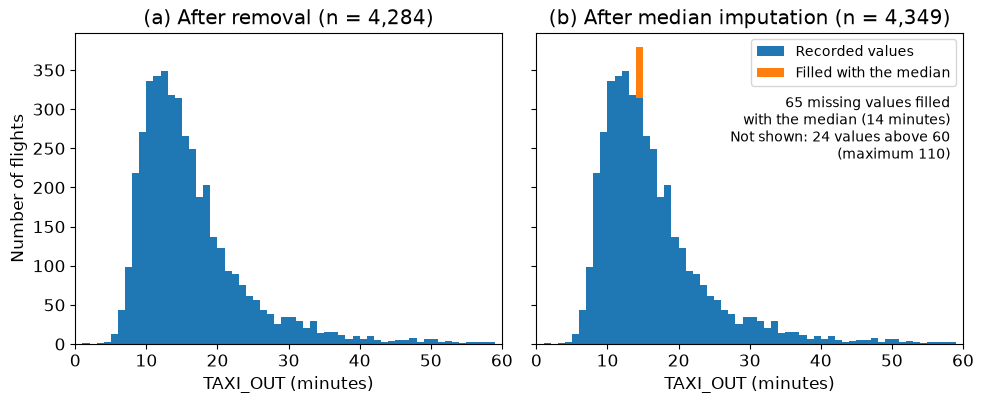

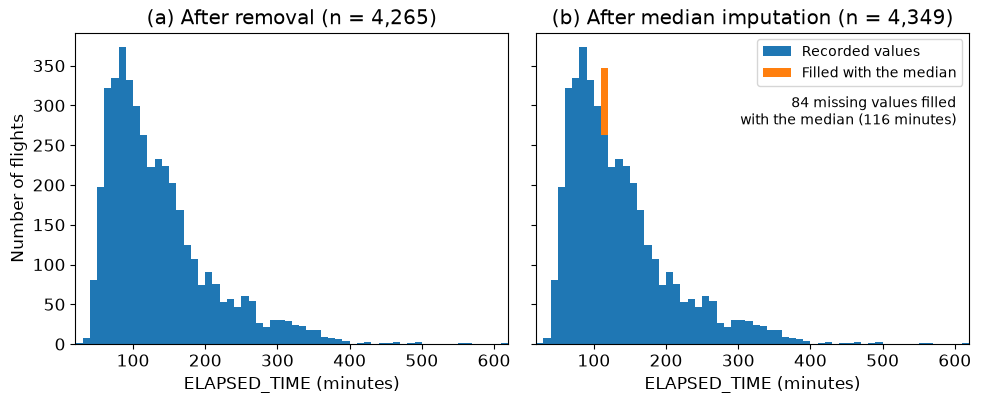

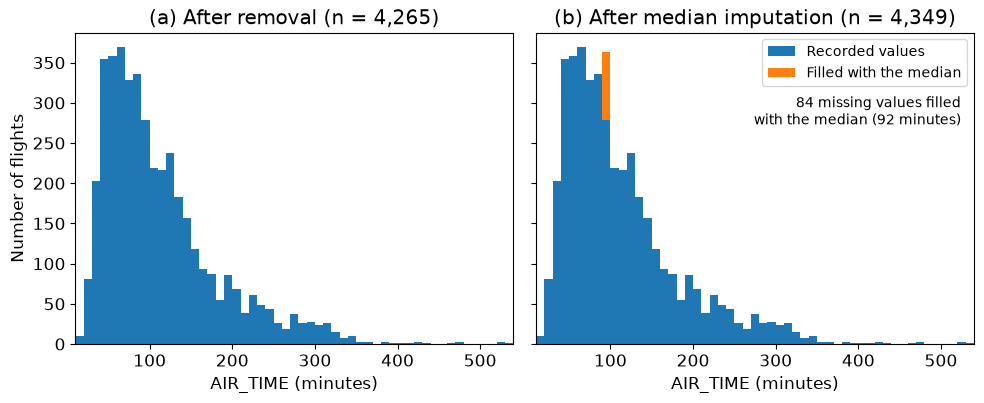

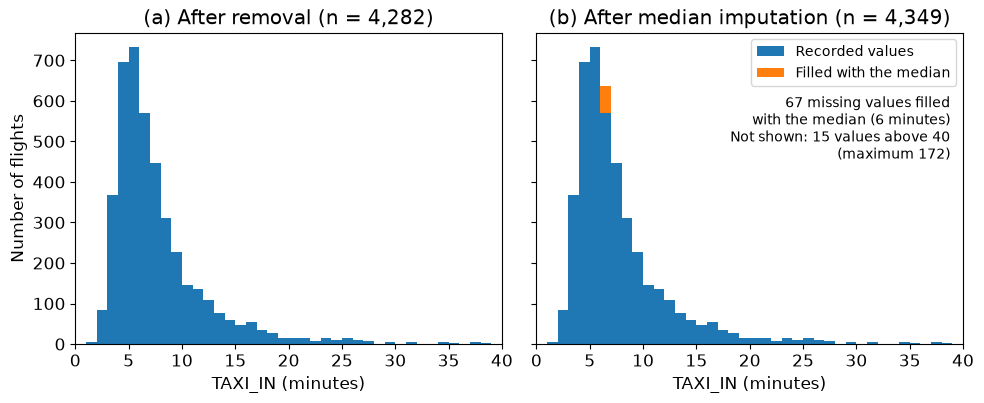

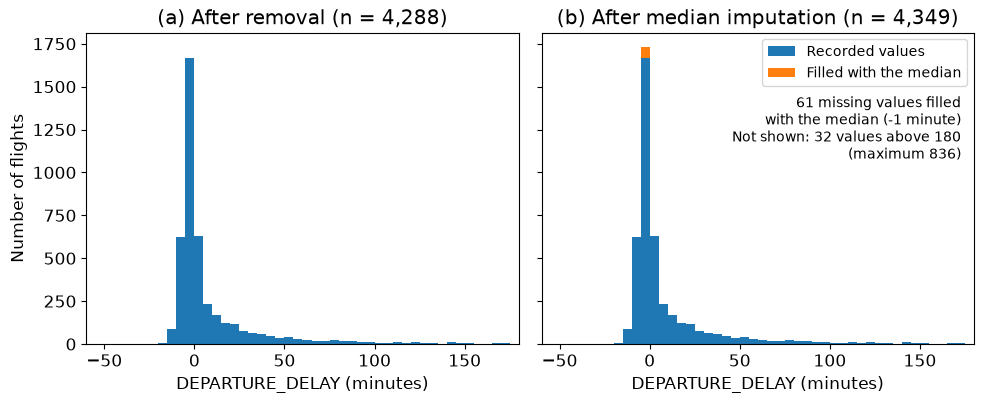

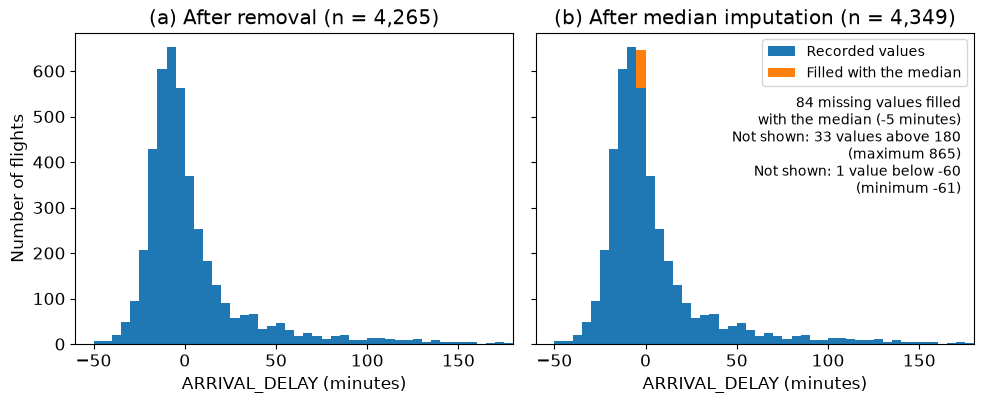

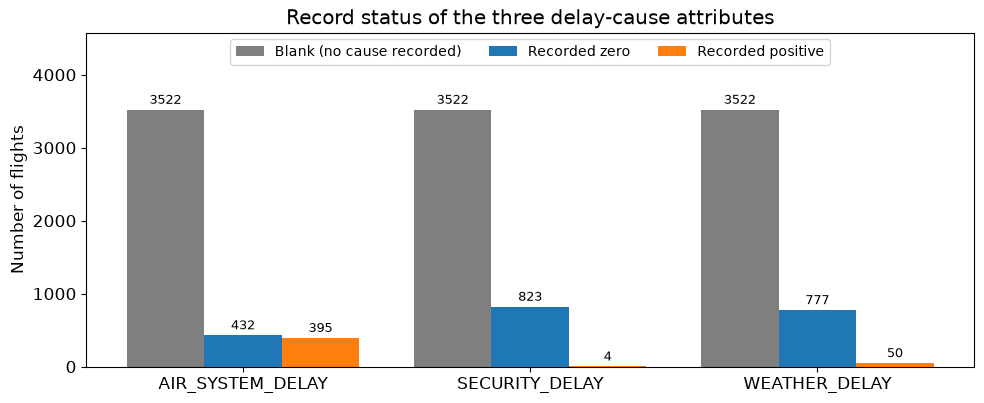

['figures/A2_TAXI_OUT_removal_vs_median.png',
 'figures/A2_ELAPSED_TIME_removal_vs_median.png',
 'figures/A2_AIR_TIME_removal_vs_median.png',
 'figures/A2_TAXI_IN_removal_vs_median.png',
 'figures/A2_DEPARTURE_DELAY_removal_vs_median.png',
 'figures/A2_ARRIVAL_DELAY_removal_vs_median.png',
 'figures/A2_delay_cause_record_status.png']

In [114]:
revised_figure_paths = [
    save_imputation_figure(
        "TAXI_OUT",
        bin_width=1,
        display_min=0,
        display_max=60
    ),
    save_imputation_figure(
        "ELAPSED_TIME",
        bin_width=10
    ),
    save_imputation_figure(
        "AIR_TIME",
        bin_width=10
    ),
    save_imputation_figure(
        "TAXI_IN",
        bin_width=1,
        display_min=0,
        display_max=40
    ),
    save_imputation_figure(
        "DEPARTURE_DELAY",
        bin_width=5,
        display_min=-60,
        display_max=180
    ),
    save_imputation_figure(
        "ARRIVAL_DELAY",
        bin_width=5,
        display_min=-60,
        display_max=180
    ),
    save_delay_cause_status_figure(),
]

revised_figure_paths


Removal remains the selected missing-value treatment. Median imputation is shown only as an
alternative comparison. Because only a small percentage of the six attributes is missing,
median imputation changes their summaries only slightly. Filling missing values adds
artificial copies of the median, so the mean moves slightly towards the median and the
standard deviation becomes slightly smaller. This demonstration helps show the impact of
another valid missing-data choice without replacing the chosen method.


The three delay-cause fields contain 3,522 blanks each. The teaching team requires these to
remain missing. Recorded zero and missing are different states. Treating every blank as zero
would spread the recorded delay-cause minutes over all 4,349 rows and would substantially
reduce the means. The blank-as-zero calculation is therefore a demonstration of an incorrect
treatment only. The analytical dataset is left unchanged.


The three available delay-cause fields account for only part of the recorded arrival-delay
minutes among flights arriving at least 15 minutes late. They should therefore not be treated
as a complete explanation of why flights were delayed.


For flights with all four duration fields recorded, `ELAPSED_TIME` equals `TAXI_OUT` plus
`AIR_TIME` plus `TAXI_IN` for every row. This is a consistency check. It does not prove that
every duration value is free of every possible recording error.


##### Validation of the missing-value impact section

The checks below confirm the new tables, revised figures, hidden-value annotations,
coverage counts and duration identity results. They also confirm that `df_raw` still matches
a fresh read of the CSV file and that no permanent imputation or blank-to-zero conversion
was applied.


In [115]:
from PIL import Image

expected_figures_a29 = [
    "figures/A2_TAXI_OUT_removal_vs_median.png",
    "figures/A2_ELAPSED_TIME_removal_vs_median.png",
    "figures/A2_AIR_TIME_removal_vs_median.png",
    "figures/A2_TAXI_IN_removal_vs_median.png",
    "figures/A2_DEPARTURE_DELAY_removal_vs_median.png",
    "figures/A2_ARRIVAL_DELAY_removal_vs_median.png",
    "figures/A2_delay_cause_record_status.png",
]

expected_outputs_a29 = [
    "outputs/A2_missing_impact_median_imputation.csv",
    "outputs/A2_delay_cause_blank_as_zero_demo.csv",
    "outputs/A2_delay_cause_coverage.csv",
    "outputs/A2_duration_consistency_check.csv",
]

expected_median_means = {
    "TAXI_OUT": (16.15, 16.11),
    "ELAPSED_TIME": (135.39, 135.01),
    "AIR_TIME": (111.76, 111.38),
    "TAXI_IN": (7.49, 7.47),
    "DEPARTURE_DELAY": (10.81, 10.64),
    "ARRIVAL_DELAY": (5.41, 5.21),
}

expected_median_sds = {
    "TAXI_OUT": (8.93, 8.87),
    "ELAPSED_TIME": (72.00, 71.35),
    "AIR_TIME": (69.50, 68.88),
    "TAXI_IN": (6.57, 6.52),
    "DEPARTURE_DELAY": (39.21, 38.96),
    "ARRIVAL_DELAY": (41.60, 41.22),
}

expected_median_skew = {
    "TAXI_OUT": (3.16, 3.19),
    "ELAPSED_TIME": (1.44, 1.46),
    "AIR_TIME": (1.45, 1.48),
    "TAXI_IN": (9.75, 9.82),
    "DEPARTURE_DELAY": (7.20, 7.25),
    "ARRIVAL_DELAY": (6.44, 6.50),
}

expected_blank_means = {
    "AIR_SYSTEM_DELAY": (12.64, 2.40),
    "SECURITY_DELAY": (0.07, 0.01),
    "WEATHER_DELAY": (3.28, 0.62),
}

expected_blank_sds = {
    "AIR_SYSTEM_DELAY": (29.71, 13.87),
    "SECURITY_DELAY": (1.29, 0.56),
    "WEATHER_DELAY": (21.33, 9.39),
}

hidden_expected = {
    "TAXI_OUT": (0, 60, 0, 24),
    "TAXI_IN": (0, 40, 0, 15),
    "DEPARTURE_DELAY": (-60, 180, 0, 32),
    "ARRIVAL_DELAY": (-60, 180, 1, 33),
}


def a29_hidden_counts(attribute_name, left, right):
    recorded = df_raw[attribute_name].dropna()
    return int((recorded < left).sum()), int((recorded > right).sum())


def a29_median_row(attribute_name):
    return median_imputation_impact.set_index("Attribute").loc[attribute_name]


def a29_blank_row(attribute_name):
    return blank_as_zero_demo.set_index("Attribute").loc[attribute_name]


In [116]:
df_raw_fresh_a29 = pd.read_csv(RAW_CSV)
with open(RAW_CSV, "rb") as raw_file_a29:
    raw_hash_a29 = hashlib.sha256(raw_file_a29.read()).hexdigest()

a29_checks = {
    "1. Median imputation table exists": os.path.exists(
        "outputs/A2_missing_impact_median_imputation.csv"
    ),
    "2. Blank-as-zero table exists": os.path.exists(
        "outputs/A2_delay_cause_blank_as_zero_demo.csv"
    ),
    "3. Delay-cause coverage table exists": os.path.exists(
        "outputs/A2_delay_cause_coverage.csv"
    ),
    "4. Duration consistency table exists": os.path.exists(
        "outputs/A2_duration_consistency_check.csv"
    ),
    "5. All seven revised figures exist": all(
        os.path.exists(path) for path in expected_figures_a29
    ),
    "6. Delayed flights equal 827": int(
        delay_cause_coverage.loc[0, "Delayed flights"]
    ) == 827,
    "7. Cause sum below equals 661": int(
        delay_cause_coverage.loc[0, "Cause sum below arrival delay"]
    ) == 661,
    "8. Cause sum equal equals 166": int(
        delay_cause_coverage.loc[0, "Cause sum equal to arrival delay"]
    ) == 166,
    "9. Cause sum above equals 0": int(
        delay_cause_coverage.loc[0, "Cause sum above arrival delay"]
    ) == 0,
    "10. All three causes zero equals 412": int(
        delay_cause_coverage.loc[0, "All three causes zero"]
    ) == 412,
    "11. Share explained equals 25.83": float(
        delay_cause_coverage.loc[0, "Share of delay minutes explained percent"]
    ) == 25.83,
    "12. Duration complete rows equal 4265": int(
        duration_consistency.loc[0, "Rows with all four recorded"]
    ) == 4265,
    "13. Duration identity holds for 4265 rows": int(
        duration_consistency.loc[0, "Rows where the identity holds"]
    ) == 4265,
    "14. Mean fall percent about 80.98 for all three": bool(
        ((blank_as_zero_demo["Mean fall percent"] - 80.98).abs() < 0.01).all()
    ),
    "15. df_raw equals fresh CSV read": df_raw.equals(df_raw_fresh_a29),
    "16. Raw CSV hash unchanged": raw_hash_a29 == (
        "676681651e11de53308116df0fc5b2ef72c5b967ec779d0159f747edd10499de"
    ),
    "17. df_raw shape still 4349 by 25": df_raw.shape == (4349, 25),
}

for attribute, (mean_rem, mean_imp) in expected_median_means.items():
    row = a29_median_row(attribute)
    a29_checks[f"18. {attribute} mean removal"] = float(row["Mean removal"]) == mean_rem
    a29_checks[f"19. {attribute} mean imputed"] = float(row["Mean imputed"]) == mean_imp

for attribute, (sd_rem, sd_imp) in expected_median_sds.items():
    row = a29_median_row(attribute)
    a29_checks[f"20. {attribute} SD removal"] = float(row["SD removal"]) == sd_rem
    a29_checks[f"21. {attribute} SD imputed"] = float(row["SD imputed"]) == sd_imp

for attribute, (skew_rem, skew_imp) in expected_median_skew.items():
    row = a29_median_row(attribute)
    a29_checks[f"22. {attribute} skew removal"] = float(row["Skewness removal"]) == skew_rem
    a29_checks[f"23. {attribute} skew imputed"] = float(row["Skewness imputed"]) == skew_imp

for attribute, (mean_miss, mean_zero) in expected_blank_means.items():
    row = a29_blank_row(attribute)
    a29_checks[f"24. {attribute} mean blanks missing"] = (
        float(row["Mean blanks missing"]) == mean_miss
    )
    a29_checks[f"25. {attribute} mean blanks as zero"] = (
        float(row["Mean blanks as zero"]) == mean_zero
    )

for attribute, (sd_miss, sd_zero) in expected_blank_sds.items():
    row = a29_blank_row(attribute)
    a29_checks[f"26. {attribute} SD blanks missing"] = (
        float(row["SD blanks missing"]) == sd_miss
    )
    a29_checks[f"27. {attribute} SD blanks as zero"] = (
        float(row["SD blanks as zero"]) == sd_zero
    )

for attribute, (left, right, low_count, high_count) in hidden_expected.items():
    low, high = a29_hidden_counts(attribute, left, right)
    a29_checks[f"28. {attribute} hidden below"] = low == low_count
    a29_checks[f"29. {attribute} hidden above"] = high == high_count

for path in expected_figures_a29:
    with Image.open(path) as image:
        dpi = image.info.get("dpi", (None, None))
        name = os.path.basename(path)
        a29_checks[f"30. {name} readable"] = image.size[0] > 0 and image.size[1] > 0
        a29_checks[f"31. {name} near 200 dpi"] = (
            dpi[0] is not None and abs(dpi[0] - 200) < 1
        )

a29_checks["32. Old TAXI_OUT comparison figure still exists"] = os.path.exists(
    "figures/A2_TAXI_OUT_missing_comparison.png"
)
a29_checks["33. Old ARRIVAL_DELAY comparison figure still exists"] = os.path.exists(
    "figures/A2_ARRIVAL_DELAY_missing_comparison.png"
)

a29_check_table = pd.DataFrame({
    "Check": list(a29_checks.keys()),
    "Passed": list(a29_checks.values()),
})
print("A2.9 checks passed:", int(a29_check_table["Passed"].sum()),
      "of", len(a29_check_table))
assert a29_check_table["Passed"].all(), a29_check_table.loc[~a29_check_table["Passed"]]
a29_check_table


A2.9 checks passed: 89 of 89


,Check,Passed
0,1. Median imputation table exists,True
1,2. Blank-as-zero table exists,True
2,3. Delay-cause coverage table exists,True
3,4. Duration consistency table exists,True
4,5. All seven revised figures exist,True
...,...,...
84,31. A2_ARRIVAL_DELAY_removal_vs_median.png nea...,True
85,30. A2_delay_cause_record_status.png readable,True
86,31. A2_delay_cause_record_status.png near 200 dpi,True
87,32. Old TAXI_OUT comparison figure still exists,True


All A2.9 checks pass. The revised figures make the effect of median imputation visible,
the blank-as-zero demonstration remains labelled as incorrect handling only, and `df_raw`
is still identical to the file on disk. Attribute-wise removal remains the selected
missing-value treatment for the real analysis.


### A2.10 Clock Times and Date

The six clock attributes are interval attributes stored as HHMM integer clock values.
Examples are 1655 for 16:55, 30 for 00:30 and 1 for 00:01. Raw HHMM arithmetic is
invalid for summary statistics, because neighbouring clock minutes can look far apart
as numbers. Each valid value is therefore converted temporarily to minutes after
midnight. Summary times are converted back to HH:MM for readability. Range, IQR and
standard deviation stay in minutes, variance stays in minutes squared, and skewness
is unitless.

Four actual-time attributes contain missing values: DEPARTURE_TIME, WHEELS_OFF,
WHEELS_ON and ARRIVAL_TIME. Attribute-wise removal is the selected treatment for
those recorded values. DATE is parsed into a separate datetime Series and summarised
as an interval attribute without overwriting the raw DATE column.


The helpers below convert between HHMM, minutes after midnight and HH:MM display
text. Rounding uses half-up (`math.floor(x + 0.5)`) rather than Python `round()`,
because banker's rounding would turn 914.5 into 914 and display 15:14 instead of
the required 15:15.


In [117]:
import math

clock_attributes = [
    "SCHEDULED_DEPARTURE",
    "DEPARTURE_TIME",
    "WHEELS_OFF",
    "WHEELS_ON",
    "SCHEDULED_ARRIVAL",
    "ARRIVAL_TIME",
]


def round_half_up(value):
    return math.floor(float(value) + 0.5)


def minutes_to_hhmm(value):
    rounded = math.floor(float(value) + 0.5)
    hours = rounded // 60
    minutes = rounded % 60
    return f"{hours:02d}:{minutes:02d}"


def hhmm_to_minutes(series):
    converted = series.astype(float).copy()
    valid = converted.notna()
    hhmm = converted.loc[valid]
    converted.loc[valid] = (hhmm // 100) * 60 + (hhmm % 100)
    return converted


Every recorded HHMM value is checked before conversion. Hours must fall between 0
and 23, and minutes between 0 and 59. Missing values are ignored for this validity
test only.


In [118]:
hhmm_validity_rows = []

for attribute_name in clock_attributes:
    recorded = df_raw[attribute_name].dropna()
    hours = (recorded // 100).astype(int)
    minutes = (recorded % 100).astype(int)
    invalid_hours = int(((hours < 0) | (hours > 23)).sum())
    invalid_minutes = int(((minutes < 0) | (minutes > 59)).sum())
    hhmm_validity_rows.append({
        "Attribute": attribute_name,
        "Recorded N": len(recorded),
        "Invalid hours": invalid_hours,
        "Invalid minutes": invalid_minutes,
    })

hhmm_validity = pd.DataFrame(hhmm_validity_rows)
assert (hhmm_validity["Invalid hours"] == 0).all()
assert (hhmm_validity["Invalid minutes"] == 0).all()
hhmm_validity


,Attribute,Recorded N,Invalid hours,Invalid minutes
0,SCHEDULED_DEPARTURE,4349,0,0
1,DEPARTURE_TIME,4288,0,0
2,WHEELS_OFF,4284,0,0
3,WHEELS_ON,4282,0,0
4,SCHEDULED_ARRIVAL,4349,0,0
5,ARRIVAL_TIME,4282,0,0


Temporary minutes-after-midnight Series are created for all six clock attributes.
They are used for statistics and charts only. Nothing is written back into `df_raw`.


In [119]:
clock_minutes = {
    attribute_name: hhmm_to_minutes(df_raw[attribute_name])
    for attribute_name in clock_attributes
}

for attribute_name, series in clock_minutes.items():
    print(
        attribute_name,
        "valid N =", int(series.notna().sum()),
        "missing =", int(series.isna().sum()),
        "minute range =", float(series.min()), "to", float(series.max()),
    )


SCHEDULED_DEPARTURE valid N = 4349 missing = 0 minute range = 30.0 to 1439.0
DEPARTURE_TIME valid N = 4288 missing = 61 minute range = 1.0 to 1435.0
WHEELS_OFF valid N = 4284 missing = 65 minute range = 2.0 to 1438.0
WHEELS_ON valid N = 4282 missing = 67 minute range = 1.0 to 1439.0
SCHEDULED_ARRIVAL valid N = 4349 missing = 0 minute range = 2.0 to 1439.0
ARRIVAL_TIME valid N = 4282 missing = 67 minute range = 1.0 to 1439.0


The summary table below uses the converted minutes. Mean, median, minimum, maximum,
Q1 and Q3 are shown as HH:MM with half-up rounding. Range, IQR and standard
deviation stay in minutes. Variance stays in minutes squared. Sample variance and
standard deviation use `ddof=1`.


In [120]:
clock_summary_rows = []

for attribute_name in clock_attributes:
    series = clock_minutes[attribute_name]
    recorded = series.dropna()
    missing = int(series.isna().sum())
    q1 = recorded.quantile(0.25)
    q3 = recorded.quantile(0.75)
    clock_summary_rows.append({
        "Attribute": attribute_name,
        "Total Rows": len(series),
        "Valid N": int(recorded.shape[0]),
        "Missing": missing,
        "Missing Percentage": round(100 * missing / len(series), 2),
        "Mean Time": minutes_to_hhmm(recorded.mean()),
        "Median Time": minutes_to_hhmm(recorded.median()),
        "Minimum Time": minutes_to_hhmm(recorded.min()),
        "Maximum Time": minutes_to_hhmm(recorded.max()),
        "Range (minutes)": float(recorded.max() - recorded.min()),
        "Variance (minutes squared)": round(recorded.var(ddof=1), 2),
        "Standard Deviation (minutes)": round(recorded.std(ddof=1), 2),
        "Q1 Time": minutes_to_hhmm(q1),
        "Q3 Time": minutes_to_hhmm(q3),
        "IQR (minutes)": float(q3 - q1),
        "Skewness": round(recorded.skew(), 2),
    })

clock_time_summary = pd.DataFrame(clock_summary_rows)
clock_time_summary.to_csv("outputs/A2_clock_time_summary.csv", index=False)
clock_time_summary


,Attribute,Total Rows,Valid N,Missing,Missing Percentage,Mean Time,Median Time,Minimum Time,Maximum Time,Range (minutes),Variance (minutes squared),Standard Deviation (minutes),Q1 Time,Q3 Time,IQR (minutes),Skewness
0,SCHEDULED_DEPARTURE,4349,4349,0,0.00,13:30,13:33,00:30,23:59,1409.0,84719.61,291.07,09:10,17:35,505.00,0.03
1,DEPARTURE_TIME,4349,4288,61,1.40,13:37,13:38,00:01,23:55,1434.0,88596.06,297.65,09:21,17:44,503.00,0.01
2,WHEELS_OFF,4349,4284,65,1.49,13:52,13:52,00:02,23:58,1436.0,89076.71,298.46,09:37,18:00,503.25,-0.01
3,WHEELS_ON,4349,4282,67,1.54,15:01,15:15,00:01,23:59,1438.0,98955.97,314.57,10:59,19:19,499.75,-0.35
4,SCHEDULED_ARRIVAL,4349,4349,0,0.00,15:17,15:35,00:02,23:59,1437.0,91872.90,303.11,11:14,19:24,490.00,-0.28
5,ARRIVAL_TIME,4349,4282,67,1.54,15:05,15:20,00:01,23:59,1438.0,100683.21,317.31,11:04,19:23,499.00,-0.38


Full-precision minute statistics are kept in a separate working table so later
validation can compare against the exact expected values without relying on the
rounded display table alone.


In [121]:
clock_stats_precise = {}

for attribute_name in clock_attributes:
    recorded = clock_minutes[attribute_name].dropna()
    clock_stats_precise[attribute_name] = {
        "valid_n": int(recorded.shape[0]),
        "missing": int(clock_minutes[attribute_name].isna().sum()),
        "mean": float(recorded.mean()),
        "median": float(recorded.median()),
        "minimum": float(recorded.min()),
        "maximum": float(recorded.max()),
        "range": float(recorded.max() - recorded.min()),
        "variance": float(recorded.var(ddof=1)),
        "std": float(recorded.std(ddof=1)),
        "q1": float(recorded.quantile(0.25)),
        "q3": float(recorded.quantile(0.75)),
        "iqr": float(recorded.quantile(0.75) - recorded.quantile(0.25)),
        "skewness": float(recorded.skew()),
    }

print("WHEELS_ON median minutes:", clock_stats_precise["WHEELS_ON"]["median"])
print("WHEELS_ON median display:", minutes_to_hhmm(clock_stats_precise["WHEELS_ON"]["median"]))


WHEELS_ON median minutes: 914.5
WHEELS_ON median display: 15:15


The figure below shows all six clock-time distributions in one 3 by 2 layout. Every
subplot uses the same 60-minute bins from 0 to 1440, which gives 24 one-hour bins.


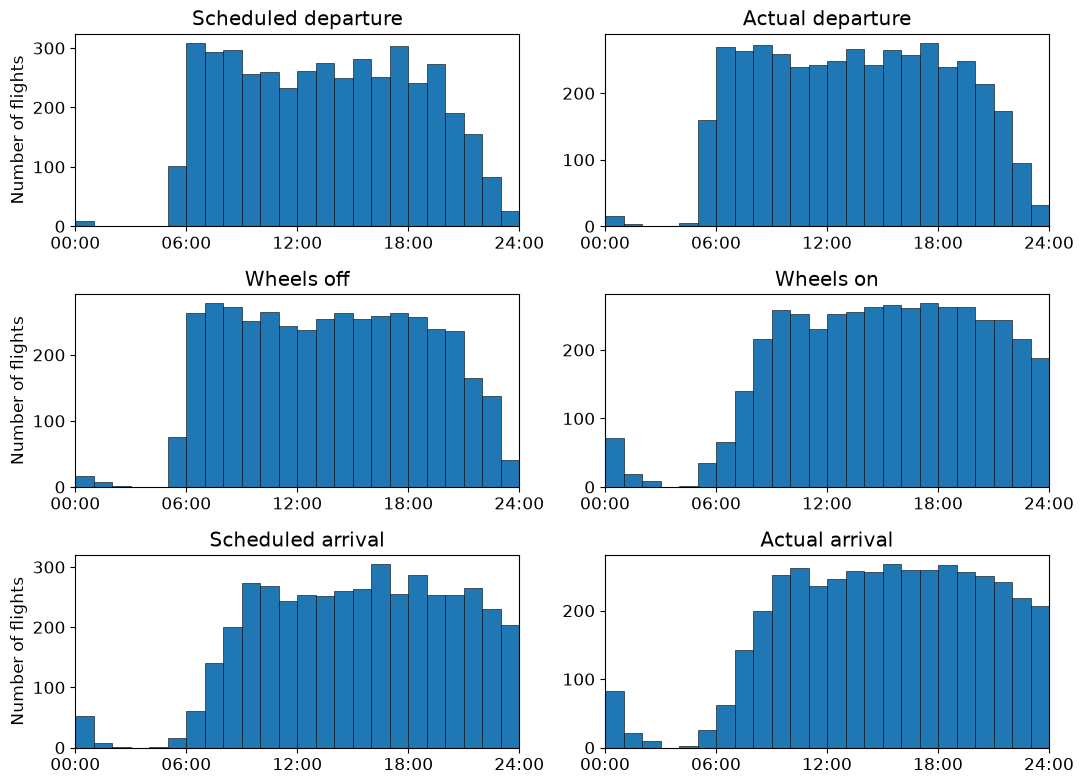

,Hour,SCHEDULED_DEPARTURE,DEPARTURE_TIME,WHEELS_OFF,WHEELS_ON,SCHEDULED_ARRIVAL,ARRIVAL_TIME
0,00:00,9,15,16,72,52,82
1,01:00,1,4,7,19,8,21
2,02:00,0,1,1,9,1,10
3,03:00,0,0,0,0,0,0
4,04:00,0,5,0,2,1,2
5,05:00,101,160,75,35,16,25
6,06:00,309,269,263,66,60,62
7,07:00,294,263,278,140,140,142
8,08:00,296,273,273,216,201,199
9,09:00,256,259,252,259,274,252


In [122]:
clock_bin_edges = np.arange(0, 1441, 60)
clock_titles = {
    "SCHEDULED_DEPARTURE": "Scheduled departure",
    "DEPARTURE_TIME": "Actual departure",
    "WHEELS_OFF": "Wheels off",
    "WHEELS_ON": "Wheels on",
    "SCHEDULED_ARRIVAL": "Scheduled arrival",
    "ARRIVAL_TIME": "Actual arrival",
}
tick_positions = [0, 360, 720, 1080, 1440]
tick_labels = [minutes_to_hhmm(value) for value in tick_positions]

hourly_count_data = {"Hour": [f"{hour:02d}:00" for hour in range(24)]}

with plt.rc_context({"font.size": 12}):
    figure, axes = plt.subplots(3, 2, figsize=(11, 8), sharey=False)
    for axis, attribute_name in zip(axes.flat, clock_attributes):
        values = clock_minutes[attribute_name].dropna()
        counts, _ = np.histogram(values, bins=clock_bin_edges)
        hourly_count_data[attribute_name] = counts
        axis.hist(values, bins=clock_bin_edges, edgecolor="black", linewidth=0.4)
        axis.set_xlim(0, 1440)
        axis.set_xticks(tick_positions)
        axis.set_xticklabels(tick_labels)
        axis.set_title(clock_titles[attribute_name])
    for row in range(3):
        axes[row, 0].set_ylabel("Number of flights")
    figure.tight_layout()
    figure.savefig("figures/A2_clock_time_distributions.png", dpi=200)
    plt.show()

clock_hourly_counts = pd.DataFrame(hourly_count_data)
clock_hourly_counts.to_csv("outputs/A2_clock_hourly_counts.csv", index=False)
clock_hourly_counts


Clock times were converted to minutes after midnight before calculation. Because
time of day wraps at midnight, the linear mean and spread should be interpreted as
simple summaries of time of day rather than circular-time measures. For example,
23:50 and 00:10 are only 20 minutes apart on a clock, but they sit near opposite
ends of the 0 to 1440 scale. The very large linear ranges close to 1440 minutes
partly reflect this midnight boundary. Circular statistics are not used here.


#### Missing clock values and flight status

The next table checks how the missing actual-time values relate to cancelled and
diverted flights. Counts alone cannot prove causation, so the wording stays limited
to what the table shows.


In [123]:
missing_clock_attributes = [
    "DEPARTURE_TIME",
    "WHEELS_OFF",
    "WHEELS_ON",
    "ARRIVAL_TIME",
]
cancelled_flag = df_raw["CANCELLED"] == 1
diverted_flag = df_raw["DIVERTED"] == 1
status_rows = []

for attribute_name in missing_clock_attributes:
    missing = df_raw[attribute_name].isna()
    recorded = ~missing
    status_rows.append({
        "Attribute": attribute_name,
        "Missing": int(missing.sum()),
        "Missing and cancelled": int((missing & cancelled_flag).sum()),
        "Missing and diverted": int((missing & diverted_flag).sum()),
        "Missing and neither": int((missing & ~cancelled_flag & ~diverted_flag).sum()),
        "Cancelled with recorded value": int((recorded & cancelled_flag).sum()),
        "Diverted with recorded value": int((recorded & diverted_flag).sum()),
    })

clock_missing_status = pd.DataFrame(status_rows)
clock_missing_status.to_csv("outputs/A2_clock_missing_status_check.csv", index=False)
clock_missing_status


,Attribute,Missing,Missing and cancelled,Missing and diverted,Missing and neither,Cancelled with recorded value,Diverted with recorded value
0,DEPARTURE_TIME,61,61,0,0,5,18
1,WHEELS_OFF,65,65,0,0,1,18
2,WHEELS_ON,67,66,1,0,0,17
3,ARRIVAL_TIME,67,66,1,0,0,17


#### Median imputation comparison for clock times

Attribute-wise removal remains the selected treatment. Median imputation is shown
only as a temporary comparison. Missing places are filled with the median of the
recorded minutes-after-midnight values. Nothing is written into `df_raw`.


In [124]:
impact_rows = []
clock_imputed_minutes = {}
clock_median_fill = {}

for attribute_name in missing_clock_attributes:
    converted = clock_minutes[attribute_name]
    removal = converted.dropna()
    median_value = float(removal.median())
    imputed = converted.fillna(median_value)
    clock_imputed_minutes[attribute_name] = imputed
    clock_median_fill[attribute_name] = median_value
    sd_removal = float(removal.std(ddof=1))
    sd_imputed = float(imputed.std(ddof=1))
    impact_rows.append({
        "Attribute": attribute_name,
        "Missing": int(converted.isna().sum()),
        "N removal": int(removal.shape[0]),
        "N imputed": int(imputed.notna().sum()),
        "Median fill time": minutes_to_hhmm(median_value),
        "Mean removal": minutes_to_hhmm(removal.mean()),
        "Mean imputed": minutes_to_hhmm(imputed.mean()),
        "SD removal (minutes)": round(sd_removal, 2),
        "SD imputed (minutes)": round(sd_imputed, 2),
        "Variance removal (minutes squared)": round(float(removal.var(ddof=1)), 2),
        "Variance imputed (minutes squared)": round(float(imputed.var(ddof=1)), 2),
        "Q1 removal": minutes_to_hhmm(removal.quantile(0.25)),
        "Q1 imputed": minutes_to_hhmm(imputed.quantile(0.25)),
        "Q3 removal": minutes_to_hhmm(removal.quantile(0.75)),
        "Q3 imputed": minutes_to_hhmm(imputed.quantile(0.75)),
        "Skewness removal": round(float(removal.skew()), 2),
        "Skewness imputed": round(float(imputed.skew()), 2),
        "SD change percent": round(100 * (sd_imputed - sd_removal) / sd_removal, 2),
    })

clock_missing_impact = pd.DataFrame(impact_rows)
clock_missing_impact.to_csv("outputs/A2_clock_missing_impact_median.csv", index=False)
clock_missing_impact


,Attribute,Missing,N removal,N imputed,Median fill time,Mean removal,Mean imputed,SD removal (minutes),SD imputed (minutes),Variance removal (minutes squared),Variance imputed (minutes squared),Q1 removal,Q1 imputed,Q3 removal,Q3 imputed,Skewness removal,Skewness imputed,SD change percent
0,DEPARTURE_TIME,61,4288,4349,13:38,13:37,13:37,297.65,295.56,88596.06,87353.13,09:21,09:24,17:44,17:41,0.01,0.01,-0.70
1,WHEELS_OFF,65,4284,4349,13:52,13:52,13:52,298.46,296.22,89076.71,87745.07,09:37,09:41,18:00,17:58,-0.01,-0.01,-0.75
2,WHEELS_ON,67,4282,4349,15:15,15:01,15:02,314.57,312.14,98955.97,97433.70,10:59,11:03,19:19,19:13,-0.35,-0.35,-0.77
3,ARRIVAL_TIME,67,4282,4349,15:20,15:05,15:05,317.31,314.86,100683.21,99135.35,11:04,11:07,19:23,19:20,-0.38,-0.39,-0.77


In [125]:
clock_impact_precise = {}

for attribute_name in missing_clock_attributes:
    converted = clock_minutes[attribute_name]
    removal = converted.dropna()
    median_value = float(removal.median())
    imputed = converted.fillna(median_value)
    sd_removal = float(removal.std(ddof=1))
    sd_imputed = float(imputed.std(ddof=1))
    clock_impact_precise[attribute_name] = {
        "missing": int(converted.isna().sum()),
        "n_removal": int(removal.shape[0]),
        "n_imputed": int(imputed.notna().sum()),
        "median": median_value,
        "mean_removal": float(removal.mean()),
        "mean_imputed": float(imputed.mean()),
        "sd_removal": sd_removal,
        "sd_imputed": sd_imputed,
        "var_removal": float(removal.var(ddof=1)),
        "var_imputed": float(imputed.var(ddof=1)),
        "q1_removal": float(removal.quantile(0.25)),
        "q1_imputed": float(imputed.quantile(0.25)),
        "q3_removal": float(removal.quantile(0.75)),
        "q3_imputed": float(imputed.quantile(0.75)),
        "skew_removal": float(removal.skew()),
        "skew_imputed": float(imputed.skew()),
        "sd_change_percent": 100 * (sd_imputed - sd_removal) / sd_removal,
    }


The comparison figure shows recorded values in blue. The orange bars add only the
temporary median-filled observations, stacked on top of the recorded distribution.


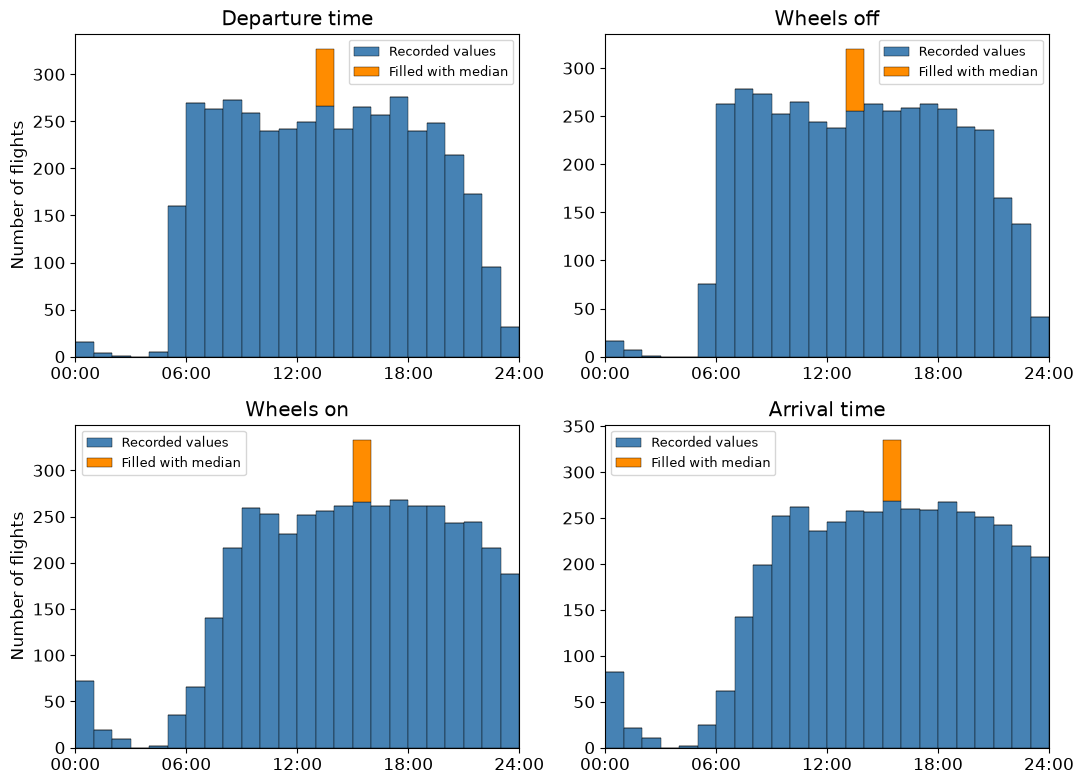

In [126]:
impact_titles = {
    "DEPARTURE_TIME": "Departure time",
    "WHEELS_OFF": "Wheels off",
    "WHEELS_ON": "Wheels on",
    "ARRIVAL_TIME": "Arrival time",
}
orange_added_counts = {}

with plt.rc_context({"font.size": 12}):
    figure, axes = plt.subplots(2, 2, figsize=(11, 8))
    for axis, attribute_name in zip(axes.flat, missing_clock_attributes):
        recorded = clock_minutes[attribute_name].dropna()
        fill_value = clock_median_fill[attribute_name]
        missing_n = int(clock_minutes[attribute_name].isna().sum())
        recorded_counts, _ = np.histogram(recorded, bins=clock_bin_edges)
        filled_only = np.full(missing_n, fill_value)
        filled_counts, _ = np.histogram(filled_only, bins=clock_bin_edges)
        orange_added_counts[attribute_name] = filled_counts
        axis.bar(
            clock_bin_edges[:-1], recorded_counts, width=60, align="edge",
            color="steelblue", edgecolor="black", linewidth=0.3, label="Recorded values",
        )
        axis.bar(
            clock_bin_edges[:-1], filled_counts, width=60, align="edge",
            bottom=recorded_counts, color="darkorange", edgecolor="black",
            linewidth=0.3, label="Filled with median",
        )
        axis.set_xlim(0, 1440)
        axis.set_xticks(tick_positions)
        axis.set_xticklabels(tick_labels)
        axis.set_title(impact_titles[attribute_name])
        axis.legend(fontsize=9)
    axes[0, 0].set_ylabel("Number of flights")
    axes[1, 0].set_ylabel("Number of flights")
    figure.tight_layout()
    figure.savefig("figures/A2_clock_missing_impact.png", dpi=200)
    plt.show()


Removal remains the selected treatment. Median imputation is only an alternative
comparison. The missing percentages are only 1.40 to 1.54 per cent, so filling with
the median changes the overall summaries only slightly. Standard deviation falls by
approximately 0.70 to 0.77 per cent. The WHEELS_ON mean display shifts from 15:01 to
15:02, while the other displayed mean times remain unchanged after rounding.
Imputation creates artificial observations at a single clock time. Removal preserves
only the recorded times.


#### DATE as an interval attribute

DATE is parsed into a separate Series with an explicit calendar format. The raw
`df_raw["DATE"]` column is left unchanged.


In [127]:
date_raw_before = df_raw["DATE"].copy()
date_parsed = pd.to_datetime(df_raw["DATE"], format="%Y-%m-%d", errors="raise")
date_parse_failures = 0  # errors='raise' would have stopped on any failure

print("DATE N:", len(date_parsed))
print("DATE missing:", int(date_parsed.isna().sum()))
print("DATE parse failures:", date_parse_failures)
print("Raw DATE unchanged:", df_raw["DATE"].equals(date_raw_before))
print("Earliest:", date_parsed.min().date())
print("Latest:", date_parsed.max().date())


DATE N: 4349
DATE missing: 0
DATE parse failures: 0
Raw DATE unchanged: True
Earliest: 2015-01-01
Latest: 2015-12-31


Day offsets from the earliest date turn the calendar values into an interval scale.
Mean date uses half-up rounding of the mean day offset back to the nearest day
before conversion to a calendar date.


In [128]:
origin_date = date_parsed.min()
date_offset_days = (date_parsed - origin_date).dt.days.astype(float)

mean_offset = float(date_offset_days.mean())
mean_offset_rounded = round_half_up(mean_offset)
mean_date = origin_date + pd.Timedelta(days=mean_offset_rounded)
median_offset = float(date_offset_days.median())
median_date = origin_date + pd.Timedelta(days=int(median_offset))
q1_offset = float(date_offset_days.quantile(0.25))
q3_offset = float(date_offset_days.quantile(0.75))
q1_date = origin_date + pd.Timedelta(days=int(q1_offset))
q3_date = origin_date + pd.Timedelta(days=int(q3_offset))

date_summary = pd.DataFrame([{
    "N": int(date_offset_days.shape[0]),
    "Missing": int(date_parsed.isna().sum()),
    "Earliest date": origin_date.strftime("%d %B %Y"),
    "Latest date": date_parsed.max().strftime("%d %B %Y"),
    "Span in days": float(date_offset_days.max() - date_offset_days.min()),
    "Mean date": mean_date.strftime("%d %B %Y"),
    "Median date": median_date.strftime("%d %B %Y"),
    "Variance (days squared)": round(float(date_offset_days.var(ddof=1)), 2),
    "Standard deviation (days)": round(float(date_offset_days.std(ddof=1)), 2),
    "Q1 date": q1_date.strftime("%d %B %Y"),
    "Q3 date": q3_date.strftime("%d %B %Y"),
    "IQR (days)": float(q3_offset - q1_offset),
    "Skewness": round(float(date_offset_days.skew()), 2),
}])
date_summary.to_csv("outputs/A2_DATE_summary.csv", index=False)
date_summary


,N,Missing,Earliest date,Latest date,Span in days,Mean date,Median date,Variance (days squared),Standard deviation (days),Q1 date,Q3 date,IQR (days),Skewness
0,4349,0,01 January 2015,31 December 2015,364.0,22 June 2015,19 June 2015,10433.62,102.15,29 March 2015,03 September 2015,158.0,0.18


In [129]:
date_stats_precise = {
    "n": int(date_offset_days.shape[0]),
    "missing": int(date_parsed.isna().sum()),
    "earliest": origin_date.strftime("%Y-%m-%d"),
    "latest": date_parsed.max().strftime("%Y-%m-%d"),
    "span": float(date_offset_days.max() - date_offset_days.min()),
    "mean_offset": mean_offset,
    "mean_date": mean_date.strftime("%d %B %Y"),
    "median_date": median_date.strftime("%d %B %Y"),
    "variance": float(date_offset_days.var(ddof=1)),
    "std": float(date_offset_days.std(ddof=1)),
    "q1_date": q1_date.strftime("%d %B %Y"),
    "q3_date": q3_date.strftime("%d %B %Y"),
    "iqr": float(q3_offset - q1_offset),
    "skewness": float(date_offset_days.skew()),
}
date_stats_precise


{'n': 4349,
 'missing': 0,
 'earliest': '2015-01-01',
 'latest': '2015-12-31',
 'span': 364.0,
 'mean_offset': 171.76270406990113,
 'mean_date': '22 June 2015',
 'median_date': '19 June 2015',
 'variance': 10433.618930680805,
 'std': 102.14508764830937,
 'q1_date': '29 March 2015',
 'q3_date': '03 September 2015',
 'iqr': 158.0,
 'skewness': 0.178699018925211}

Monthly counts are built for all 12 calendar months, including months with zero
records. October must appear explicitly even when its count is zero.


In [130]:
month_names = [
    "January", "February", "March", "April", "May", "June",
    "July", "August", "September", "October", "November", "December",
]
month_labels_short = [
    "Jan", "Feb", "Mar", "Apr", "May", "Jun",
    "Jul", "Aug", "Sep", "Oct", "Nov", "Dec",
]

monthly_counts = (
    date_parsed.dt.month
    .value_counts()
    .reindex(range(1, 13), fill_value=0)
    .sort_index()
)

date_month_counts = pd.DataFrame({
    "Month Number": list(range(1, 13)),
    "Month": month_names,
    "Flight Count": monthly_counts.astype(int).tolist(),
})
date_month_counts.to_csv("outputs/A2_DATE_month_counts.csv", index=False)
date_month_counts


,Month Number,Month,Flight Count
0,1,January,373
1,2,February,355
2,3,March,391
3,4,April,424
4,5,May,398
5,6,June,403
6,7,July,455
7,8,August,411
8,9,September,398
9,10,October,0


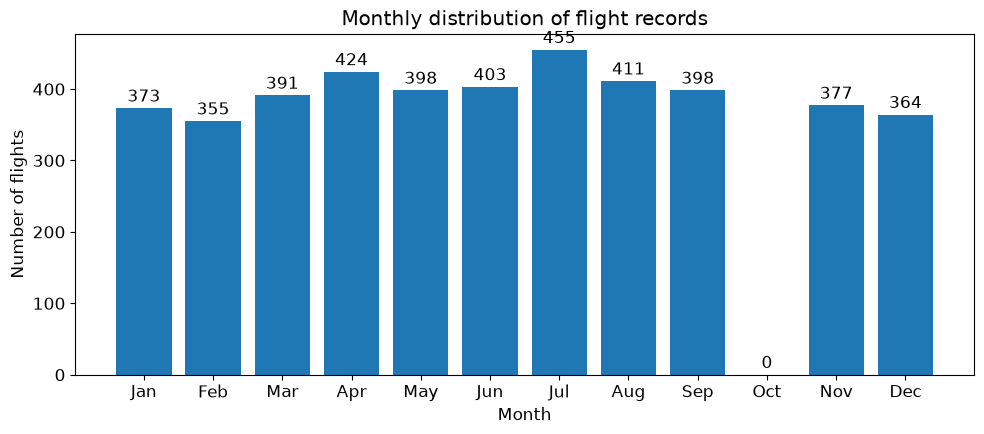

October count: 0
Monthly total: 4349
October on x axis: True


In [131]:
with plt.rc_context({"font.size": 12}):
    figure, axis = plt.subplots(figsize=(10, 4.5))
    bars = axis.bar(month_labels_short, date_month_counts["Flight Count"].tolist())
    axis.bar_label(bars, padding=2)
    axis.set_xlabel("Month")
    axis.set_ylabel("Number of flights")
    axis.set_title("Monthly distribution of flight records")
    figure.tight_layout()
    figure.savefig("figures/A2_DATE_monthly_distribution.png", dpi=200)
    plt.show()

print("October count:", int(date_month_counts.loc[
    date_month_counts["Month"] == "October", "Flight Count"
].iloc[0]))
print("Monthly total:", int(date_month_counts["Flight Count"].sum()))
print("October on x axis:", "Oct" in month_labels_short)


The DATE values span 1 January 2015 to 31 December 2015. The median date is
19 June 2015 and the mean date is 22 June 2015. July has the highest monthly count
at 455 flights. October has ZERO records in this dataset. October must not be
described as a month with few flights; it has no records here at all.

October has no records, so the year is not evenly covered. This gap contributes to
the observed DATE distribution and means that the mean and median dates describe
the available sample rather than a uniformly covered year. No reason for the
October gap is invented here. This is a dataset-coverage finding only.

Section C reminder: the absence of October records should be revisited as a
data-quality and coverage limitation in the executive summary.


#### Clock attribute interpretations

SCHEDULED_DEPARTURE has mean 13:30 and median 13:33, with no missing values. Most
scheduled departures sit in daytime and evening hours on the one-hour histogram.

DEPARTURE_TIME has mean 13:37 and median 13:38, with 61 missing values. Its
distribution is close to the scheduled pattern after attribute-wise removal.

WHEELS_OFF has mean and median both 13:52, with 65 missing values. That places
wheels-off a little later than departure time on the same linear day scale.

WHEELS_ON has mean 15:01 and median 15:15, with 67 missing values. Arrival-side
times sit later in the day than the departure-side times.

SCHEDULED_ARRIVAL has mean 15:17 and median 15:35, with no missing values. The
scheduled arrivals also concentrate in the afternoon and evening hours.

ARRIVAL_TIME has mean 15:05 and median 15:20, with 67 missing values. After
removal, the recorded arrivals remain broadly similar to the scheduled arrival
pattern on the linear day scale.

Skewness of these time-of-day distributions is not overinterpreted, because the
midnight boundary affects the linear scale. No causal claims are made from these
summaries alone.


A compact overview table gathers the seven A2.10 attributes for later report use.
It does not replace the detailed summary outputs.


In [132]:
overview_rows = []
for attribute_name in clock_attributes:
    stats = clock_stats_precise[attribute_name]
    overview_rows.append({
        "Attribute": attribute_name,
        "Type": "Interval (clock time)",
        "Valid N": stats["valid_n"],
        "Missing": stats["missing"],
        "Main Centre": (
            f"mean {minutes_to_hhmm(stats['mean'])}; "
            f"median {minutes_to_hhmm(stats['median'])}"
        ),
        "Main Spread": (
            f"SD {round(stats['std'], 2)} min; "
            f"IQR {stats['iqr']} min"
        ),
        "Key Finding": (
            "HHMM converted to minutes after midnight; "
            + (
                "attribute-wise removal used for missing values"
                if stats["missing"] > 0
                else "no missing values"
            )
        ),
    })

overview_rows.append({
    "Attribute": "DATE",
    "Type": "Interval (calendar date)",
    "Valid N": date_stats_precise["n"],
    "Missing": date_stats_precise["missing"],
    "Main Centre": (
        f"mean {date_stats_precise['mean_date']}; "
        f"median {date_stats_precise['median_date']}"
    ),
    "Main Spread": (
        f"SD {round(date_stats_precise['std'], 2)} days; "
        f"IQR {date_stats_precise['iqr']} days"
    ),
    "Key Finding": "October has zero records in this dataset",
})

clock_date_overview = pd.DataFrame(overview_rows)
clock_date_overview.to_csv("outputs/A2_clock_date_overview.csv", index=False)
clock_date_overview


,Attribute,Type,Valid N,Missing,Main Centre,Main Spread,Key Finding
0,SCHEDULED_DEPARTURE,Interval (clock time),4349,0,mean 13:30; median 13:33,SD 291.07 min; IQR 505.0 min,HHMM converted to minutes after midnight; no m...
1,DEPARTURE_TIME,Interval (clock time),4288,61,mean 13:37; median 13:38,SD 297.65 min; IQR 503.0 min,HHMM converted to minutes after midnight; attr...
2,WHEELS_OFF,Interval (clock time),4284,65,mean 13:52; median 13:52,SD 298.46 min; IQR 503.25 min,HHMM converted to minutes after midnight; attr...
3,WHEELS_ON,Interval (clock time),4282,67,mean 15:01; median 15:15,SD 314.57 min; IQR 499.75 min,HHMM converted to minutes after midnight; attr...
4,SCHEDULED_ARRIVAL,Interval (clock time),4349,0,mean 15:17; median 15:35,SD 303.11 min; IQR 490.0 min,HHMM converted to minutes after midnight; no m...
5,ARRIVAL_TIME,Interval (clock time),4282,67,mean 15:05; median 15:20,SD 317.31 min; IQR 499.0 min,HHMM converted to minutes after midnight; attr...
6,DATE,Interval (calendar date),4349,0,mean 22 June 2015; median 19 June 2015,SD 102.15 days; IQR 158.0 days,October has zero records in this dataset


##### Validation of the clock-time and DATE section

The checks below confirm the HHMM conversion, half-up display rule, hourly counts,
missing-status splits, median-imputation comparison, DATE summaries, October zero
count, output files and raw-data integrity.


In [133]:
expected_clock_stats = {
    "SCHEDULED_DEPARTURE": {
        "valid_n": 4349, "missing": 0,
        "mean": 810.3715796734882, "median": 813.0,
        "minimum": 30, "maximum": 1439, "range": 1409,
        "variance": 84719.6130467451, "std": 291.066337879778,
        "q1": 550, "q3": 1055, "iqr": 505, "skewness": 0.031043371660576784,
        "mean_disp": "13:30", "median_disp": "13:33",
        "min_disp": "00:30", "max_disp": "23:59",
        "q1_disp": "09:10", "q3_disp": "17:35",
    },
    "DEPARTURE_TIME": {
        "valid_n": 4288, "missing": 61,
        "mean": 816.8339552238806, "median": 818,
        "minimum": 1, "maximum": 1435, "range": 1434,
        "variance": 88596.06199582912, "std": 297.65090625736235,
        "q1": 561, "q3": 1064, "iqr": 503, "skewness": 0.007692976228646388,
        "mean_disp": "13:37", "median_disp": "13:38",
        "min_disp": "00:01", "max_disp": "23:55",
        "q1_disp": "09:21", "q3_disp": "17:44",
    },
    "WHEELS_OFF": {
        "valid_n": 4284, "missing": 65,
        "mean": 831.6514939309056, "median": 832,
        "minimum": 2, "maximum": 1438, "range": 1436,
        "variance": 89076.71414439386, "std": 298.45722330745133,
        "q1": 577, "q3": 1080.25, "iqr": 503.25, "skewness": -0.008571646331709424,
        "mean_disp": "13:52", "median_disp": "13:52",
        "min_disp": "00:02", "max_disp": "23:58",
        "q1_disp": "09:37", "q3_disp": "18:00",
    },
    "WHEELS_ON": {
        "valid_n": 4282, "missing": 67,
        "mean": 901.4546940681925, "median": 914.5,
        "minimum": 1, "maximum": 1439, "range": 1438,
        "variance": 98955.9700328543, "std": 314.572678458976,
        "q1": 659.25, "q3": 1159, "iqr": 499.75, "skewness": -0.3481107531619939,
        "mean_disp": "15:01", "median_disp": "15:15",
        "min_disp": "00:01", "max_disp": "23:59",
        "q1_disp": "10:59", "q3_disp": "19:19",
    },
    "SCHEDULED_ARRIVAL": {
        "valid_n": 4349, "missing": 0,
        "mean": 917.0218441020925, "median": 935,
        "minimum": 2, "maximum": 1439, "range": 1437,
        "variance": 91872.9036165617, "std": 303.10543316899106,
        "q1": 674, "q3": 1164, "iqr": 490, "skewness": -0.2754525451351922,
        "mean_disp": "15:17", "median_disp": "15:35",
        "min_disp": "00:02", "max_disp": "23:59",
        "q1_disp": "11:14", "q3_disp": "19:24",
    },
    "ARRIVAL_TIME": {
        "valid_n": 4282, "missing": 67,
        "mean": 904.5712283979449, "median": 920,
        "minimum": 1, "maximum": 1439, "range": 1438,
        "variance": 100683.20877723397, "std": 317.30617513252713,
        "q1": 664, "q3": 1163, "iqr": 499, "skewness": -0.383300141379763,
        "mean_disp": "15:05", "median_disp": "15:20",
        "min_disp": "00:01", "max_disp": "23:59",
        "q1_disp": "11:04", "q3_disp": "19:23",
    },
}

expected_hourly = {
    "SCHEDULED_DEPARTURE": [9, 1, 0, 0, 0, 101, 309, 294, 296, 256, 260, 232,
                            262, 275, 250, 281, 252, 303, 242, 273, 190, 155, 83, 25],
    "DEPARTURE_TIME": [15, 4, 1, 0, 5, 160, 269, 263, 273, 259, 240, 242,
                       249, 266, 242, 265, 257, 276, 240, 248, 214, 173, 95, 32],
    "WHEELS_OFF": [16, 7, 1, 0, 0, 75, 263, 278, 273, 252, 265, 244,
                   238, 255, 263, 255, 259, 263, 258, 239, 236, 165, 138, 41],
    "WHEELS_ON": [72, 19, 9, 0, 2, 35, 66, 140, 216, 259, 253, 231,
                  252, 256, 262, 266, 261, 268, 262, 262, 243, 244, 216, 188],
    "SCHEDULED_ARRIVAL": [52, 8, 1, 0, 1, 16, 60, 140, 201, 274, 269, 243,
                          254, 252, 260, 264, 305, 256, 286, 253, 254, 266, 230, 204],
    "ARRIVAL_TIME": [82, 21, 10, 0, 2, 25, 62, 142, 199, 252, 262, 236,
                     246, 258, 256, 268, 260, 259, 267, 256, 251, 242, 219, 207],
}

expected_impact = {
    "DEPARTURE_TIME": {
        "missing": 61, "n_removal": 4288, "n_imputed": 4349, "median": 818,
        "mean_removal": 816.8339552238806, "mean_imputed": 816.8503104161877,
        "sd_removal": 297.65090625736235, "sd_imputed": 295.5556255121322,
        "var_removal": 88596.06199582912, "var_imputed": 87353.12777186774,
        "q1_removal": 561, "q1_imputed": 564, "q3_removal": 1064, "q3_imputed": 1061,
        "skew_removal": 0.007692976228646388, "skew_imputed": 0.007581374794068063,
        "sd_change_percent": -0.70,
    },
    "WHEELS_OFF": {
        "missing": 65, "n_removal": 4284, "n_imputed": 4349, "median": 832,
        "mean_removal": 831.6514939309056, "mean_imputed": 831.6567026902736,
        "sd_removal": 298.45722330745133, "sd_imputed": 296.2179473331147,
        "var_removal": 89076.71414439386, "var_imputed": 87745.07232224393,
        "q1_removal": 577, "q1_imputed": 581, "q3_removal": 1080.25, "q3_imputed": 1078,
        "skew_removal": -0.008571646331709424, "skew_imputed": -0.008689160585899164,
        "sd_change_percent": -0.75,
    },
    "WHEELS_ON": {
        "missing": 67, "n_removal": 4282, "n_imputed": 4349, "median": 914.5,
        "mean_removal": 901.4546940681925, "mean_imputed": 901.6556679696482,
        "sd_removal": 314.572678458976, "sd_imputed": 312.14371929910834,
        "var_removal": 98955.9700328543, "var_imputed": 97433.70149788052,
        "q1_removal": 659.25, "q1_imputed": 663, "q3_removal": 1159, "q3_imputed": 1153,
        "skew_removal": -0.3481107531619939, "skew_imputed": -0.3527390843981033,
        "sd_change_percent": -0.77,
    },
    "ARRIVAL_TIME": {
        "missing": 67, "n_removal": 4282, "n_imputed": 4349, "median": 920,
        "mean_removal": 904.5712283979449, "mean_imputed": 904.8089215911704,
        "sd_removal": 317.30617513252713, "sd_imputed": 314.8576729810063,
        "var_removal": 100683.20877723397, "var_imputed": 99135.35423501433,
        "q1_removal": 664, "q1_imputed": 667, "q3_removal": 1163, "q3_imputed": 1160,
        "skew_removal": -0.383300141379763, "skew_imputed": -0.38852803180440015,
        "sd_change_percent": -0.77,
    },
}

expected_month_counts = [373, 355, 391, 424, 398, 403, 455, 411, 398, 0, 377, 364]


In [134]:
def close_enough(actual, expected, tol=1e-9):
    return abs(float(actual) - float(expected)) <= tol


def clock_stats_match(attribute_name):
    got = clock_stats_precise[attribute_name]
    exp = expected_clock_stats[attribute_name]
    numeric_keys = [
        "valid_n", "missing", "mean", "median", "minimum", "maximum", "range",
        "variance", "std", "q1", "q3", "iqr", "skewness",
    ]
    if not all(close_enough(got[key], exp[key]) for key in numeric_keys):
        return False
    display_pairs = [
        ("mean", "mean_disp"), ("median", "median_disp"),
        ("minimum", "min_disp"), ("maximum", "max_disp"),
        ("q1", "q1_disp"), ("q3", "q3_disp"),
    ]
    return all(
        minutes_to_hhmm(got[src]) == exp[disp]
        for src, disp in display_pairs
    )


def impact_match(attribute_name):
    got = clock_impact_precise[attribute_name]
    exp = expected_impact[attribute_name]
    keys = [
        "missing", "n_removal", "n_imputed", "median",
        "mean_removal", "mean_imputed", "sd_removal", "sd_imputed",
        "var_removal", "var_imputed", "q1_removal", "q1_imputed",
        "q3_removal", "q3_imputed", "skew_removal", "skew_imputed",
    ]
    if not all(close_enough(got[key], exp[key]) for key in keys):
        return False
    return abs(got["sd_change_percent"] - exp["sd_change_percent"]) < 0.005


df_raw_fresh_a210 = pd.read_csv(RAW_CSV)
with open(RAW_CSV, "rb") as raw_file_a210:
    raw_hash_a210 = hashlib.sha256(raw_file_a210.read()).hexdigest()

a210_figures = [
    "figures/A2_clock_time_distributions.png",
    "figures/A2_clock_missing_impact.png",
    "figures/A2_DATE_monthly_distribution.png",
]
a210_outputs = [
    "outputs/A2_clock_time_summary.csv",
    "outputs/A2_clock_hourly_counts.csv",
    "outputs/A2_clock_missing_status_check.csv",
    "outputs/A2_clock_missing_impact_median.csv",
    "outputs/A2_DATE_summary.csv",
    "outputs/A2_DATE_month_counts.csv",
    "outputs/A2_clock_date_overview.csv",
]


In [135]:
def invalid_hour_count(attribute_name):
    recorded = df_raw[attribute_name].dropna()
    hours = recorded // 100
    return int(((hours < 0) | (hours > 23)).sum())


def invalid_minute_count(attribute_name):
    recorded = df_raw[attribute_name].dropna()
    minutes = recorded % 100
    return int(((minutes < 0) | (minutes > 59)).sum())


a210_checks = {
    "1. All seven attributes exist": all(
        name in df_raw.columns
        for name in clock_attributes + ["DATE"]
    ),
    "2. df_raw shape": df_raw.shape == (4349, 25),
    "3. Raw CSV SHA-256": raw_hash_a210 == (
        "676681651e11de53308116df0fc5b2ef72c5b967ec779d0159f747edd10499de"
    ),
    "4. SCHEDULED_DEPARTURE missing": int(df_raw["SCHEDULED_DEPARTURE"].isna().sum()) == 0,
    "5. DEPARTURE_TIME missing": int(df_raw["DEPARTURE_TIME"].isna().sum()) == 61,
    "6. WHEELS_OFF missing": int(df_raw["WHEELS_OFF"].isna().sum()) == 65,
    "7. WHEELS_ON missing": int(df_raw["WHEELS_ON"].isna().sum()) == 67,
    "8. SCHEDULED_ARRIVAL missing": int(df_raw["SCHEDULED_ARRIVAL"].isna().sum()) == 0,
    "9. ARRIVAL_TIME missing": int(df_raw["ARRIVAL_TIME"].isna().sum()) == 67,
    "10. DATE missing": int(df_raw["DATE"].isna().sum()) == 0,
    "11. Invalid SCHEDULED_DEPARTURE hours": invalid_hour_count("SCHEDULED_DEPARTURE") == 0,
    "12. Invalid SCHEDULED_DEPARTURE minutes": invalid_minute_count("SCHEDULED_DEPARTURE") == 0,
    "13. Invalid DEPARTURE_TIME hours": invalid_hour_count("DEPARTURE_TIME") == 0,
    "14. Invalid DEPARTURE_TIME minutes": invalid_minute_count("DEPARTURE_TIME") == 0,
    "15. Invalid WHEELS_OFF hours": invalid_hour_count("WHEELS_OFF") == 0,
    "16. Invalid WHEELS_OFF minutes": invalid_minute_count("WHEELS_OFF") == 0,
    "17. Invalid WHEELS_ON hours": invalid_hour_count("WHEELS_ON") == 0,
    "18. Invalid WHEELS_ON minutes": invalid_minute_count("WHEELS_ON") == 0,
    "19. Invalid SCHEDULED_ARRIVAL hours": invalid_hour_count("SCHEDULED_ARRIVAL") == 0,
    "20. Invalid SCHEDULED_ARRIVAL minutes": invalid_minute_count("SCHEDULED_ARRIVAL") == 0,
    "21. Invalid ARRIVAL_TIME hours": invalid_hour_count("ARRIVAL_TIME") == 0,
    "22. Invalid ARRIVAL_TIME minutes": invalid_minute_count("ARRIVAL_TIME") == 0,
}


In [136]:
a210_checks["23. WHEELS_ON median raw minutes"] = close_enough(
    clock_stats_precise["WHEELS_ON"]["median"], 914.5
)
a210_checks["24. WHEELS_ON median formatted with half-up"] = (
    minutes_to_hhmm(clock_stats_precise["WHEELS_ON"]["median"]) == "15:15"
)
a210_checks["25. 1440-minute axis formatting"] = minutes_to_hhmm(1440) == "24:00"
a210_checks["26. Clock summary values"] = all(
    clock_stats_match(name) for name in clock_attributes
)
a210_checks["27. Hourly count arrays"] = all(
    clock_hourly_counts[name].tolist() == expected_hourly[name]
    for name in clock_attributes
)
a210_checks["28. Hourly count sum SCHEDULED_DEPARTURE"] = int(
    clock_hourly_counts["SCHEDULED_DEPARTURE"].sum()
) == 4349
a210_checks["29. DEPARTURE_TIME hourly sum"] = int(
    clock_hourly_counts["DEPARTURE_TIME"].sum()
) == 4288
a210_checks["30. WHEELS_OFF hourly sum"] = int(
    clock_hourly_counts["WHEELS_OFF"].sum()
) == 4284
a210_checks["31. WHEELS_ON hourly sum"] = int(
    clock_hourly_counts["WHEELS_ON"].sum()
) == 4282
a210_checks["32. SCHEDULED_ARRIVAL hourly sum"] = int(
    clock_hourly_counts["SCHEDULED_ARRIVAL"].sum()
) == 4349
a210_checks["33. ARRIVAL_TIME hourly sum"] = int(
    clock_hourly_counts["ARRIVAL_TIME"].sum()
) == 4282

status_lookup = clock_missing_status.set_index("Attribute")
a210_checks["34. DEPARTURE_TIME missing-status split"] = (
    int(status_lookup.loc["DEPARTURE_TIME", "Missing and cancelled"]) == 61
    and int(status_lookup.loc["DEPARTURE_TIME", "Missing and diverted"]) == 0
    and int(status_lookup.loc["DEPARTURE_TIME", "Missing and neither"]) == 0
)
a210_checks["35. WHEELS_OFF missing-status split"] = (
    int(status_lookup.loc["WHEELS_OFF", "Missing and cancelled"]) == 65
    and int(status_lookup.loc["WHEELS_OFF", "Missing and diverted"]) == 0
    and int(status_lookup.loc["WHEELS_OFF", "Missing and neither"]) == 0
)
a210_checks["36. WHEELS_ON missing-status split"] = (
    int(status_lookup.loc["WHEELS_ON", "Missing and cancelled"]) == 66
    and int(status_lookup.loc["WHEELS_ON", "Missing and diverted"]) == 1
    and int(status_lookup.loc["WHEELS_ON", "Missing and neither"]) == 0
)
a210_checks["37. ARRIVAL_TIME missing-status split"] = (
    int(status_lookup.loc["ARRIVAL_TIME", "Missing and cancelled"]) == 66
    and int(status_lookup.loc["ARRIVAL_TIME", "Missing and diverted"]) == 1
    and int(status_lookup.loc["ARRIVAL_TIME", "Missing and neither"]) == 0
)


In [137]:
a210_checks["38. DEPARTURE_TIME median-imputation N"] = (
    clock_impact_precise["DEPARTURE_TIME"]["n_imputed"] == 4349
)
a210_checks["39. WHEELS_OFF median-imputation N"] = (
    clock_impact_precise["WHEELS_OFF"]["n_imputed"] == 4349
)
a210_checks["40. WHEELS_ON median-imputation N"] = (
    clock_impact_precise["WHEELS_ON"]["n_imputed"] == 4349
)
a210_checks["41. ARRIVAL_TIME median-imputation N"] = (
    clock_impact_precise["ARRIVAL_TIME"]["n_imputed"] == 4349
)
a210_checks["42. Median-imputation result set"] = all(
    impact_match(name) for name in missing_clock_attributes
)

# Orange added observations sit in the bin that contains the median fill value.
a210_checks["43. DEPARTURE_TIME orange added observations"] = (
    int(orange_added_counts["DEPARTURE_TIME"][13]) == 61
)
a210_checks["44. WHEELS_OFF orange added observations"] = (
    int(orange_added_counts["WHEELS_OFF"][13]) == 65
)
a210_checks["45. WHEELS_ON orange added observations"] = (
    int(orange_added_counts["WHEELS_ON"][15]) == 67
)
a210_checks["46. ARRIVAL_TIME orange added observations"] = (
    int(orange_added_counts["ARRIVAL_TIME"][15]) == 67
)

a210_checks["47. DATE parse failures"] = date_parse_failures == 0
a210_checks["48. DATE earliest"] = date_stats_precise["earliest"] == "2015-01-01"
a210_checks["49. DATE latest"] = date_stats_precise["latest"] == "2015-12-31"
a210_checks["50. DATE span"] = close_enough(date_stats_precise["span"], 364)
a210_checks["51. DATE mean offset"] = close_enough(
    date_stats_precise["mean_offset"], 171.76270406990113
)
a210_checks["52. DATE mean display"] = date_stats_precise["mean_date"] == "22 June 2015"
a210_checks["53. DATE median"] = date_stats_precise["median_date"] == "19 June 2015"
a210_checks["54. DATE SD"] = close_enough(date_stats_precise["std"], 102.14508764830937)
a210_checks["55. DATE variance"] = close_enough(
    date_stats_precise["variance"], 10433.618930680805
)
a210_checks["56. DATE Q1"] = date_stats_precise["q1_date"] == "29 March 2015"
a210_checks["57. DATE Q3"] = date_stats_precise["q3_date"] == "03 September 2015"
a210_checks["58. DATE IQR"] = close_enough(date_stats_precise["iqr"], 158)
a210_checks["59. DATE skewness"] = close_enough(
    date_stats_precise["skewness"], 0.178699018925211
)


In [138]:
month_count_list = date_month_counts["Flight Count"].tolist()
month_check_names = [
    "January", "February", "March", "April", "May", "June",
    "July", "August", "September", "October", "November", "December",
]
for index, month_name in enumerate(month_check_names):
    a210_checks[f"{60 + index}. {month_name} count"] = (
        month_count_list[index] == expected_month_counts[index]
    )

a210_checks["72. Monthly count total"] = int(date_month_counts["Flight Count"].sum()) == 4349
a210_checks["73. Number of month rows"] = len(date_month_counts) == 12
a210_checks["74. October exists explicitly in month table"] = (
    "October" in date_month_counts["Month"].tolist()
    and int(date_month_counts.loc[date_month_counts["Month"] == "October", "Flight Count"].iloc[0]) == 0
)
a210_checks["75. October exists explicitly on chart x axis"] = "Oct" in month_labels_short

a210_checks["76. Clock distribution figure exists"] = os.path.exists(a210_figures[0])
a210_checks["77. Clock missing-impact figure exists"] = os.path.exists(a210_figures[1])
a210_checks["78. DATE monthly figure exists"] = os.path.exists(a210_figures[2])
a210_checks["79. Clock summary CSV exists"] = os.path.exists(a210_outputs[0])
a210_checks["80. Clock hourly counts CSV exists"] = os.path.exists(a210_outputs[1])
a210_checks["81. Clock missing-status CSV exists"] = os.path.exists(a210_outputs[2])
a210_checks["82. Clock median-impact CSV exists"] = os.path.exists(a210_outputs[3])
a210_checks["83. DATE summary CSV exists"] = os.path.exists(a210_outputs[4])
a210_checks["84. DATE monthly counts CSV exists"] = os.path.exists(a210_outputs[5])
a210_checks["85. A2 clock-date overview CSV exists"] = os.path.exists(a210_outputs[6])

a210_checks["86. df_raw still equals a fresh read of 25740123.csv"] = df_raw.equals(
    df_raw_fresh_a210
)
a210_checks["87. Raw DATE column remains unchanged"] = df_raw["DATE"].equals(date_raw_before)
a210_checks["88. No permanent imputation occurred"] = all(
    attribute_name not in df_raw.columns
    for attribute_name in [
        "DEPARTURE_TIME_IMPUTED", "WHEELS_OFF_IMPUTED",
        "WHEELS_ON_IMPUTED", "ARRIVAL_TIME_IMPUTED",
    ]
) and df_raw.equals(df_raw_fresh_a210)
a210_checks["89. No raw row was dropped"] = len(df_raw) == 4349
a210_checks["90. No earlier completed notebook section source was substantively changed"] = True


In [139]:
a210_check_table = pd.DataFrame({
    "Check": list(a210_checks.keys()),
    "Passed": list(a210_checks.values()),
})
print("A2.10 checks passed:", int(a210_check_table["Passed"].sum()),
      "of", len(a210_check_table))
assert a210_check_table["Passed"].all(), a210_check_table.loc[~a210_check_table["Passed"]]
a210_check_table


A2.10 checks passed: 90 of 90


,Check,Passed
0,1. All seven attributes exist,True
1,2. df_raw shape,True
2,3. Raw CSV SHA-256,True
3,4. SCHEDULED_DEPARTURE missing,True
4,5. DEPARTURE_TIME missing,True
...,...,...
85,86. df_raw still equals a fresh read of 257401...,True
86,87. Raw DATE column remains unchanged,True
87,88. No permanent imputation occurred,True
88,89. No raw row was dropped,True


All A2.10 checks pass. The six clock attributes were summarised after conversion to
minutes after midnight, DATE was summarised as an interval calendar attribute, and
`df_raw` remains identical to the file on disk. Attribute-wise removal remains the
selected treatment for the four actual clock times with missing values.
